# Stage 1: Direct Tag Classification

This notebook performs the first classification stage by translating explicit OpenStreetMap building attributes and supplementary tag information into Level-1 building classes and, where available, Level-2 subtypes. Multiple sources are applied sequentially while preserving the provenance of each classification.

**Input**
- Cleaned building data enriched with mapped OpenStreetMap tag information.
- Tag-to-class mapping definitions for the building taxonomy.

**Output**
- Stage 1 building classifications at Level 1 and Level 2.
- Classification source and provenance information for each resolved building.
- Unresolved buildings passed to the subsequent contextual-rule stage.

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
import sys
import re



ROOT_DIR = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR = os.path.join(ROOT_DIR, 'data')
SCRIPTS   = os.path.join(ROOT_DIR, 'scripts')

if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)


In [3]:
print("Loading Germany Data...")

# 1. Load Parquet files
gdf_bldg = gpd.read_parquet(os.path.join(DATA_DIR, 'processed', 'germany_buildings_mapped_tags.parquet'))

print("Data loaded successfully!")

Loading Germany Data...


Data loaded successfully!


In [4]:
import importlib
import building_map
import amenity_map
import shop_map
import buildinguse_map

importlib.reload(building_map)
importlib.reload(amenity_map)
importlib.reload(shop_map)
importlib.reload(buildinguse_map)

from building_map import apply_building_map
from amenity_map import apply_amenity_map
from shop_map import apply_shop_map
from buildinguse_map import apply_building_use_map




In [5]:
# if buildin, buildin:use, amenity, shop has disused, abandoned, etc in them, set is_abandoned to True, else False

_ABANDONED_PREFIXES = {'disused:','abandoned:','demolished:','ruins:','ruin:','collapsed:','deserted:'}

_ABANDONED_VALUES = {'disused','abandoned','demolished','ruins','ruin','collapsed','deserted', 'destroyed', 'derelict',}

def _normalize(value) -> str:
    """Lowercase, collapse whitespace, strip trailing semicolons."""
    s = str(value).strip().lower()
    return re.sub(r'\s+', ' ', s).rstrip(';')

def _tag_is_abandoned(raw) -> bool:
    if pd.isna(raw):
        return False

    s = _normalize(str(raw))

    # split semicolon values
    parts = [p.strip() for p in s.split(';') if p.strip()]

    for p in parts:
        # exact match
        if p in _ABANDONED_VALUES:
            return True

        # prefix match
        if any(p.startswith(pref) for pref in _ABANDONED_PREFIXES):
            return True

    return False

In [6]:
cols_to_check = ['building', 'building:use', 'amenity', 'shop']
existing_cols = [col for col in cols_to_check if col in gdf_bldg.columns]

# Apply the function column by column and update with a bitwise OR (|)
for col in existing_cols:
    gdf_bldg['is_abandoned'] |= gdf_bldg[col].apply(_tag_is_abandoned)

In [7]:
def apply_tag_mapping(gdf, tag_col, map_func, prefix):
    """
    Applies a mapping function to a specific tag column and adds results to the GDF.
    
    Parameters:
    -----------
    gdf : GeoDataFrame or DataFrame
    tag_col : str
        The column to map (e.g., 'building', 'amenity', 'shop')
    map_func : function
        The function to use (e.g., apply_building_map, apply_amenity_map)
    prefix : str
        The prefix for new columns (e.g., 'bldg', 'amen', 'shop')
    """
    
    # 1. Apply the function
    mapped_results = list(map(map_func, gdf[tag_col]))
    
    # 2. Determine column names based on the length of the returned tuple
    # building maps return 3 values; amenity/shop return 2
    sample_result = mapped_results[0]
    if len(sample_result) == 3:
        cols = [f'{prefix}_l1', f'{prefix}_l2', f'{prefix}_is_mixed']
    else:
        cols = [f'{prefix}_l1', f'{prefix}_l2']
        
    # 3. Create DataFrame and join
    results_df = pd.DataFrame(mapped_results, columns=cols, index=gdf.index)
    gdf = pd.concat([gdf, results_df], axis=1)

    # 4. Print Statistics
    total = gdf[tag_col].notna().sum()
    mapped = gdf[f'{prefix}_l1'].notna().sum()
    
    print(f"{tag_col} tag  → mapped {mapped:,} / {total:,} ({mapped/total*100:.1f}%)")
    print(gdf[f'{prefix}_l1'].value_counts())
    
    return gdf

In [8]:
def plot_l1_distribution(df, col='building_l1', title='Distribution of Building Types (L1)', 
                         palette='Blues_r', figsize=(10, 6), dpi=300):
    """
    Plots a horizontal countplot showing the distribution of Level 1 building categories,
    including raw counts and percentages.
    
    Parameters:
    - df: pandas DataFrame or GeoDataFrame containing the data.
    - col: str, name of the column to plot.
    - title: str, title of the plot.
    - palette: str, seaborn color palette for the bars.
    - figsize: tuple, dimensions of the plotted figure.
    - dpi: int, resolution of the plot.
    """
    # Calculate total non-null items for percentage calculation
    total = df[col].notna().sum()
    
    if total == 0:
        print(f"No valid data found in column '{col}'.")
        return

    plt.figure(figsize=figsize, dpi=dpi)

    # Determine order from most frequent to least frequent
    order = df[col].value_counts().index

    ax = sns.countplot(
        data=df,
        y=col,
        order=order,
        palette=palette
    )

    plt.title(title, fontsize=16)
    plt.xlabel('Count', fontsize=14)
    plt.ylabel('Type', fontsize=14)

    ax.tick_params(axis='both', labelsize=13)

    # Extend X-axis to make room for text labels
    max_count = df[col].value_counts().max()
    plt.xlim(0, max_count * 1.25)

    # Add text labels (count and percentage) to each bar
    for p in ax.patches:
        count = int(p.get_width())
        if count == 0:
            continue
        percentage = count / total * 100
        ax.text(
            p.get_width() + max_count * 0.02,
            p.get_y() + p.get_height() / 2,
            f'{count:,}\n({percentage:.1f}%)',
            va='center',
            fontsize=12
        )

    plt.tight_layout()
    plt.show()



In [9]:
def plot_top_subtypes_with_l1_colors(df, l1_col, l2_col, top_n=10, title="Top 10 Building Subtypes"):
    """
    Plots a horizontal bar chart of the top N building subtypes, 
    colored by their dominant Level 1 (L1) category.
    
    Parameters:
    - df: pandas DataFrame or GeoDataFrame containing the data.
    - l1_col: str, name of the column containing Level 1 categories.
    - l2_col: str, name of the column containing Level 2 subtypes.
    - top_n: int, number of top subtypes to plot (default is 10).
    - title: str, title of the plot.
    """
    # Total valid L2 records for percentage calculation
    total_l2 = df[l2_col].notna().sum()
    
    if total_l2 == 0:
        print(f"No valid data found in column '{l2_col}'.")
        return

    # Get top N subtypes
    top_l2 = df[l2_col].value_counts().head(top_n)

    # Map subtype → dominant L1
    subtype_to_l1 = {}
    for subtype in top_l2.index:
        mask = df[l2_col] == subtype
        mode = df.loc[mask, l1_col].mode()
        subtype_to_l1[subtype] = mode[0] if not mode.empty else 'Unknown'

    # Create plotting dataframe
    df_plot = pd.DataFrame({
        'subtype': top_l2.index,
        'count': top_l2.values
    })
    df_plot['l1'] = df_plot['subtype'].map(subtype_to_l1)

    # Sort properly (important for horizontal bars to show largest at the top)
    df_plot = df_plot.sort_values('count', ascending=True)

    plt.figure(figsize=(16, 10), dpi=300)

    # Custom color palette by L1
    palette_map = {
        'residential': '#1f77b4',
        'commercial': '#ff7f0e',
        'agricultural': '#2ca02c',
        'industrial': '#d62728',
        'civic': '#9467bd',
        'semi_commercial': '#8c564b',
        'transportation':  '#bcbd22',
        'military': '#7f7f7f',
        'filter': '#17becf', # Added just in case
        'Unknown': '#cccccc' # Fallback for unmapped items
    }

    # Map colors and use a fallback grey for any missing L1 categories
    colors = df_plot['l1'].map(palette_map).fillna('#cccccc')

    ax = plt.barh(
        df_plot['subtype'].astype(str), # cast to string to prevent axis errors
        df_plot['count'],
        color=colors
    )

    plt.title(title, fontsize=16)
    plt.xlabel('Number of Buildings', fontsize=14)
    plt.ylabel('Subtype', fontsize=14)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Extend X-axis to make room for the text labels
    max_count_l2 = df_plot['count'].max()
    plt.xlim(0, max_count_l2 * 1.25)

    # Add text labels (count and percentage)
    for i, (count, subtype) in enumerate(zip(df_plot['count'], df_plot['subtype'])):
        if count == 0:
            continue
        percentage = count / total_l2 * 100
        plt.text(
            count + max_count_l2 * 0.02,
            i,
            f'{count:,}\n({percentage:.1f}%)',
            va='center',
            fontsize=12
        )

    # Manual legend (only include keys that actually appear in the plot)
    handles = [
        plt.Rectangle((0,0),1,1, color=palette_map.get(k, '#cccccc'))
        for k in palette_map if k in df_plot['l1'].values
    ]
    labels = [k for k in palette_map if k in df_plot['l1'].values]

    plt.legend(handles, labels, title="Type (L1)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=14)

    plt.tight_layout()
    plt.show()




In [10]:
def plot_subtype_distributions(df, l1_col='building_l1', l2_col='building_l2', top_n=10, palette='Blues_r', figsize=(9, 5), dpi=300):
    """
    Filters out 'filter' and NaN categories, then plots a horizontal bar chart 
    for the top N subtypes of each Level 1 building category.
    
    Parameters:
    - df: pandas DataFrame or GeoDataFrame containing the building data.
    - l1_col: str, the name of the Level 1 category column.
    - l2_col: str, the name of the Level 2 subtype column.
    - top_n: int, the number of top subtypes to display per chart.
    - palette: str, seaborn color palette for the bars.
    - figsize: tuple, dimensions of the plotted figure.
    - dpi: int, resolution of the plot.
    """
    
    # Remove filter + NaNs
    clean_df = df[
        (df[l1_col].notna()) & 
        (df[l1_col] != 'filter')
    ]

    categories = clean_df[l1_col].unique()

    for cat in categories:
        subset = clean_df[clean_df[l1_col] == cat]

        # Get Top N subtypes
        top = subset[l2_col].value_counts().head(top_n)
        
        # Skip plot if there's no subtype data for this category
        if top.empty:
            continue

        total = top.sum()

        plt.figure(figsize=figsize, dpi=dpi)

        # Create barplot
        ax = sns.barplot(
            x=top.values,
            y=top.index,
            palette=palette
        )

        plt.title(f'{str(cat).capitalize()} - Subtype Distribution', fontsize=16)
        plt.xlabel('Number of Buildings', fontsize=13)
        plt.ylabel('Subtype', fontsize=13)

        ax.tick_params(axis='both', labelsize=12)

        # Extend x-axis for labels to prevent clipping
        max_val = top.max()
        plt.xlim(0, max_val * 1.25)

        # Add count + percentage labels
        for i, v in enumerate(top.values):
            if v == 0:
                continue
            pct = (v / total) * 100
            ax.text(
                v + max_val * 0.02,
                i,
                f'{v:,} ({pct:.1f}%)',
                va='center',
                fontsize=11
            )

        plt.tight_layout()
        plt.show()



In [11]:
gdf_bldg = apply_tag_mapping(gdf_bldg, 'building', apply_building_map, 'building')

building tag  → mapped 12,881,756 / 38,802,372 (33.2%)
building_l1
residential        7699697
filter             4077130
commercial          320805
agricultural        312159
industrial          235010
civic               215887
transportation       15783
military              5221
semi_commercial         64
Name: count, dtype: int64


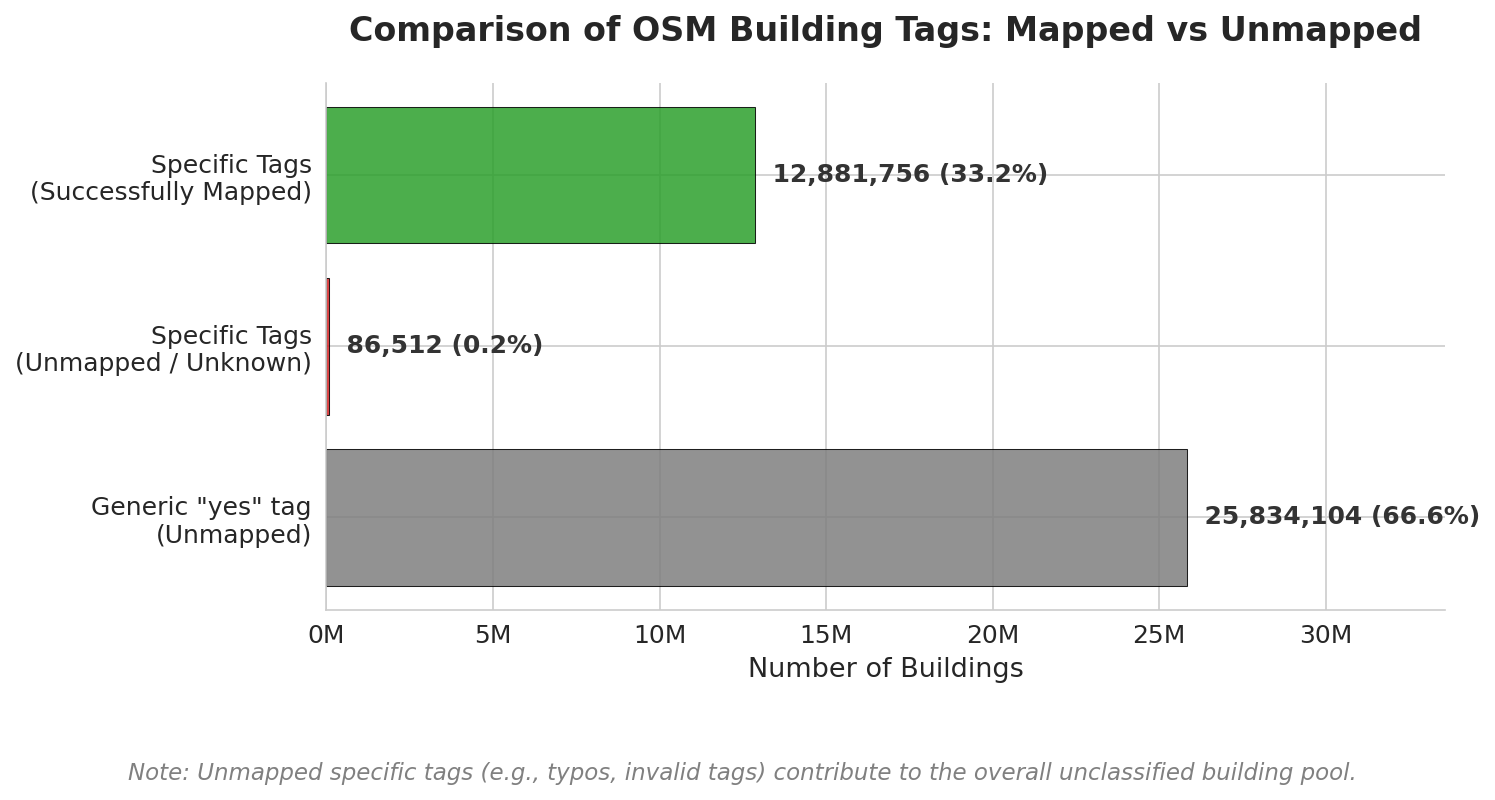

In [12]:

from matplotlib.ticker import FuncFormatter # <-- NEW: Import for axis formatting

# 1. Filter and Count
specific_buildings = gdf_bldg[(gdf_bldg['building'].notna()) & (gdf_bldg['building'] != 'yes')]

mapped_count = specific_buildings['building_l1'].notna().sum()
unmapped_count = specific_buildings['building_l1'].isna().sum()
yes_buildings = gdf_bldg[gdf_bldg['building'] == 'yes'].shape[0]

total_buildings = mapped_count + unmapped_count + yes_buildings

# 2. Prepare Data for Plotting
categories = [
    'Specific Tags\n(Successfully Mapped)', 
    'Specific Tags\n(Unmapped / Unknown)', 
    'Generic "yes" tag\n(Unmapped)'
]
counts = [mapped_count, unmapped_count, yes_buildings]
colors = ['#2ca02c', '#d62728', '#7f7f7f']

# Reverse lists for horizontal layout
categories.reverse()
counts.reverse()
colors.reverse()

# 3. Create the Plot
plt.figure(figsize=(10, 5), dpi=150)
sns.set_style("whitegrid")

bars = plt.barh(categories, counts, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)

# 4. Add Labels and Title
plt.title('Comparison of OSM Building Tags: Mapped vs Unmapped', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Buildings', fontsize=13)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# ==========================================
# 5. NEW: Format the X-axis to show Millions 
# ==========================================
# This removes the '1e7' and changes ticks to '5M', '10M', etc.
millions_formatter = FuncFormatter(lambda x, pos: f'{x / 1e6:g}M')
plt.gca().xaxis.set_major_formatter(millions_formatter)

# Remove the top and right frame borders
sns.despine()

# 6. Add Value and Percentage Labels
max_count = max(counts)
plt.xlim(0, max_count * 1.30) # Increased to 1.30 to give a bit more breathing room for long numbers

for bar, count in zip(bars, counts):
    if count == 0:
        continue
        
    percentage = (count / total_buildings) * 100
    
    # Keeping the exact comma format for the text labels (e.g., 24,500,000) 
    # as it's highly readable right next to the bar.
    label_text = f'  {count:,} ({percentage:.1f}%)'
    
    plt.text(
        bar.get_width(), 
        bar.get_y() + bar.get_height() / 2, 
        label_text, 
        ha='left', 
        va='center', 
        fontsize=12,
        fontweight='bold',
        color='#333333'
    )

# 7. Add Footnote
footnote_text = "Note: Unmapped specific tags (e.g., typos, invalid tags) contribute to the overall unclassified building pool."
plt.figtext(0.5, -0.05, footnote_text, ha='center', fontsize=11, color='gray', style='italic')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

/tmp/ipykernel_349994/2036319866.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


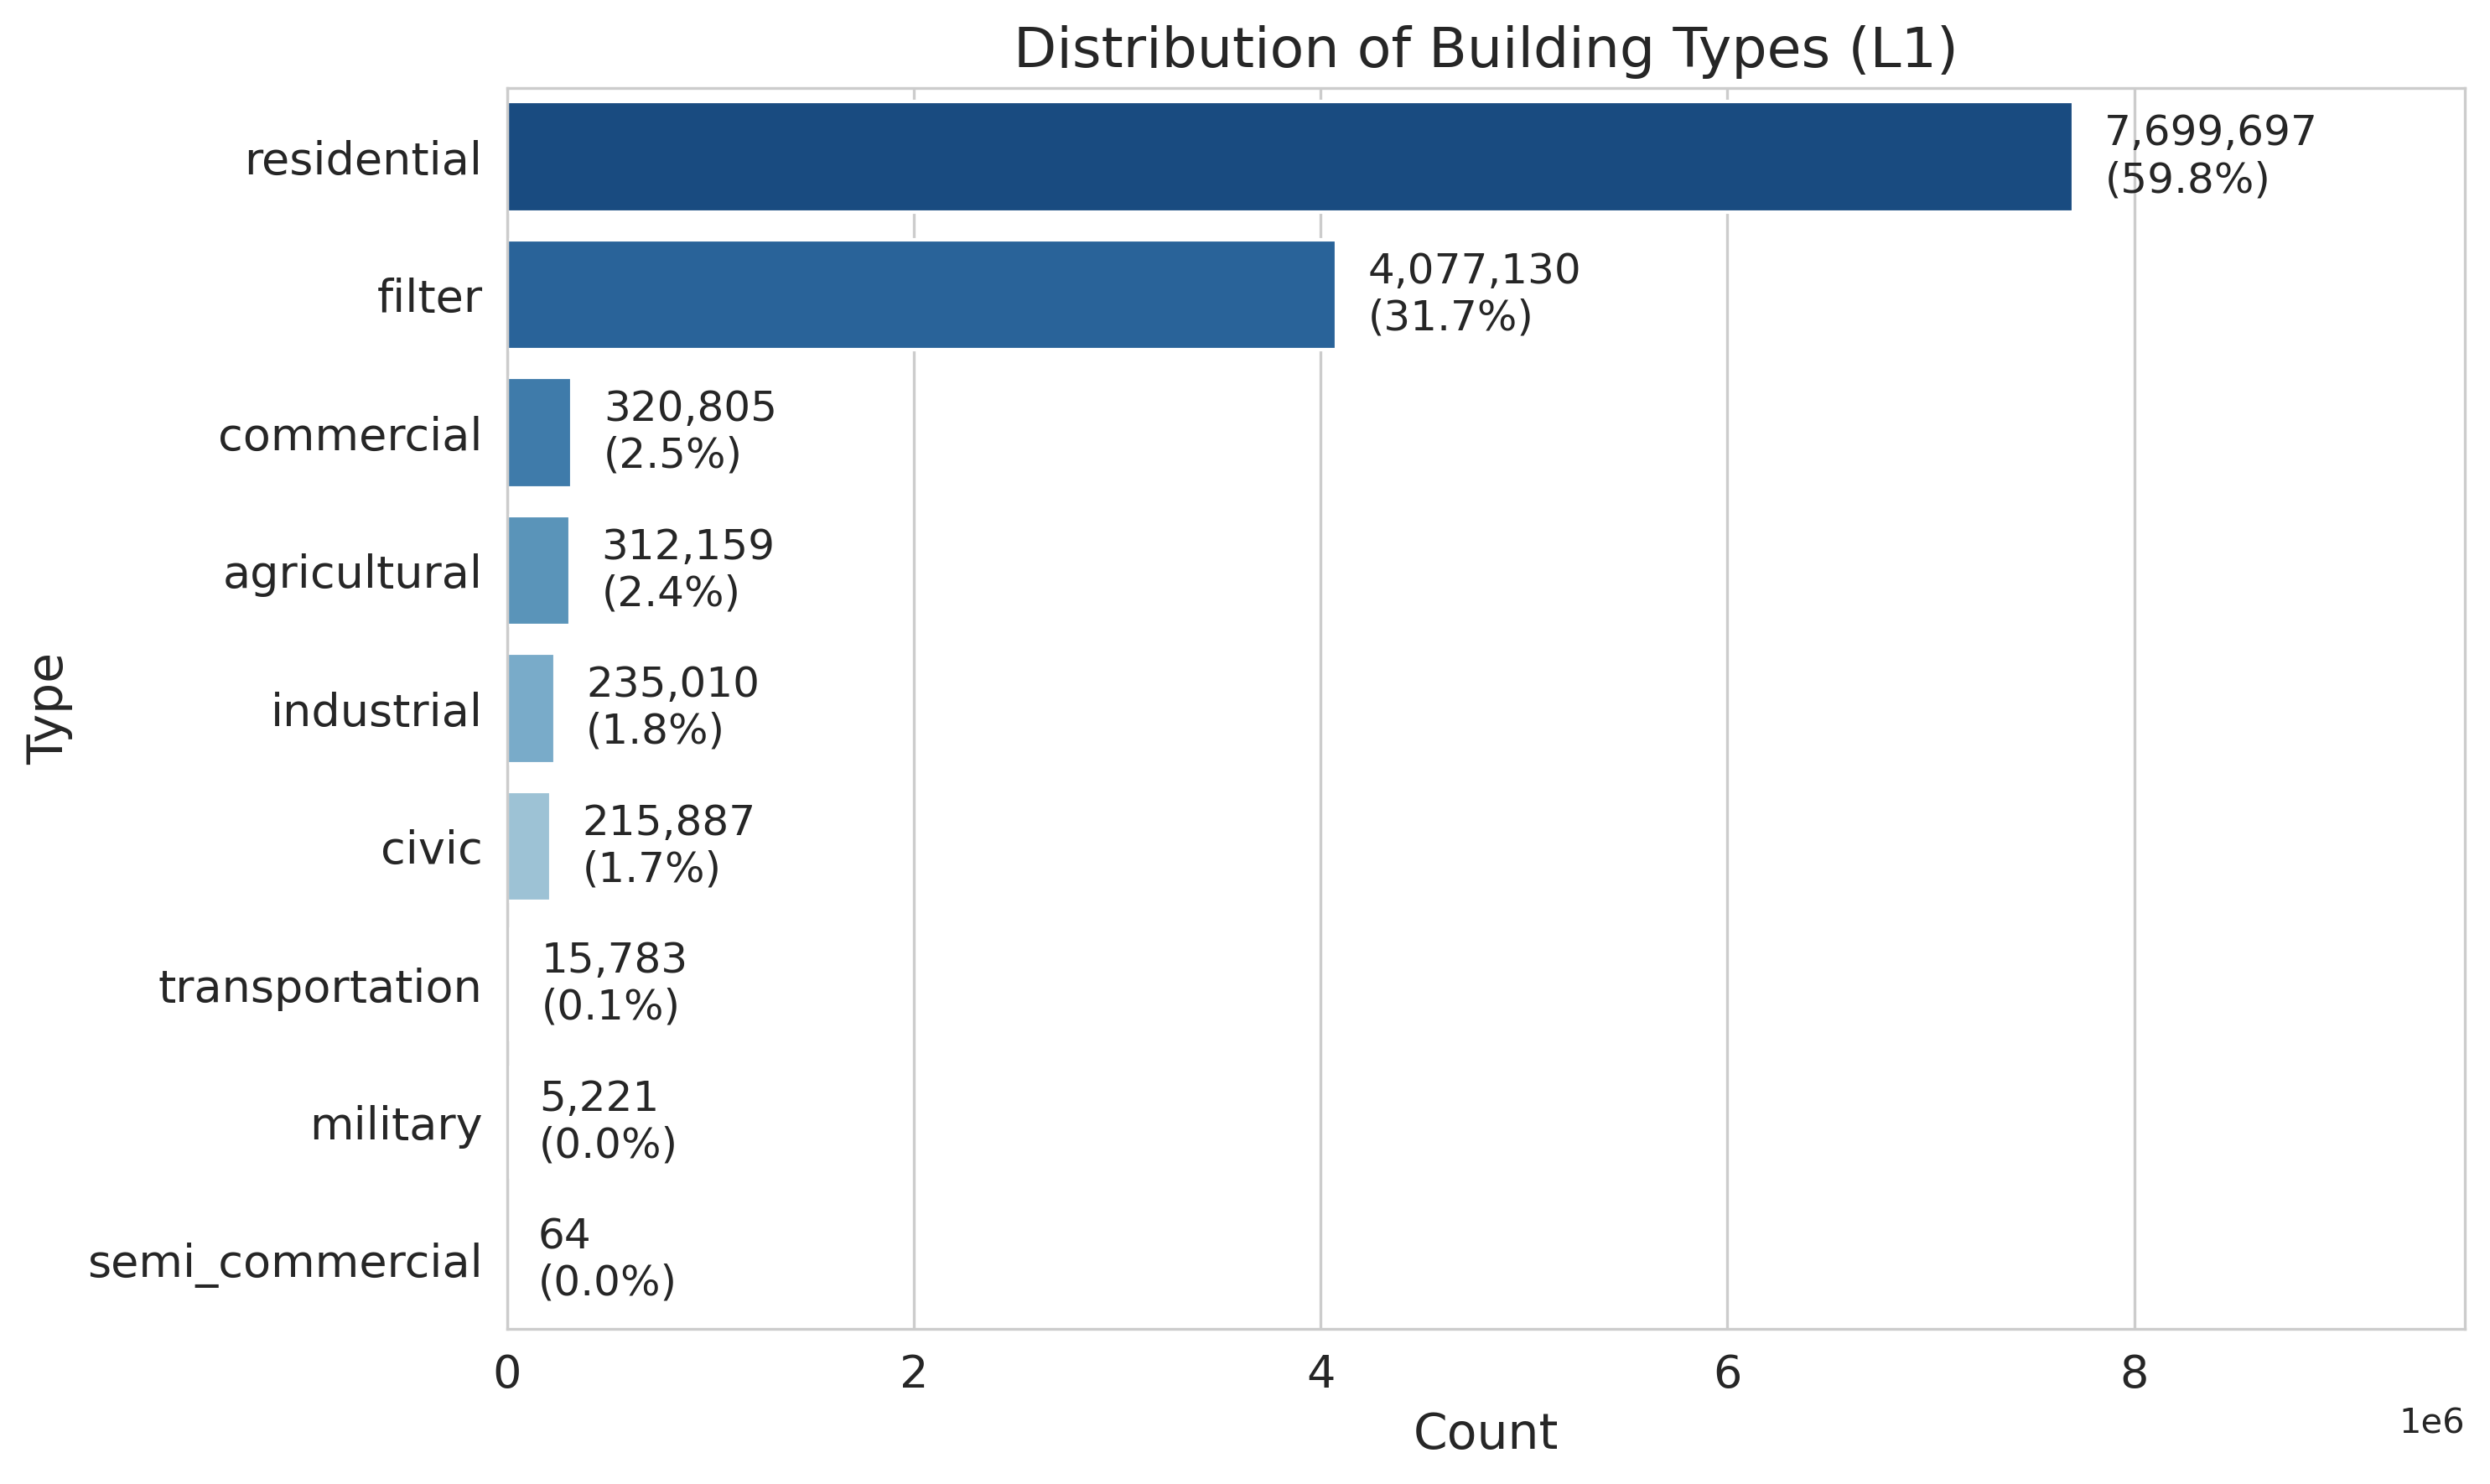

In [13]:
plot_l1_distribution(gdf_bldg, col='building_l1')

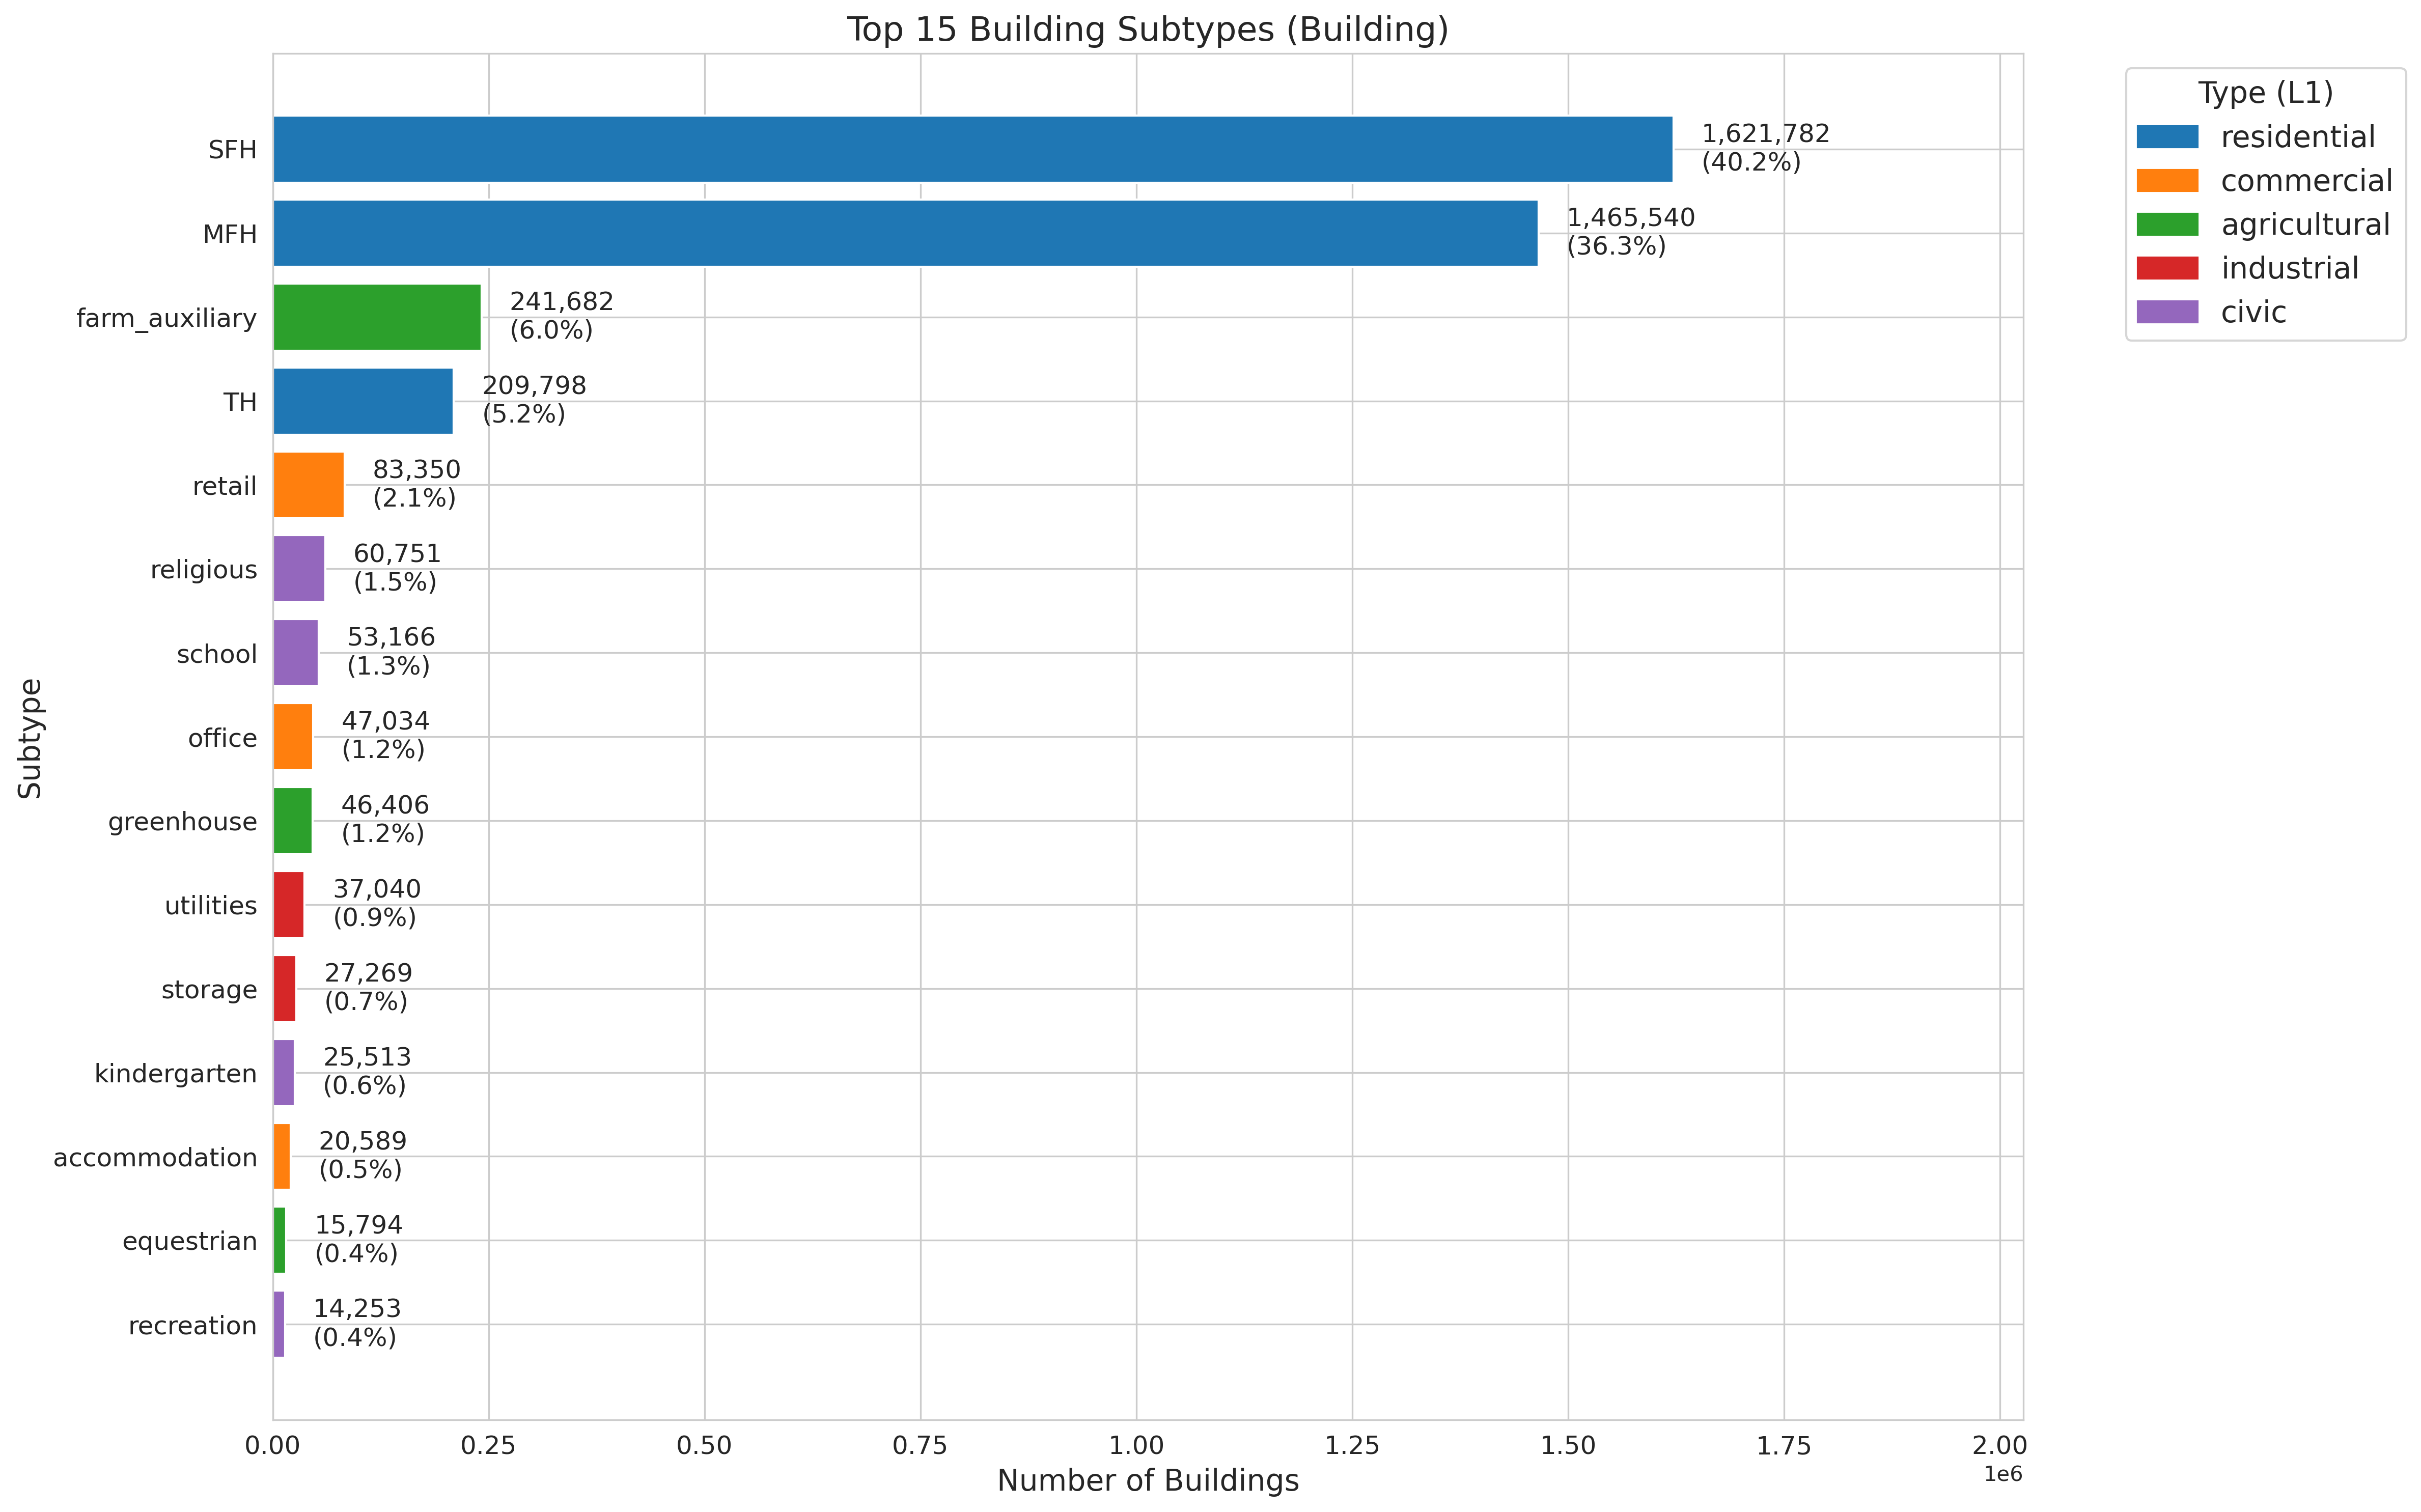

In [14]:
plot_top_subtypes_with_l1_colors(df=gdf_bldg, l1_col='building_l1', l2_col='building_l2', 
    top_n=15, title='Top 15 Building Subtypes (Building)')

In [15]:
gdf_bldg = apply_tag_mapping(gdf_bldg, 'building:use', apply_building_use_map, 'buse')

building:use tag  → mapped 183,862 / 200,114 (91.9%)
buse_l1
residential        166102
commercial           5198
semi_commercial      3564
industrial           3049
civic                2791
filter               1697
agricultural         1342
transportation        119
Name: count, dtype: int64


/tmp/ipykernel_349994/2036319866.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


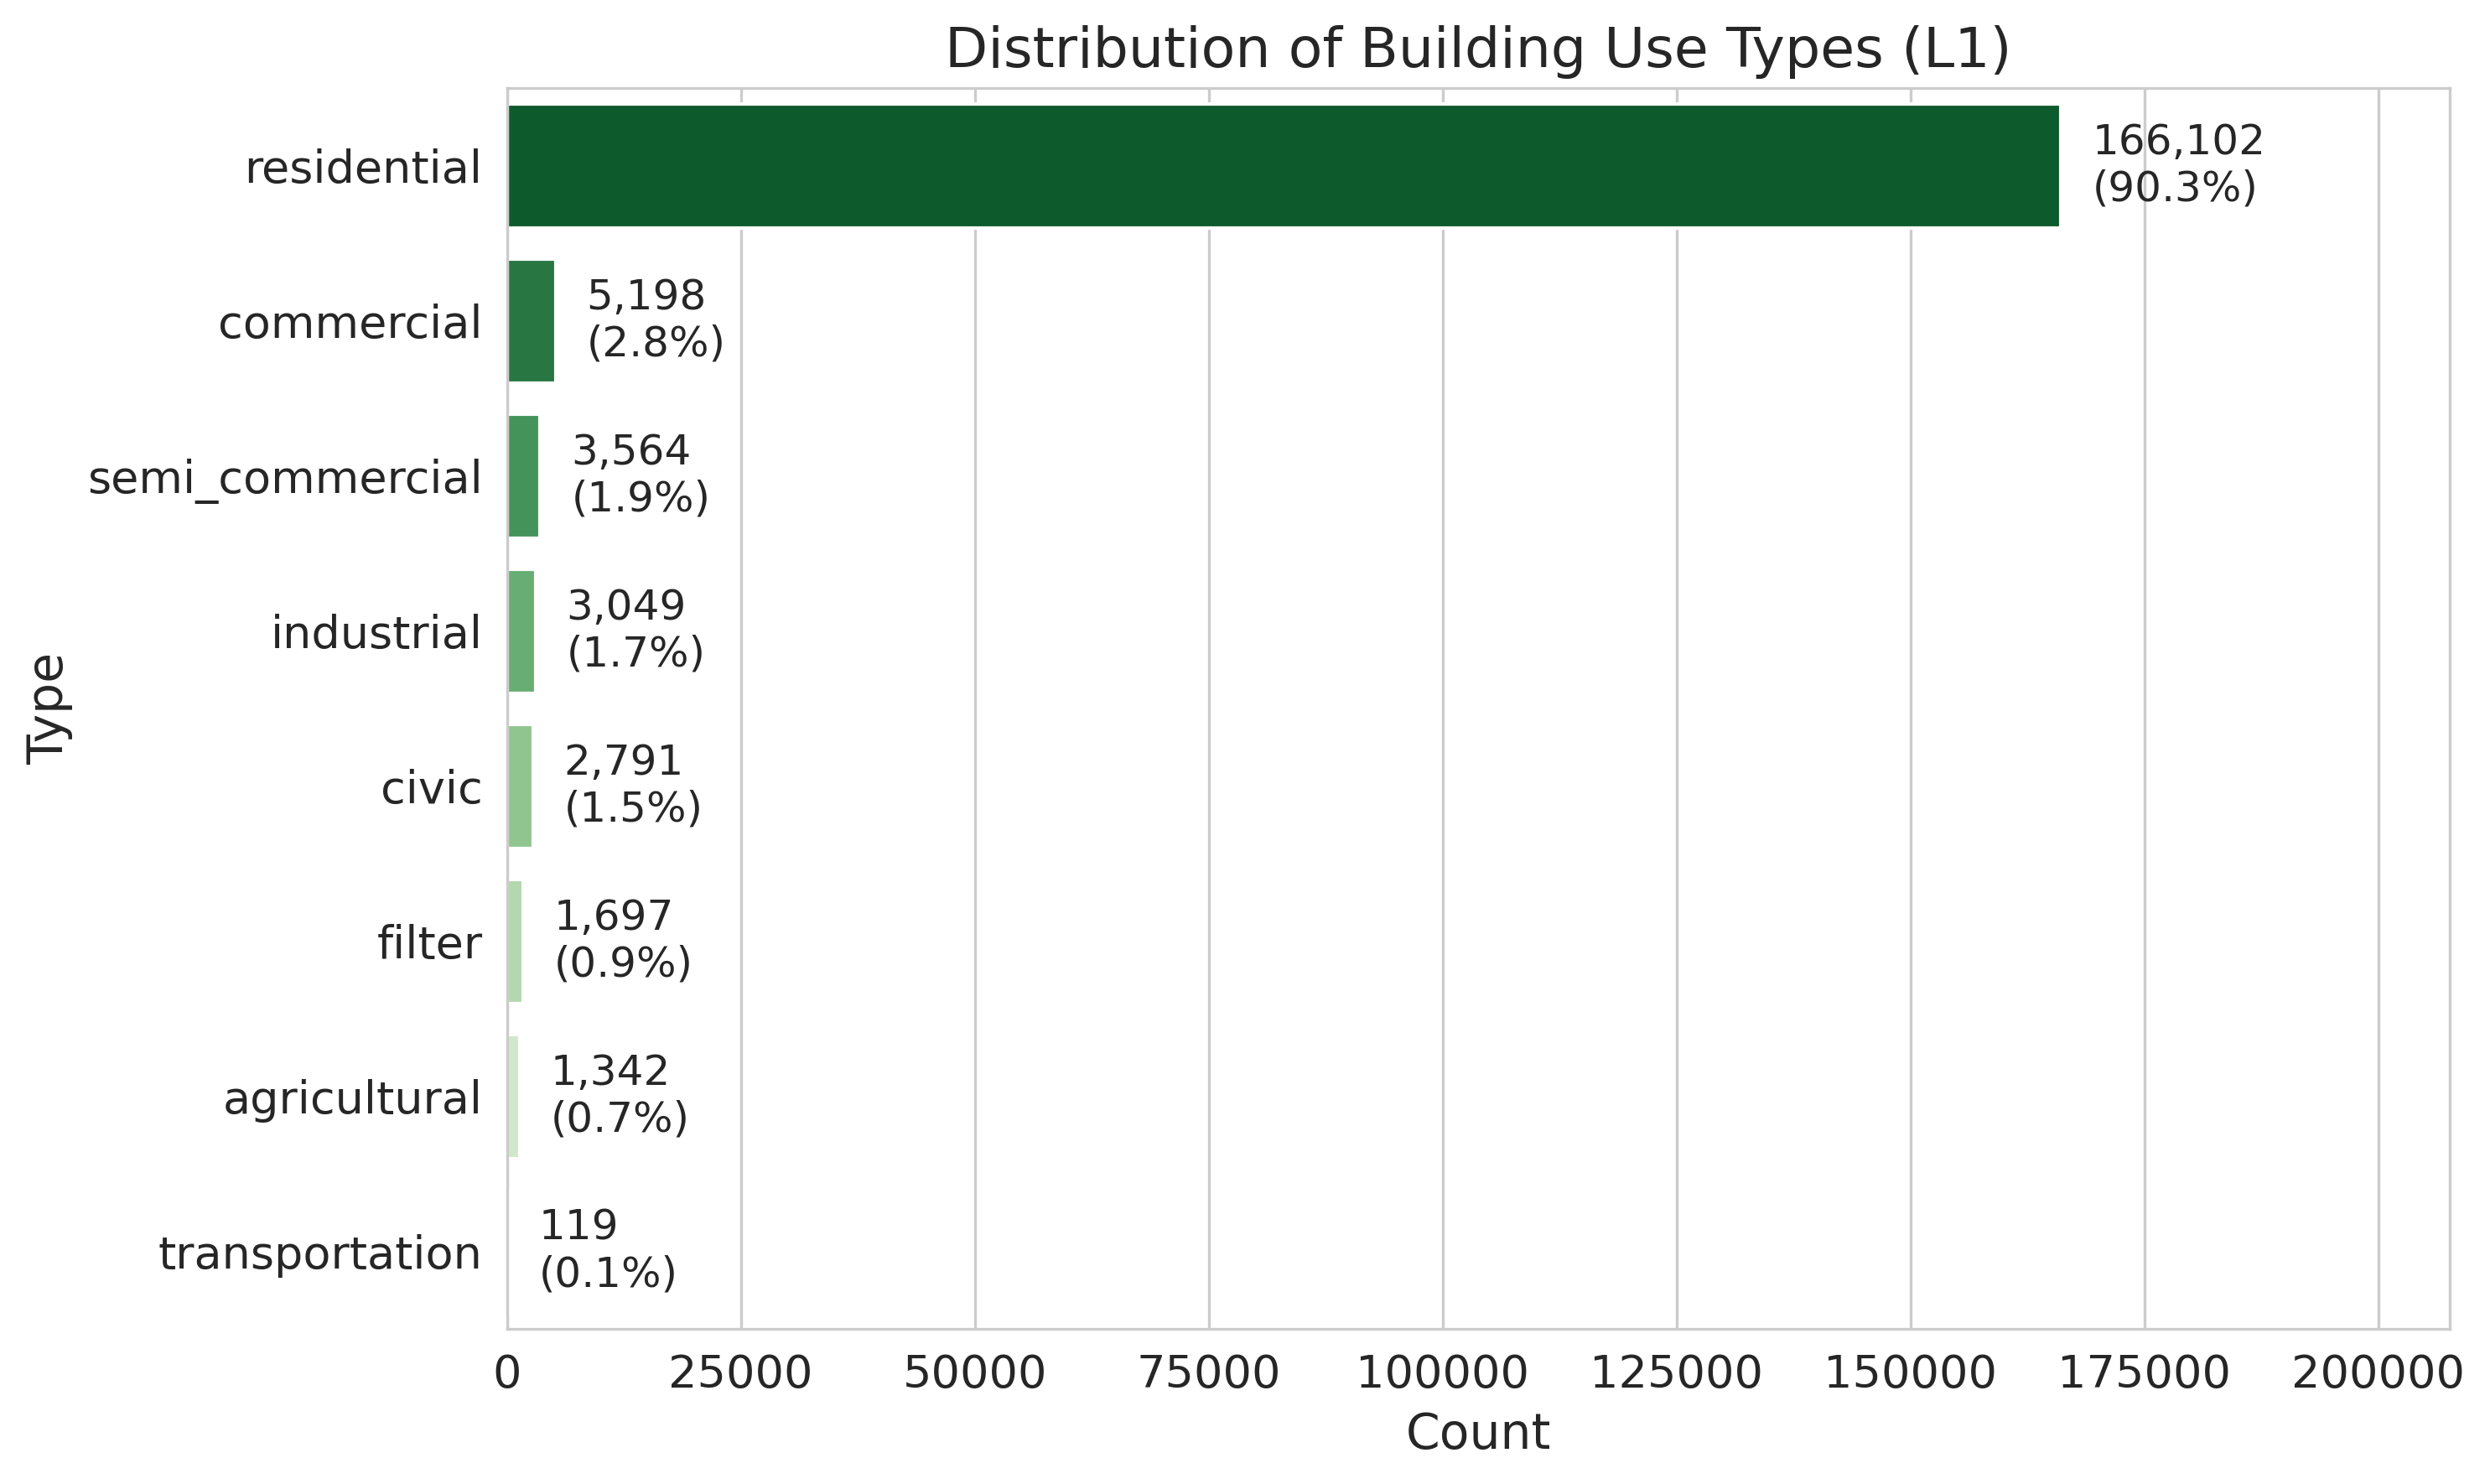

In [16]:
plot_l1_distribution(df=gdf_bldg, col='buse_l1', 
title='Distribution of Building Use Types (L1)',palette='Greens_r')

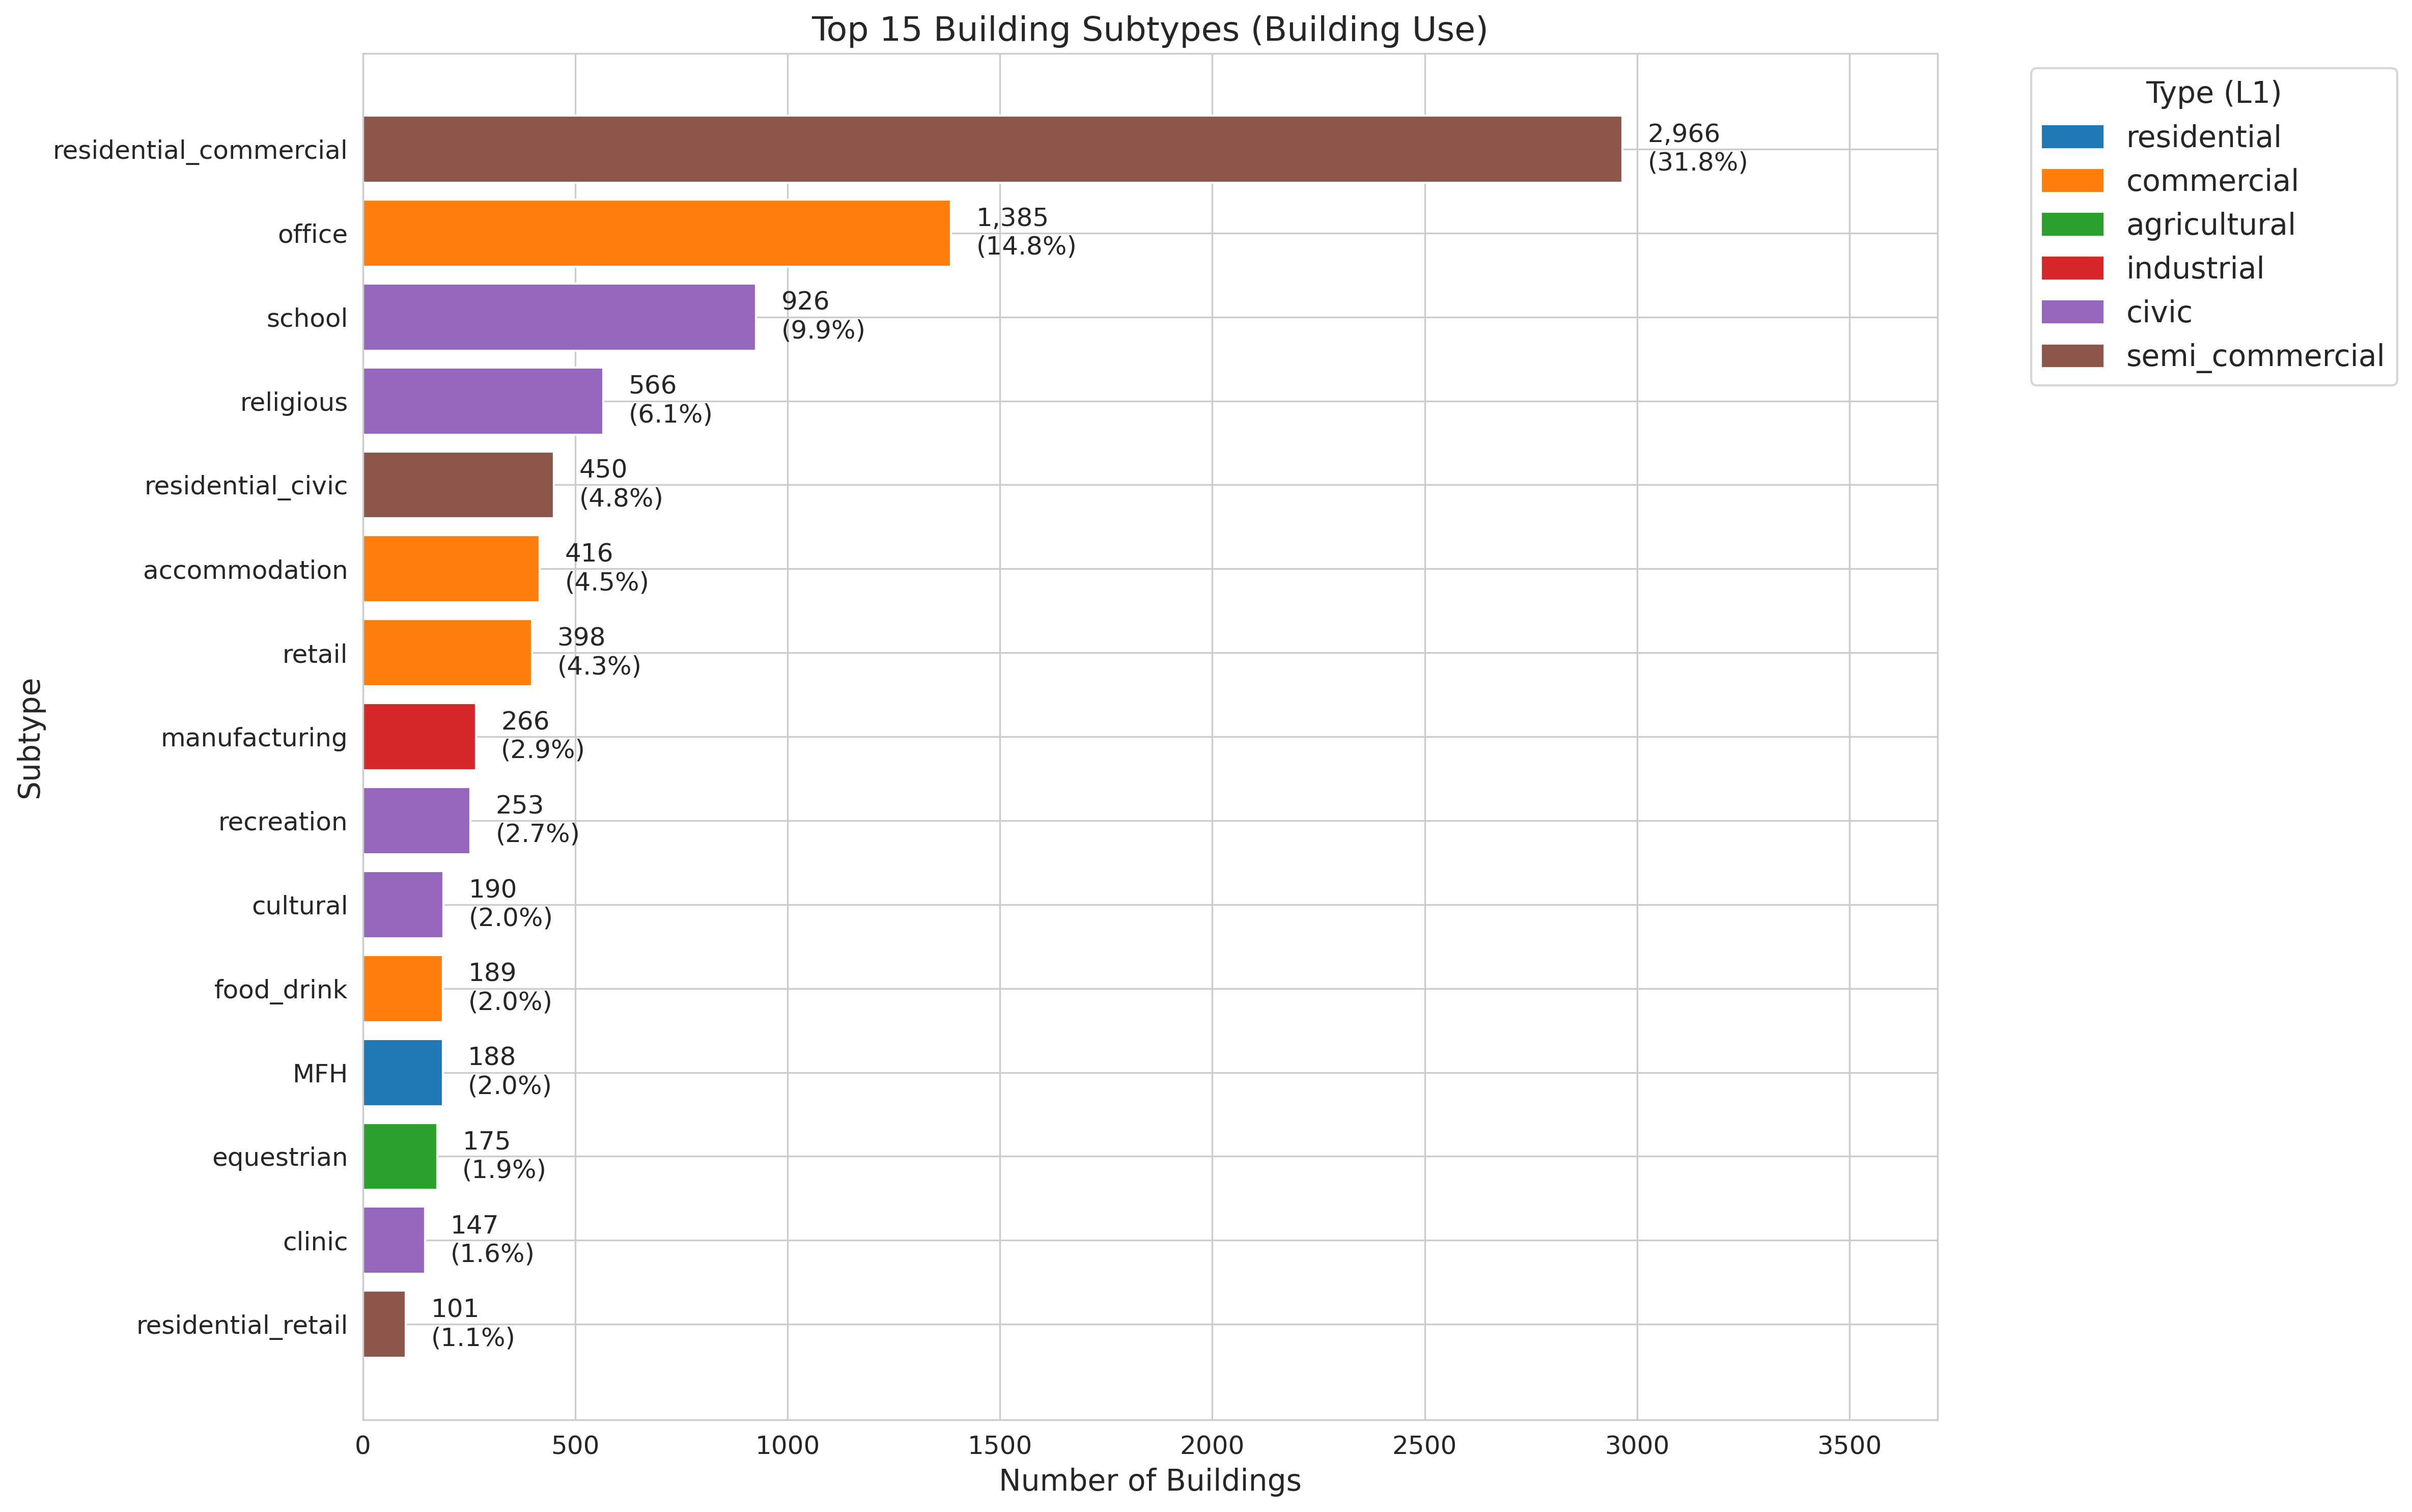

In [17]:
plot_top_subtypes_with_l1_colors(df=gdf_bldg, l1_col='buse_l1', l2_col='buse_l2', 
    top_n=15, title='Top 15 Building Subtypes (Building Use)')

In [18]:
gdf_bldg = apply_tag_mapping(gdf_bldg, 'amenity', apply_amenity_map, 'amenity')

amenity tag  → mapped 239,999 / 248,725 (96.5%)
amenity_l1
civic             143493
commercial         50515
filter             45170
agricultural         611
industrial           124
transportation        60
residential           26
Name: count, dtype: int64


/tmp/ipykernel_349994/2036319866.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


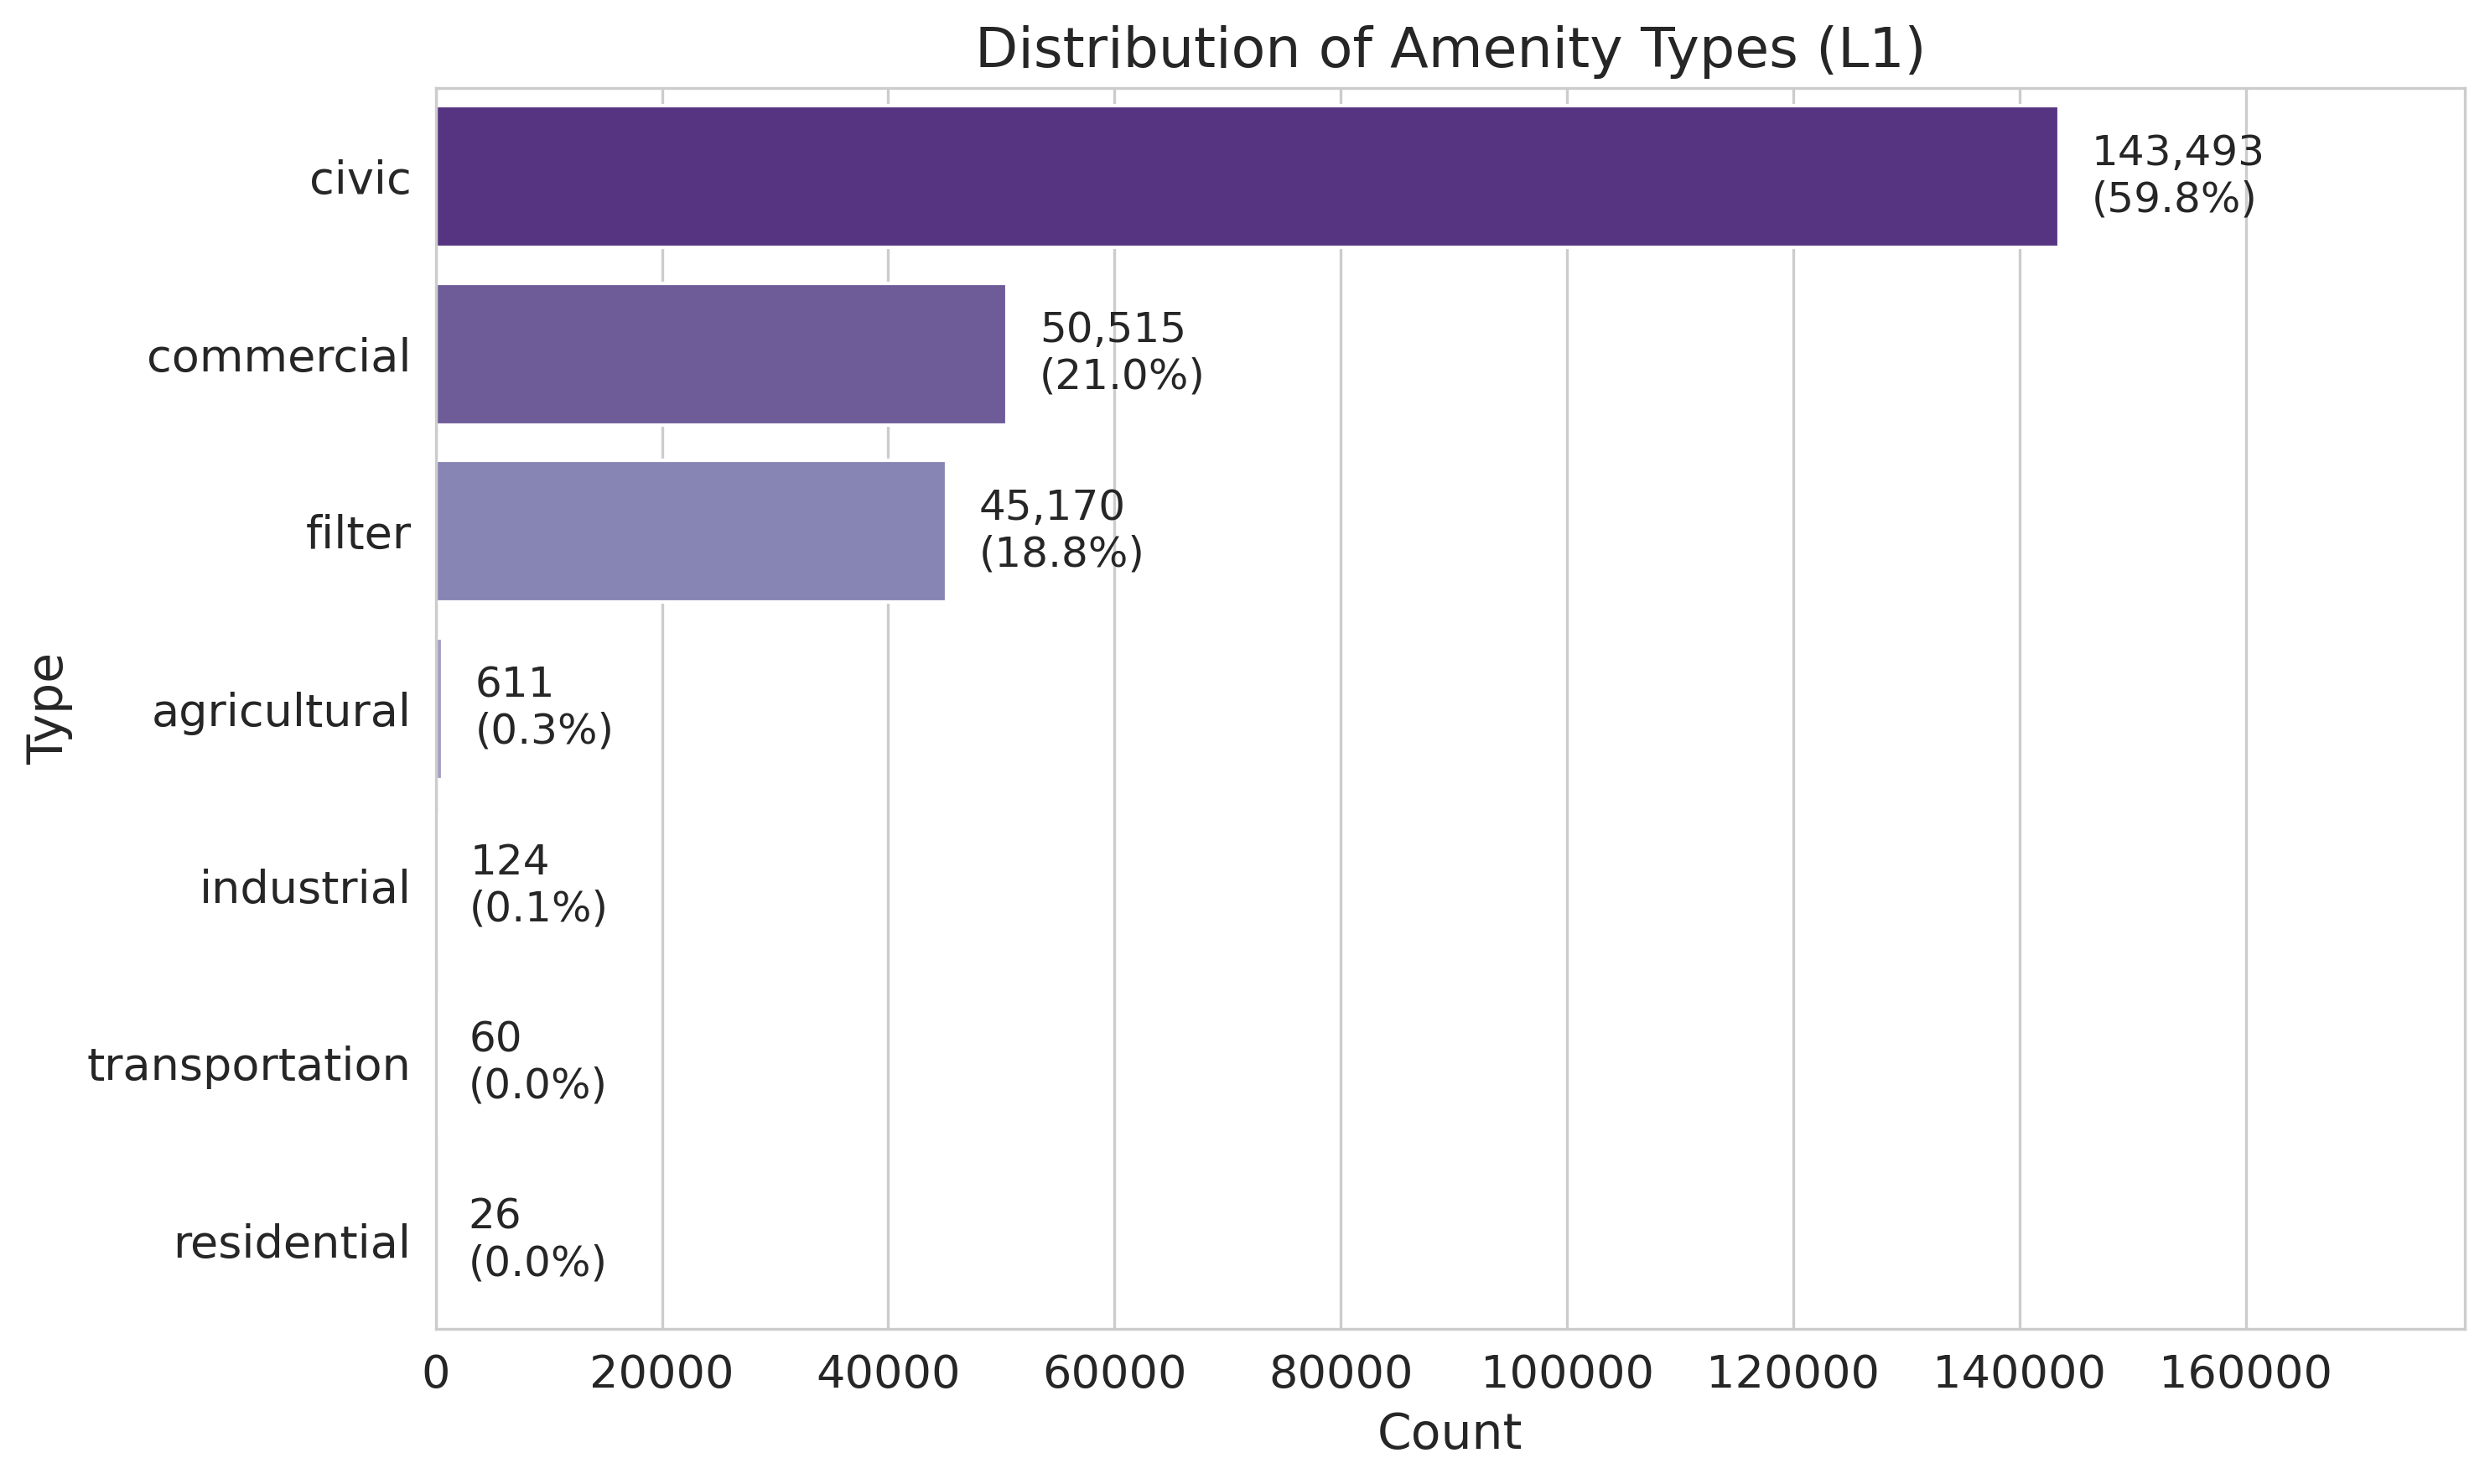

In [19]:
# For Amenity L1
plot_l1_distribution(df=gdf_bldg, col='amenity_l1', 
title='Distribution of Amenity Types (L1)',palette='Purples_r')

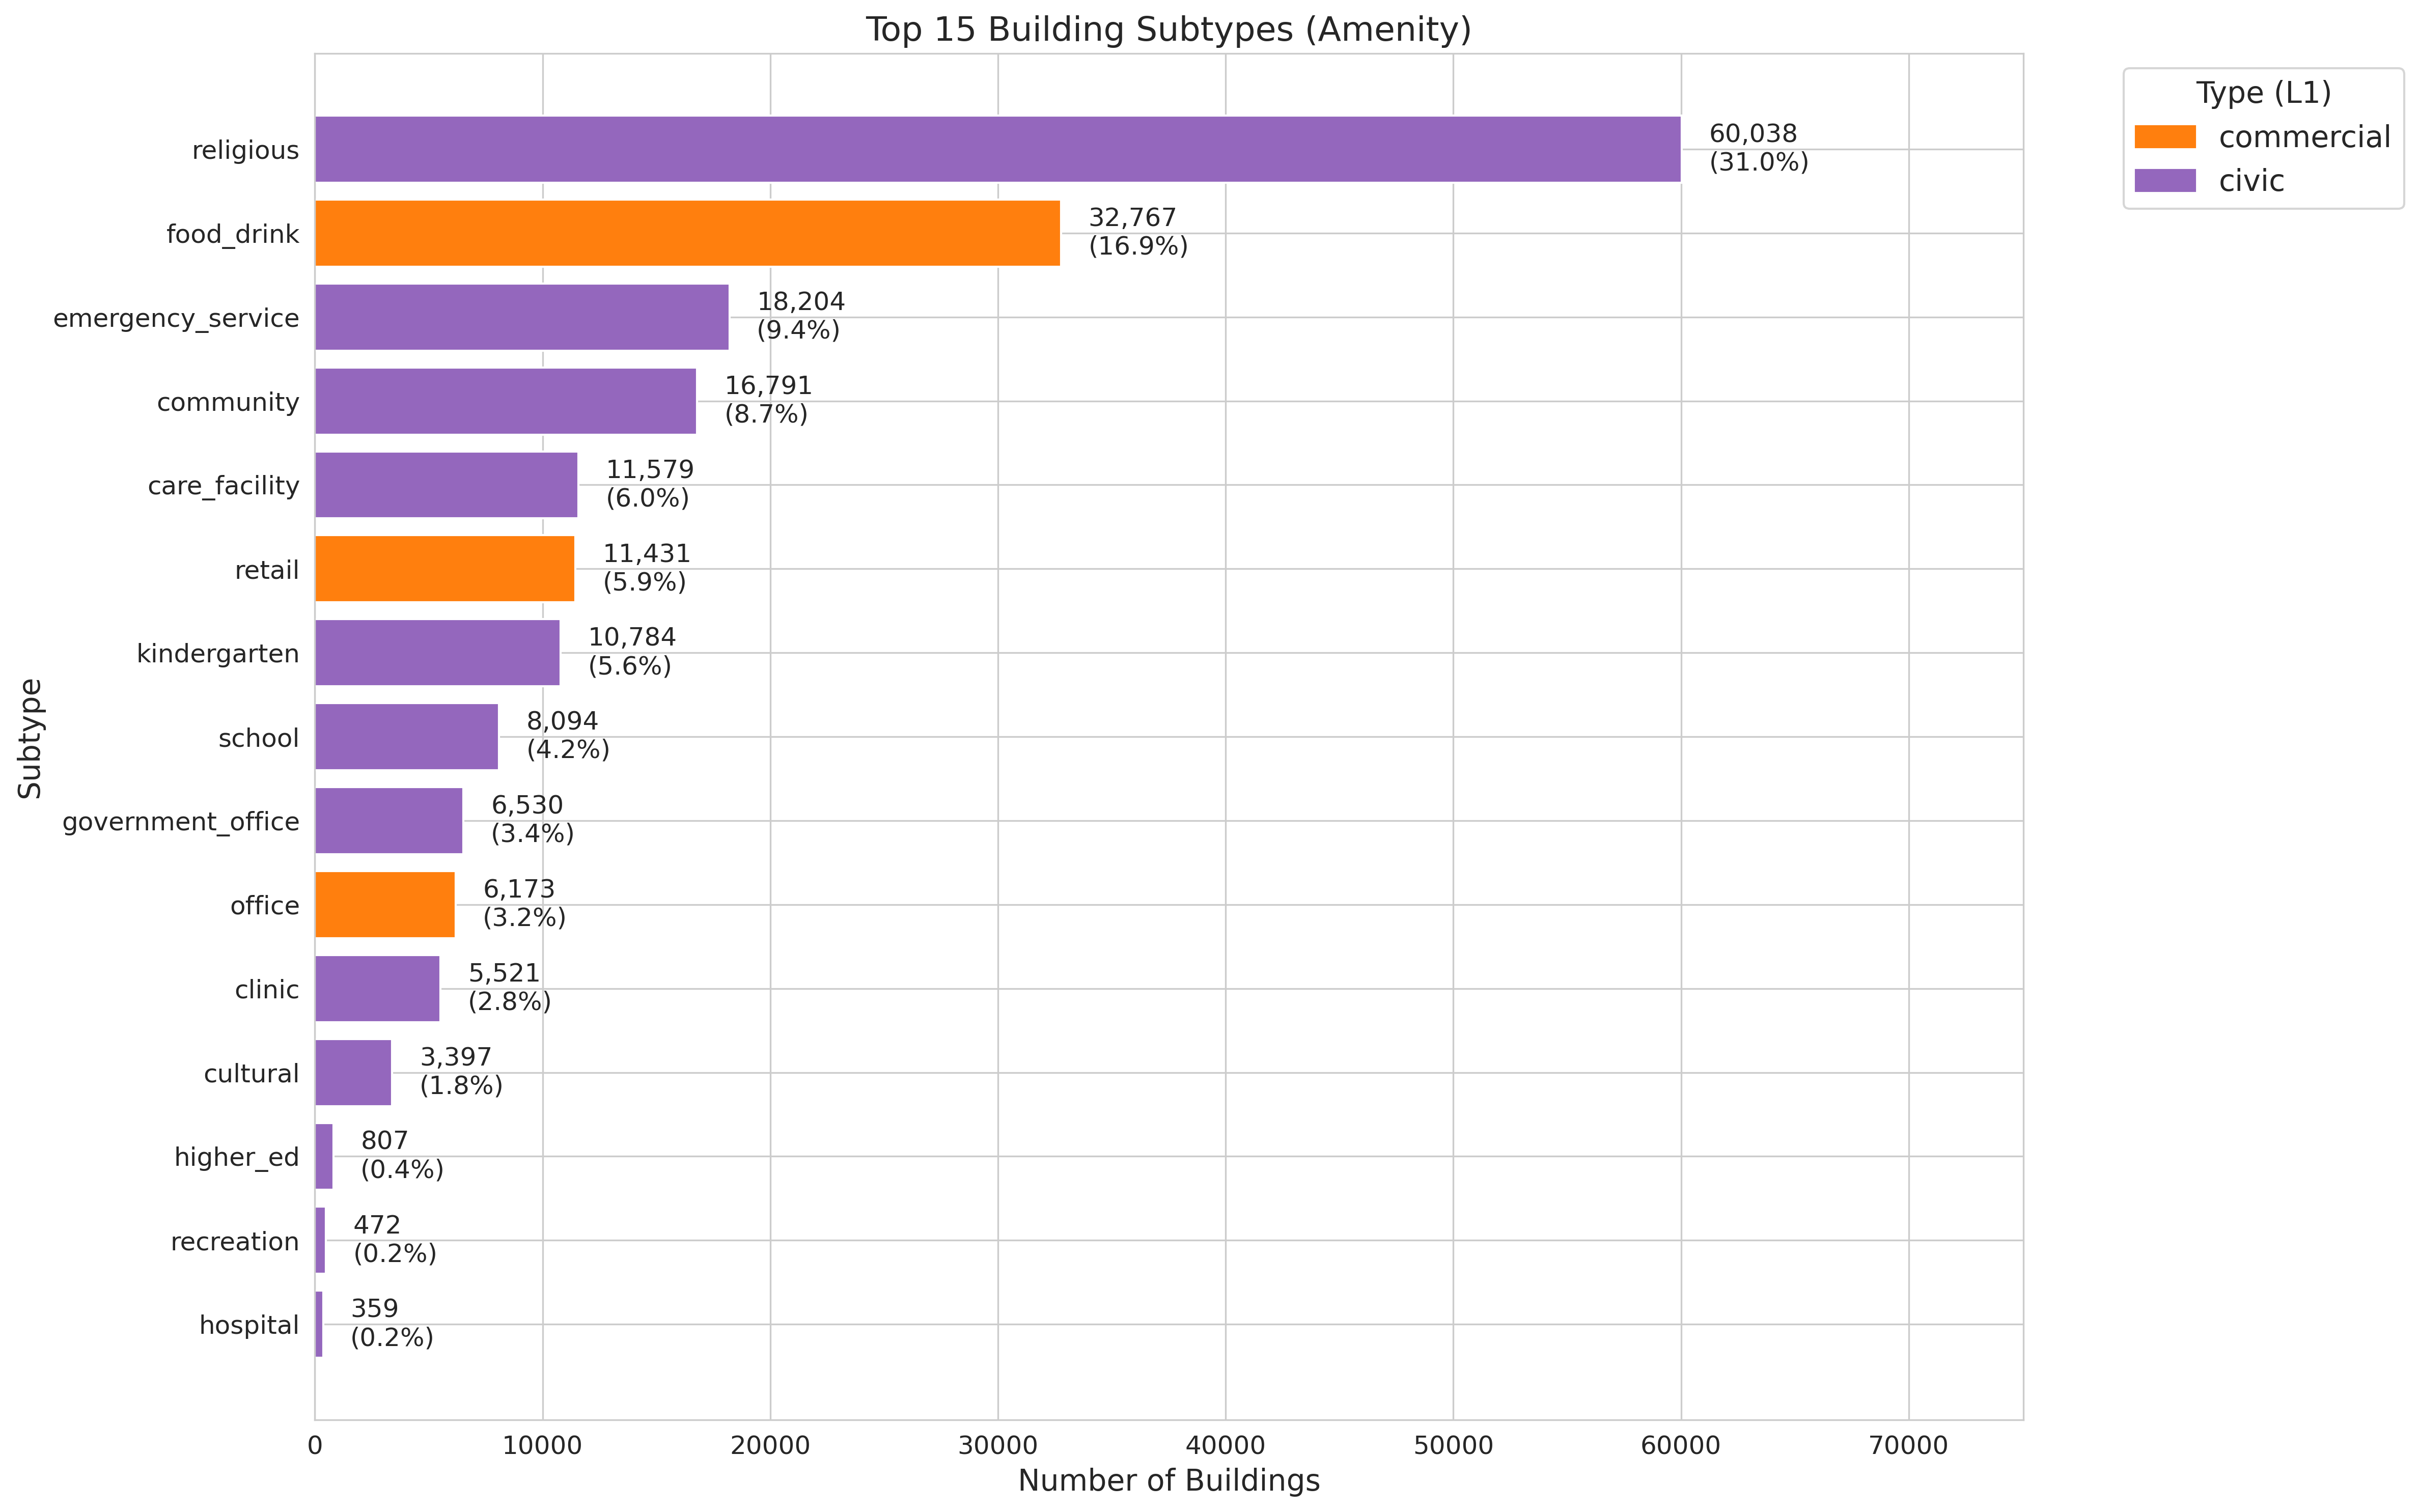

In [20]:
plot_top_subtypes_with_l1_colors(df=gdf_bldg, l1_col='amenity_l1', l2_col='amenity_l2', 
    top_n=15, title='Top 15 Building Subtypes (Amenity)')

In [21]:
gdf_bldg = apply_tag_mapping(gdf_bldg, 'shop', apply_shop_map, 'shop')

shop tag  → mapped 82,061 / 82,169 (99.9%)
shop_l1
commercial    82057
filter            3
civic             1
Name: count, dtype: int64


/tmp/ipykernel_349994/2036319866.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


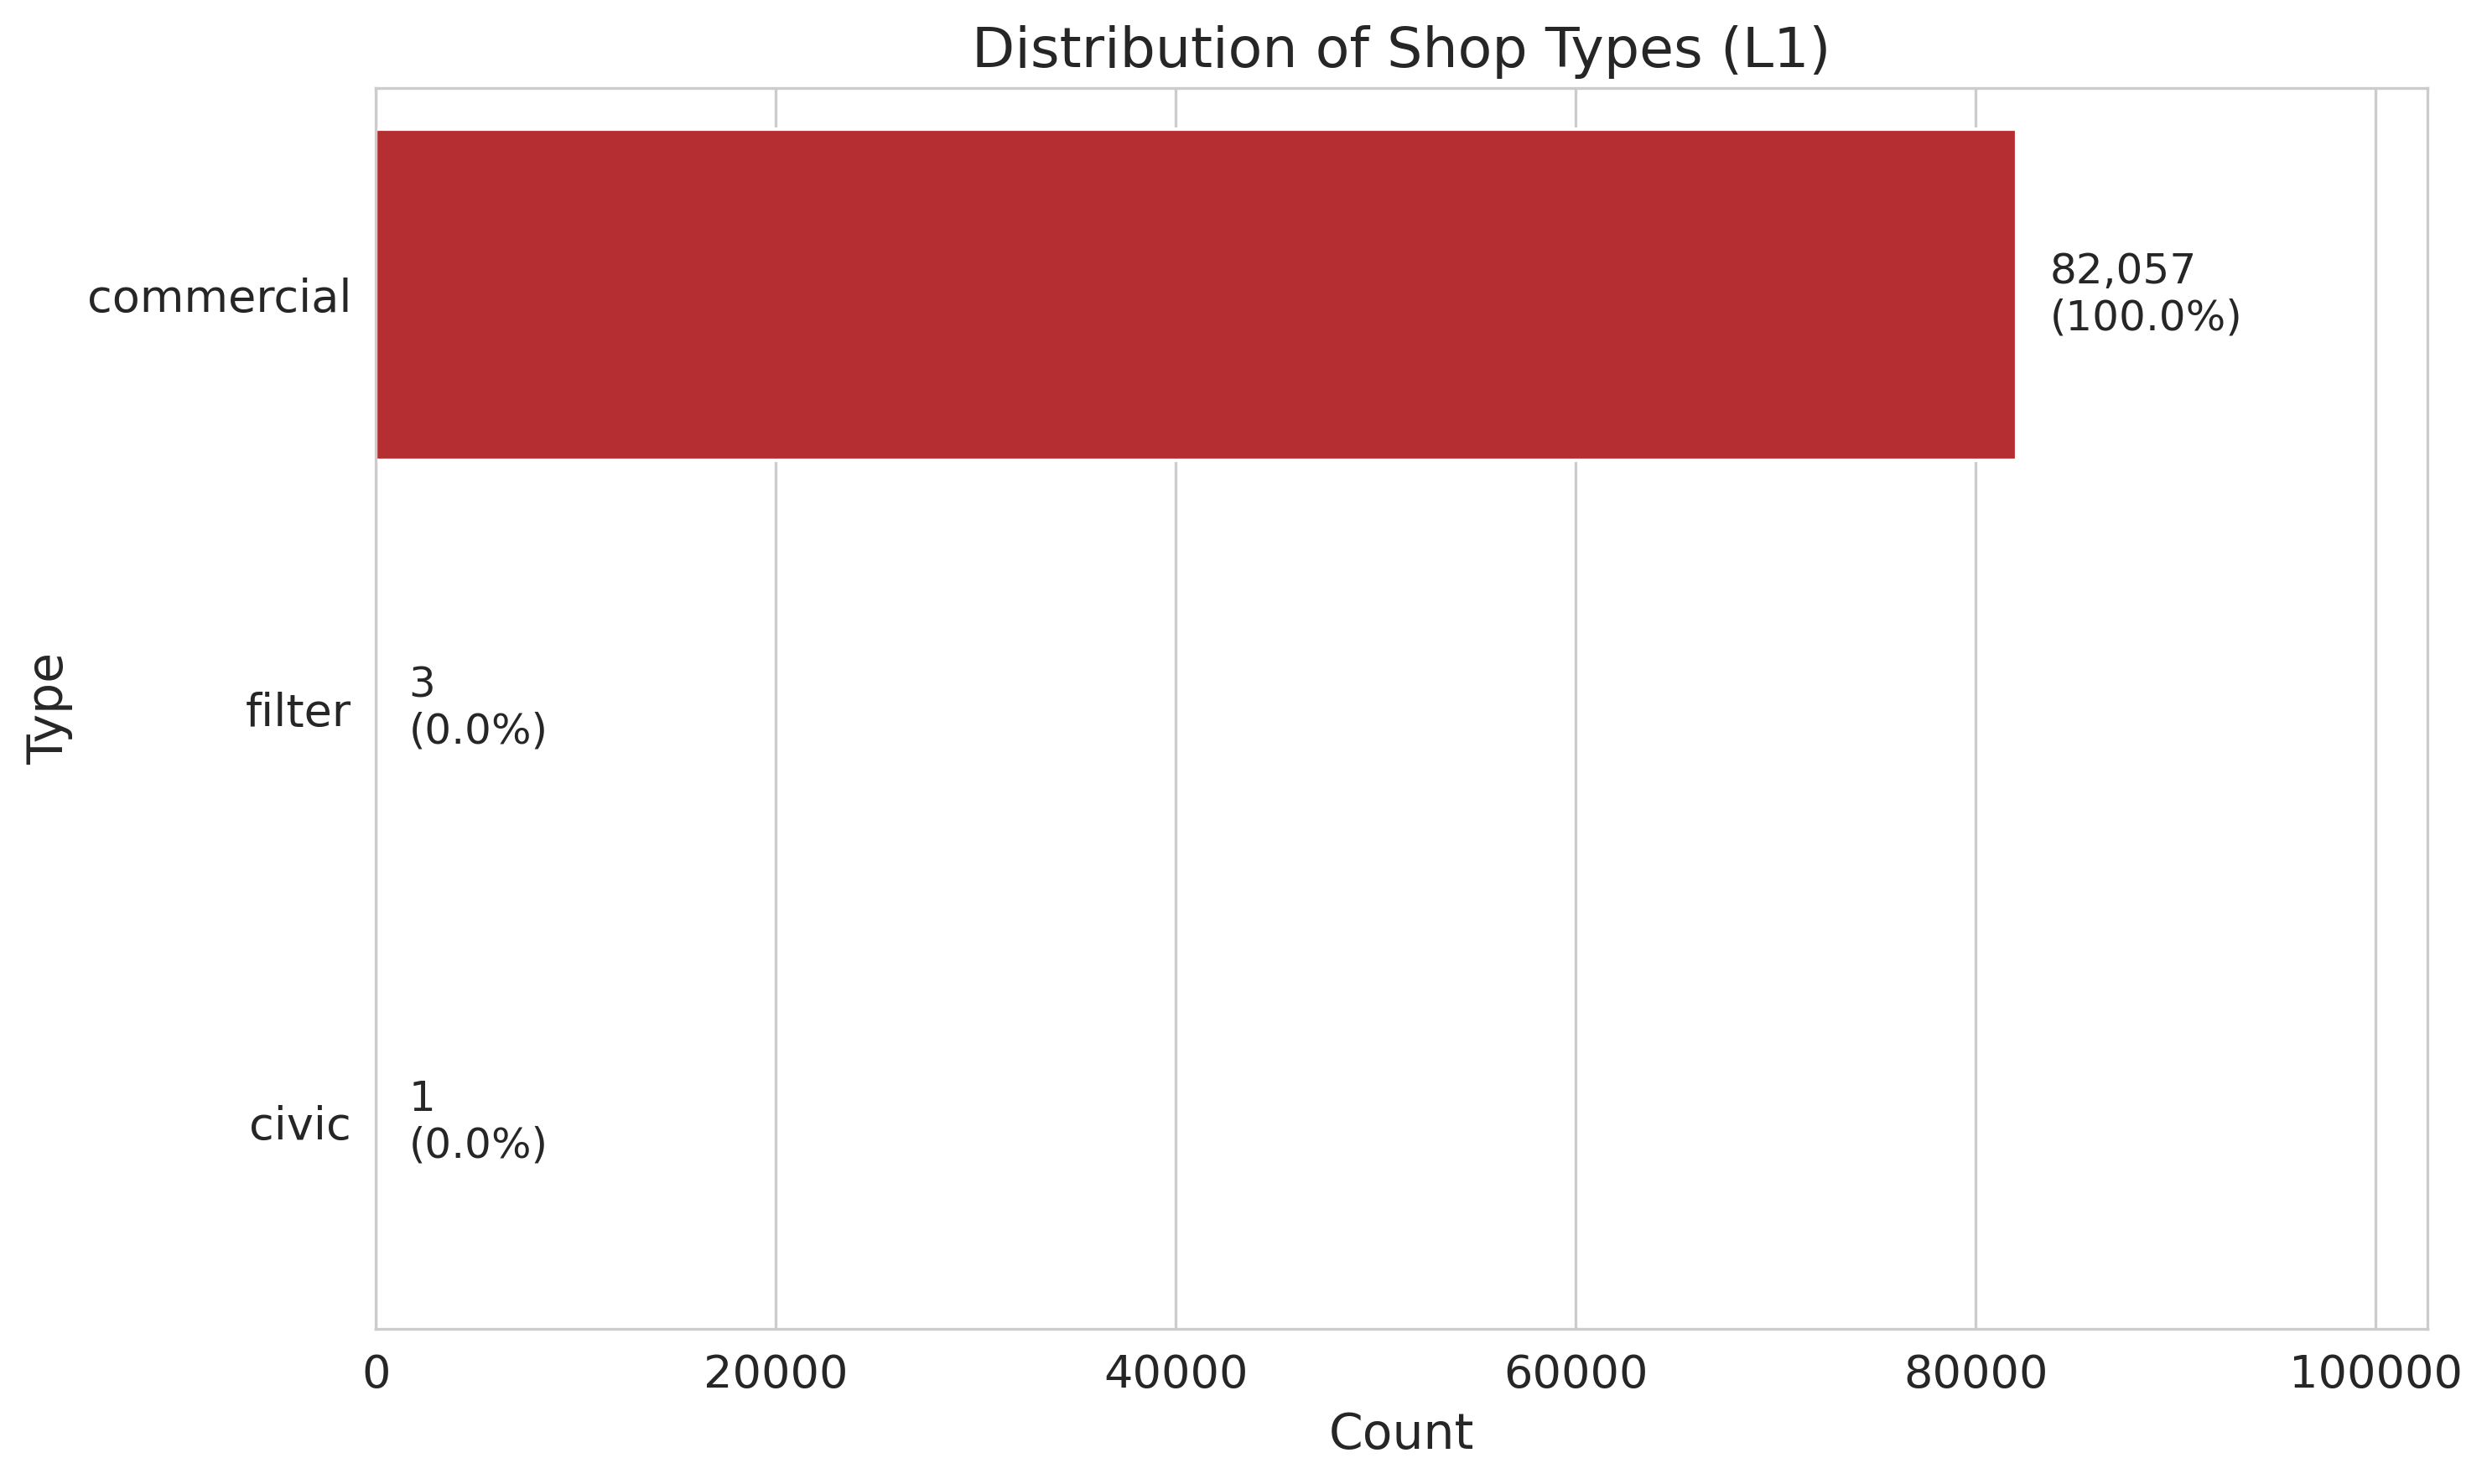

In [22]:
# For Shop L1
plot_l1_distribution(df=gdf_bldg, col='shop_l1', 
title='Distribution of Shop Types (L1)',palette='Reds_r')

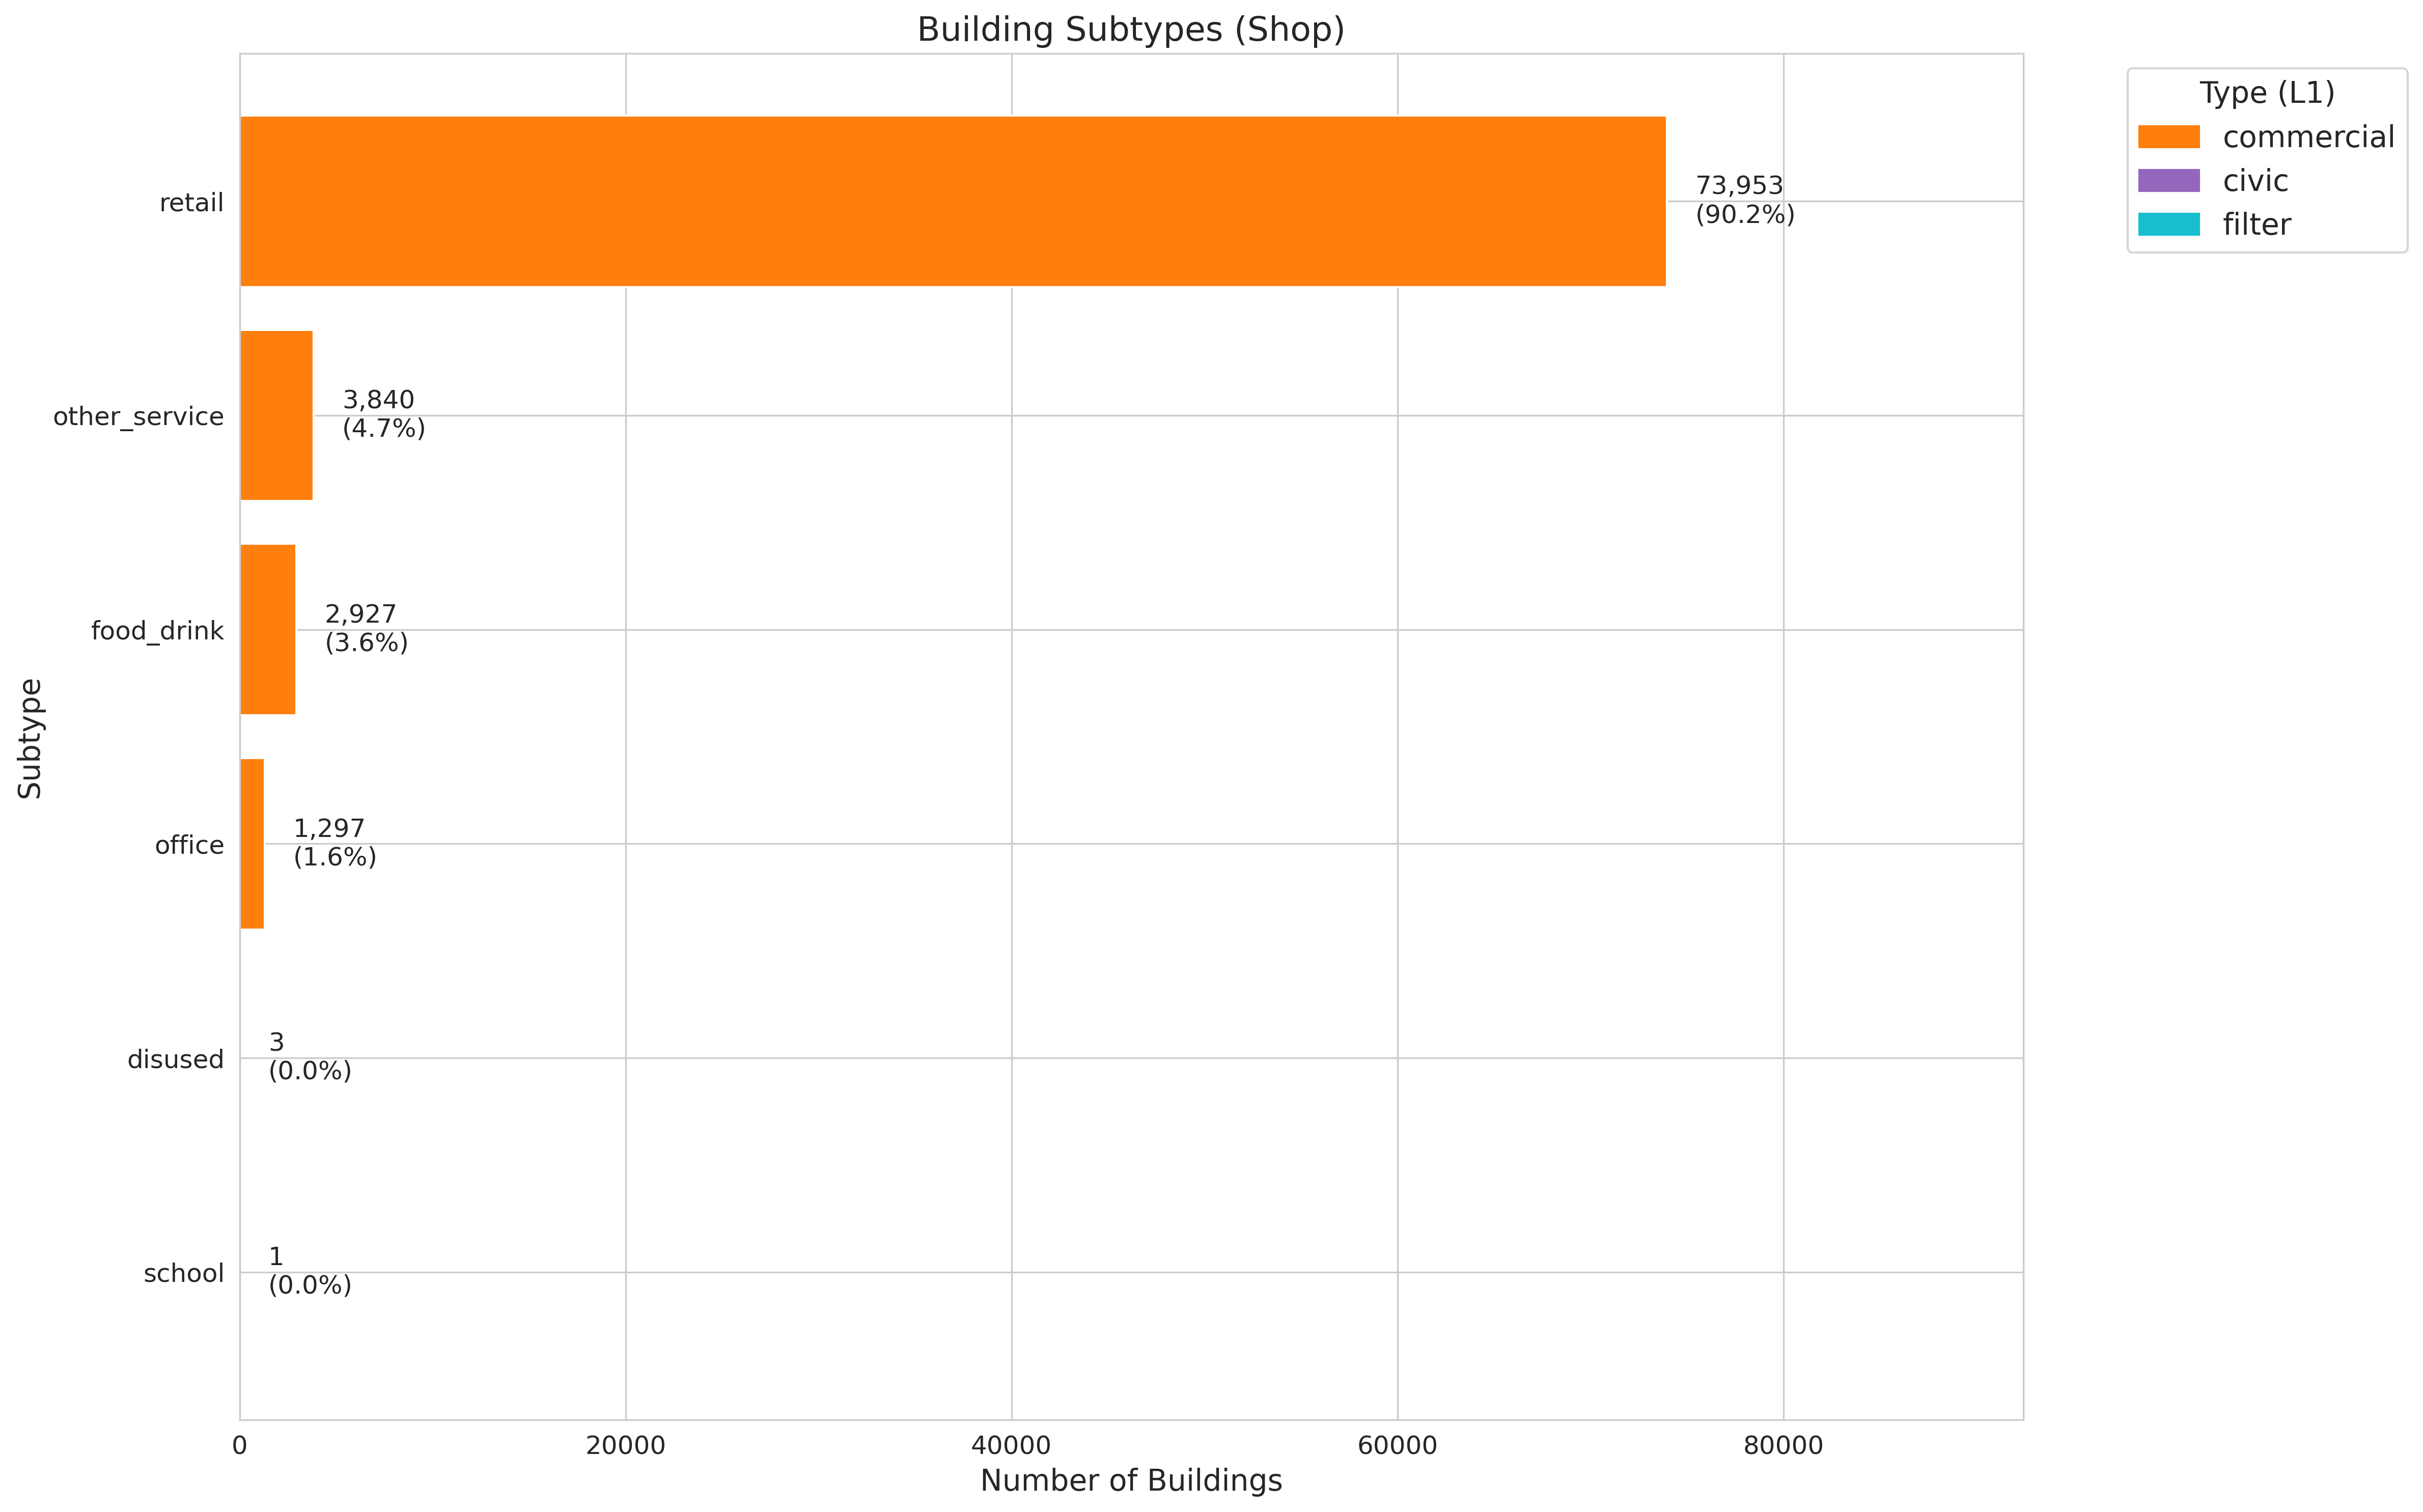

In [23]:
plot_top_subtypes_with_l1_colors(df=gdf_bldg, l1_col='shop_l1', l2_col='shop_l2', 
    top_n=15, title='Building Subtypes (Shop)')

/tmp/ipykernel_349994/2036319866.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


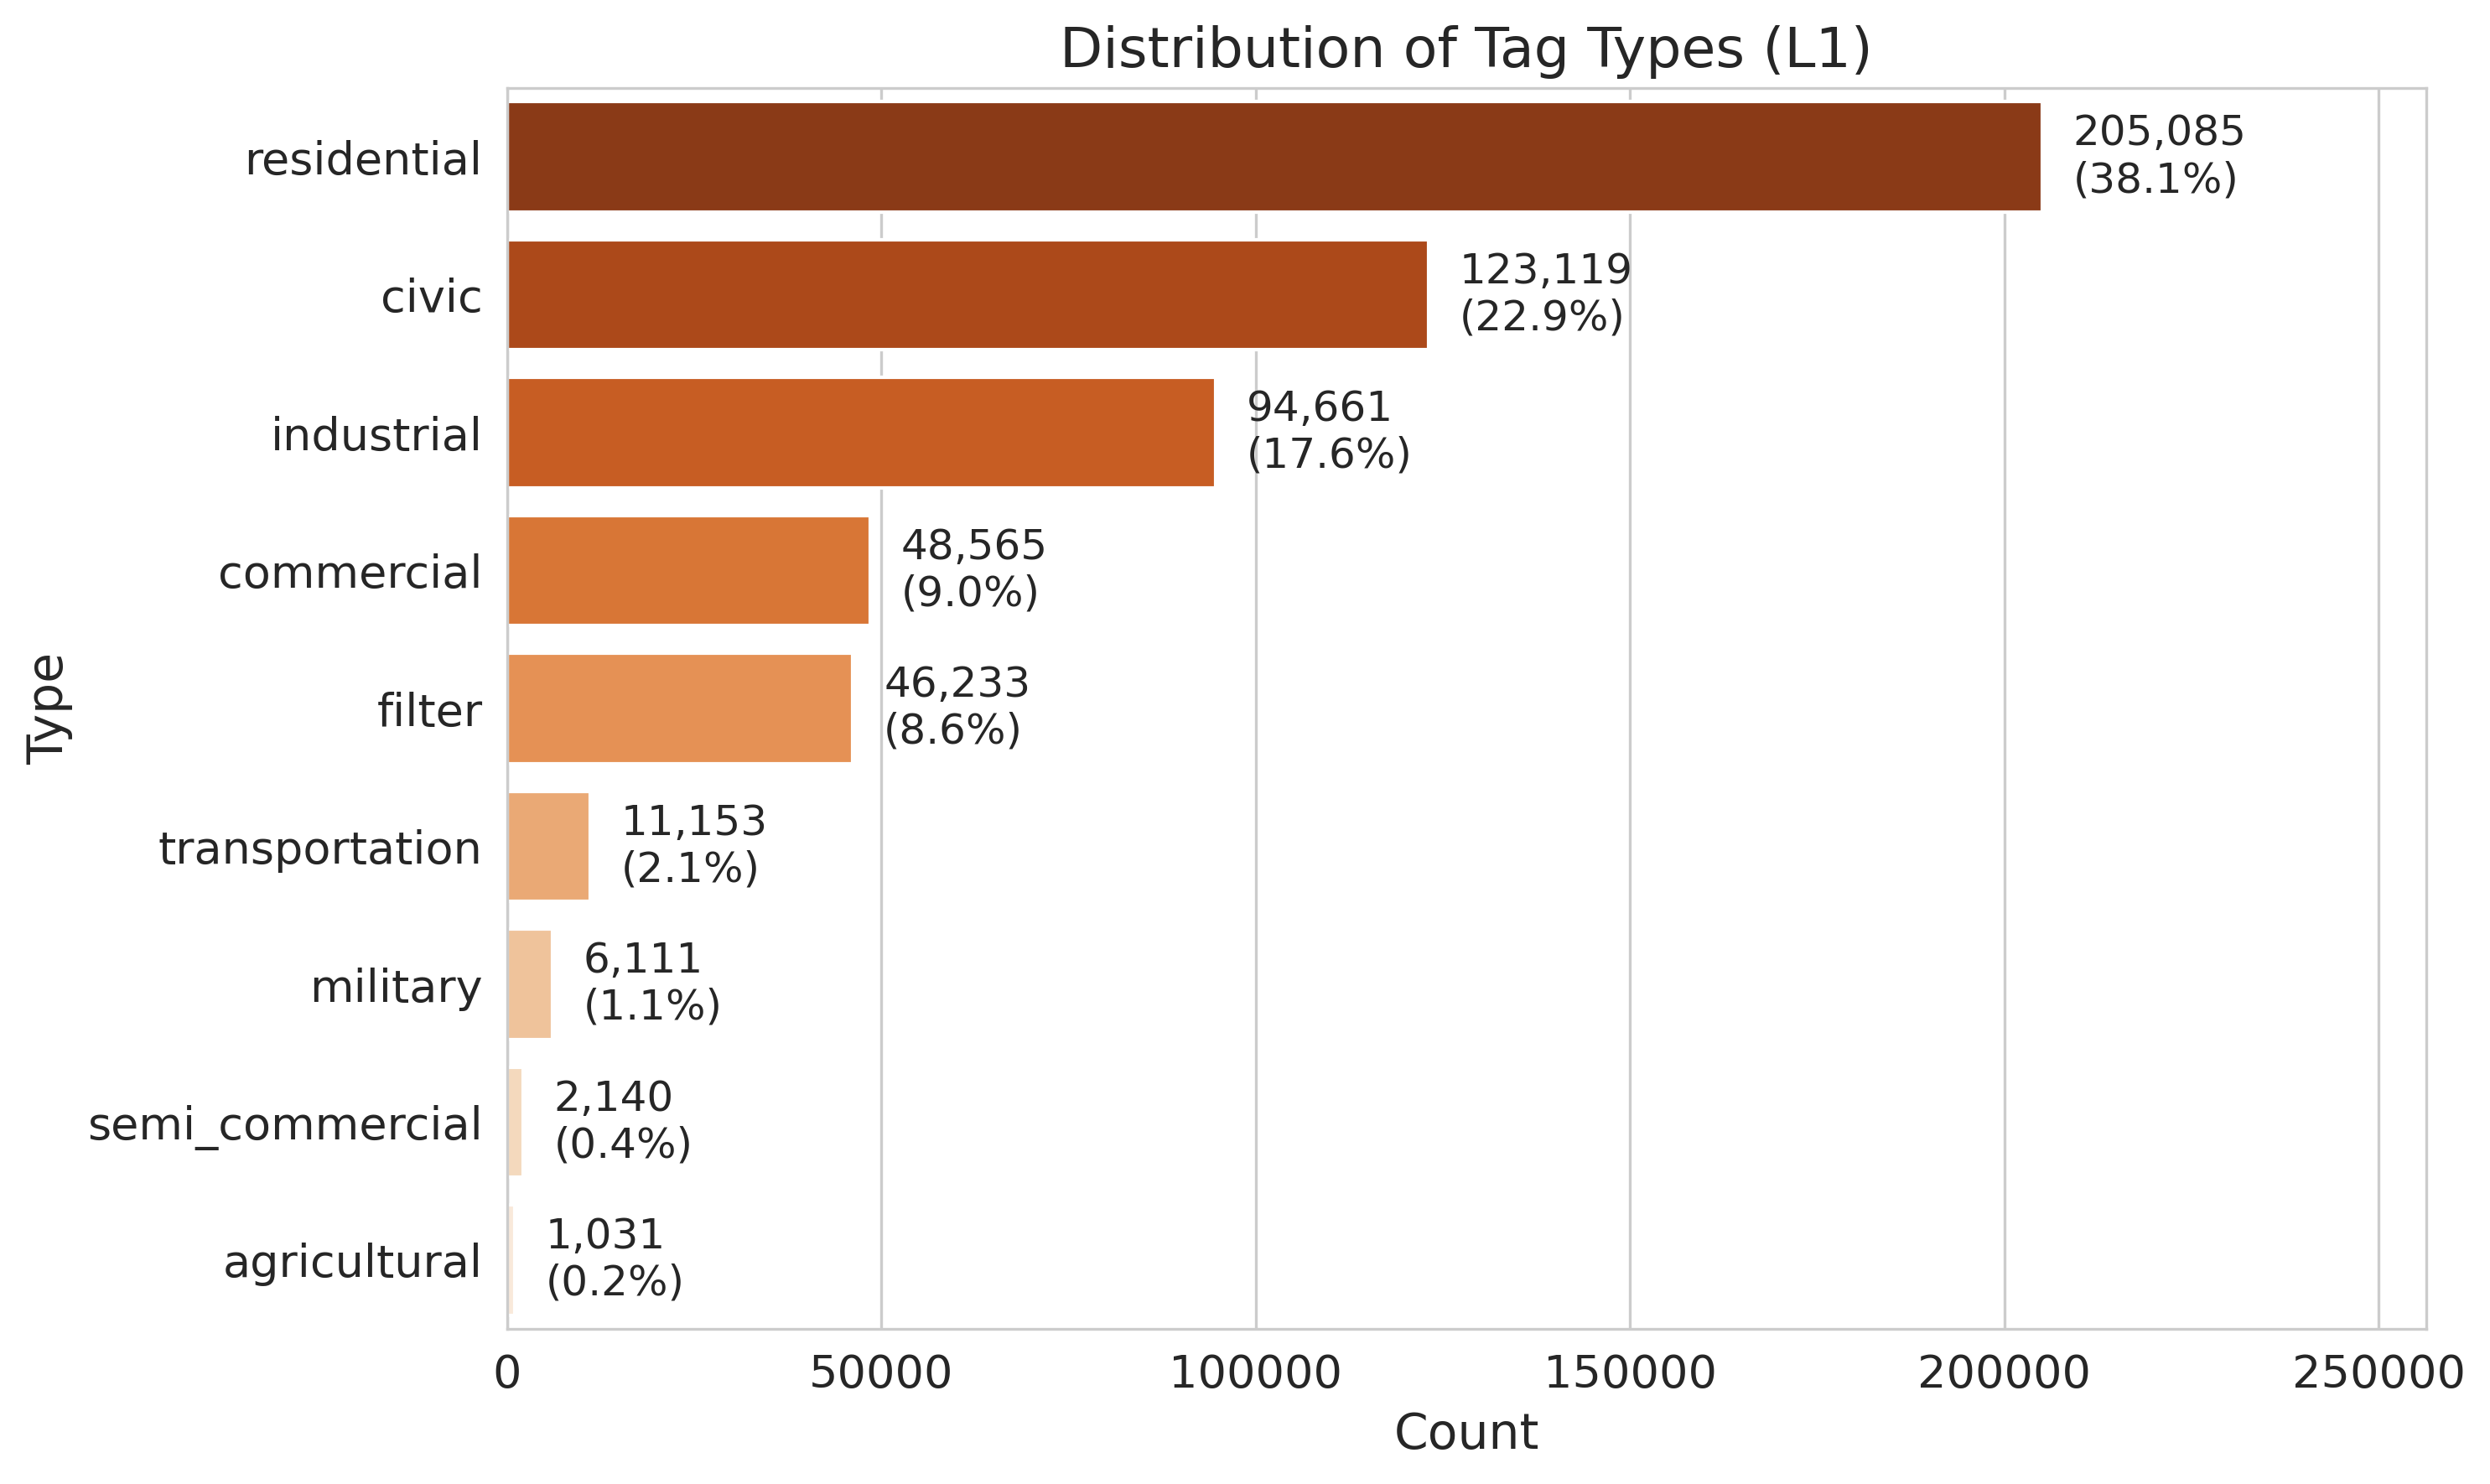

In [24]:
plot_l1_distribution(df=gdf_bldg, col='tag_l1', 
title='Distribution of Tag Types (L1)',palette='Oranges_r')

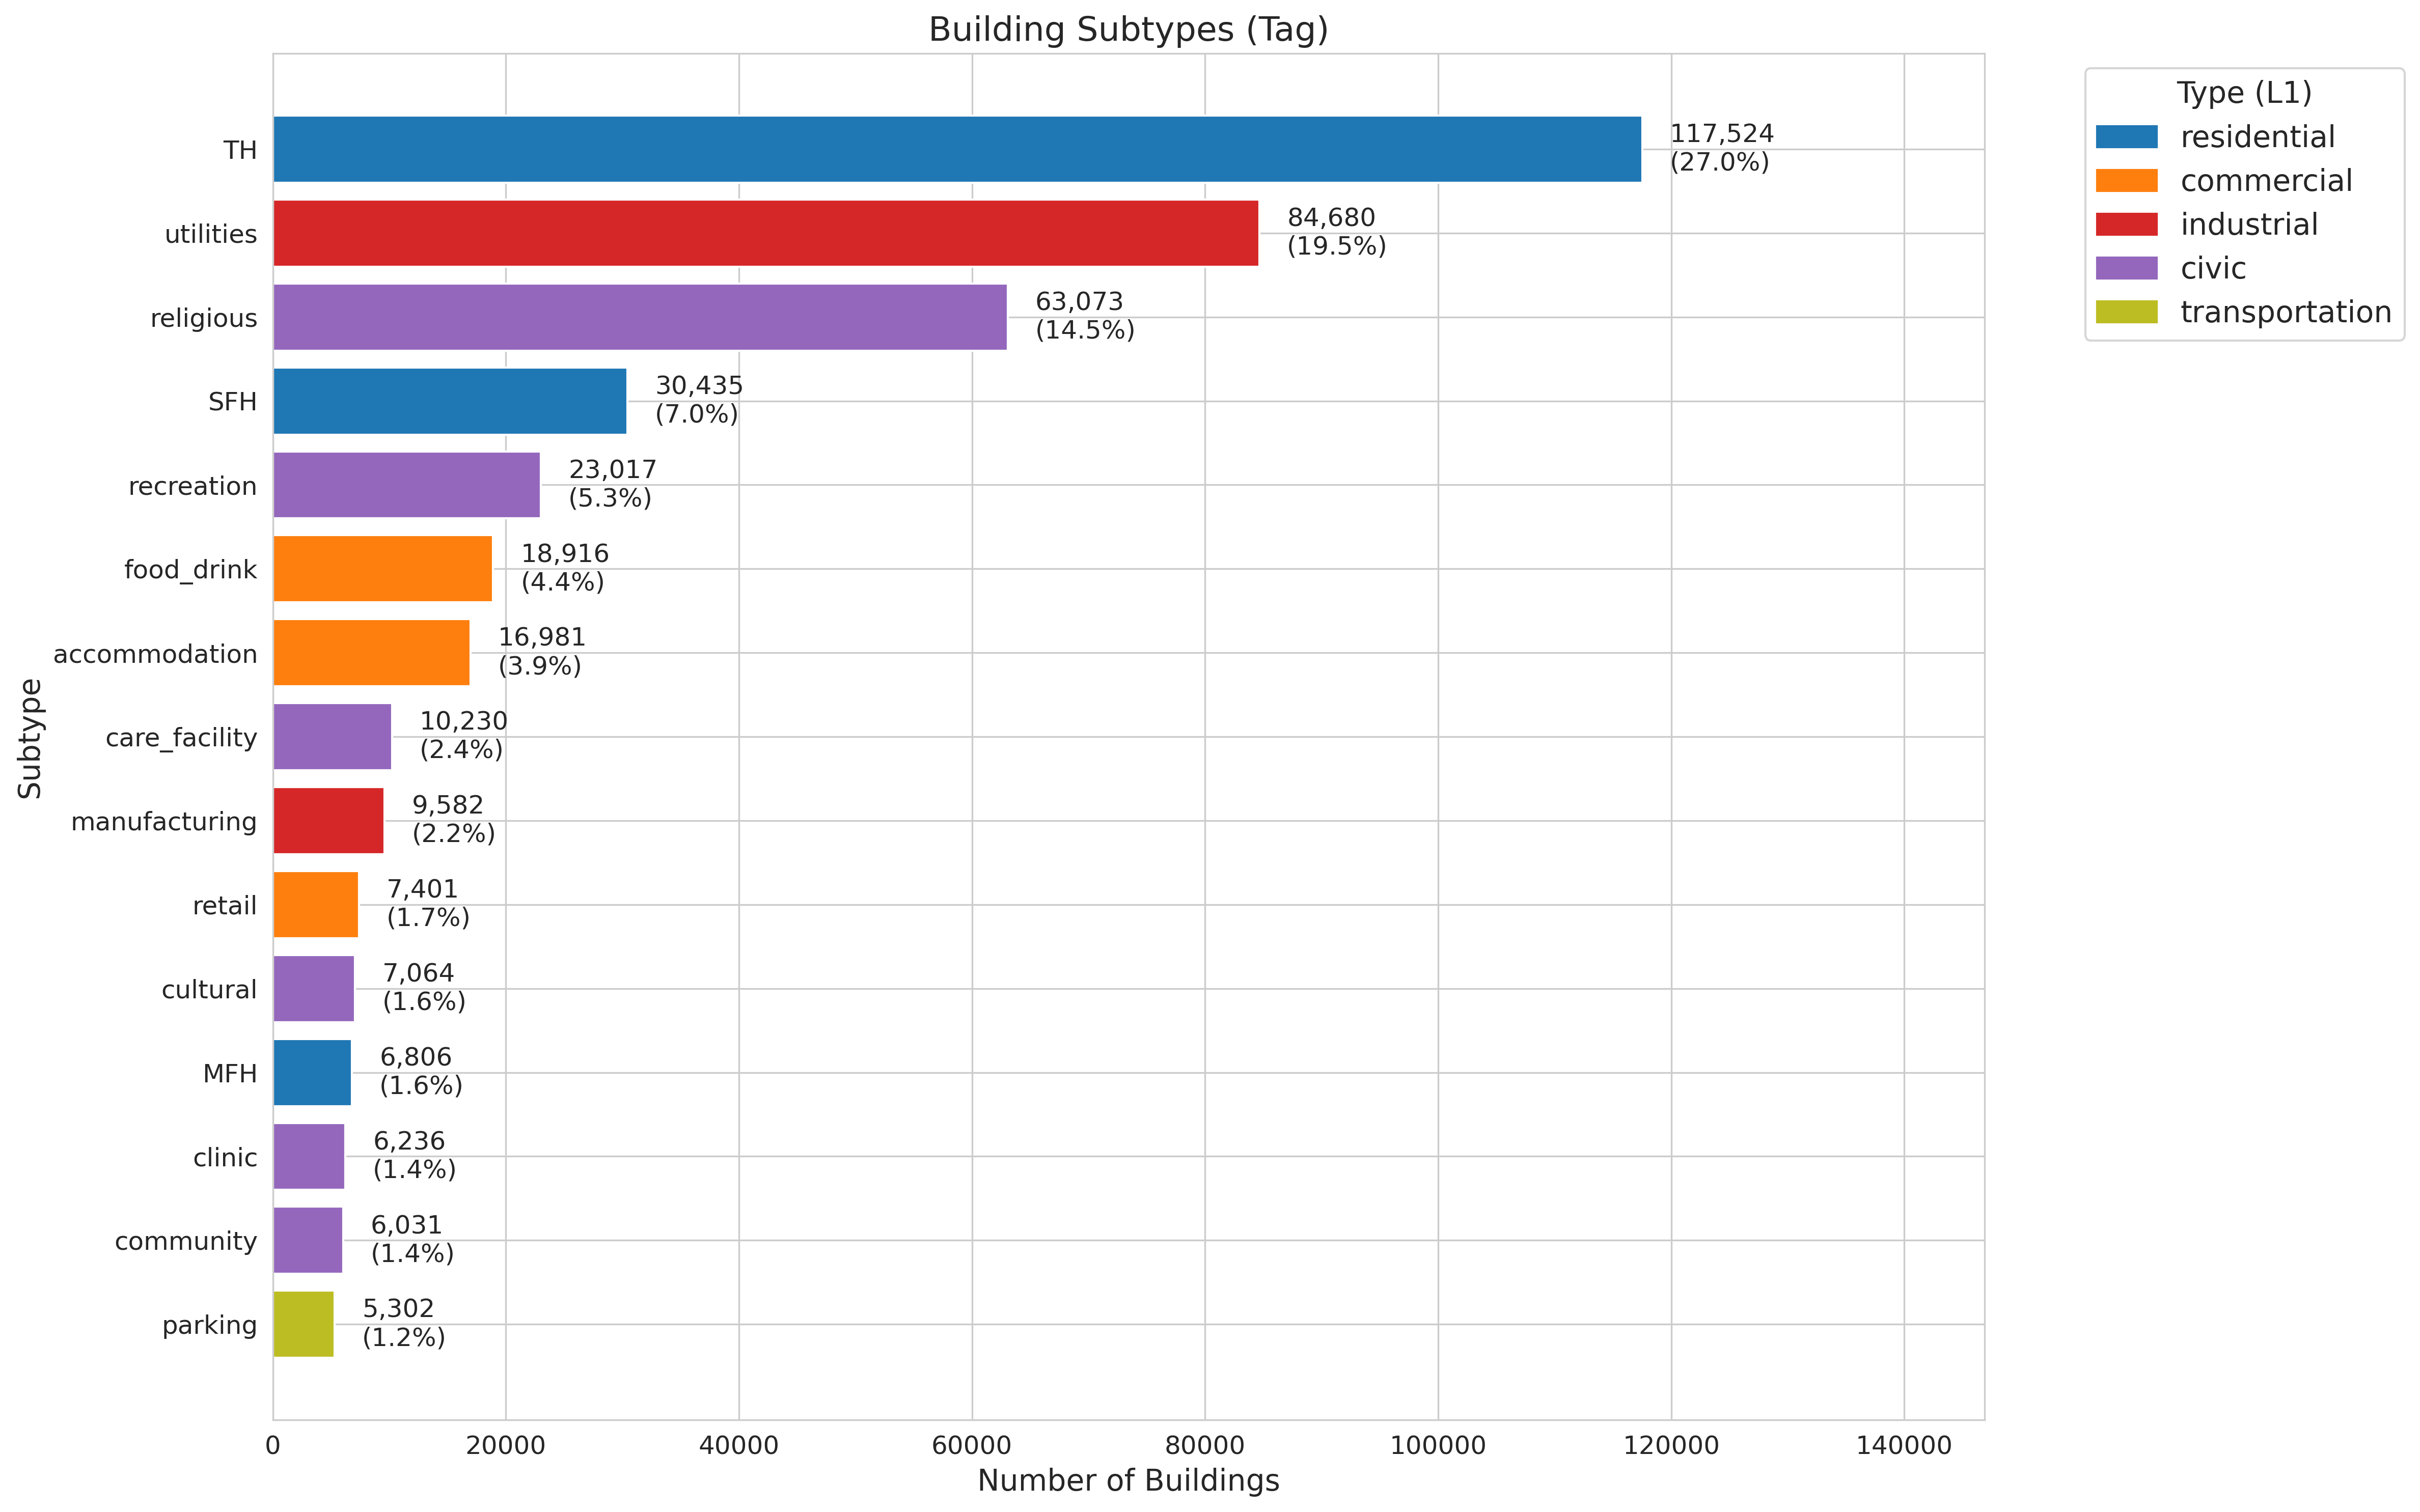

In [25]:
plot_top_subtypes_with_l1_colors(df=gdf_bldg, l1_col='tag_l1', l2_col='tag_l2', 
    top_n=15, title='Building Subtypes (Tag)')

In [26]:
sources = [
    ('building', 'building', 'Building'),
    ('building:use', 'buse', 'Building:use'),
    ('amenity', 'amenity', 'Amenity'),
    ('shop', 'shop', 'Shop')
]

coverage_rows = []
for tag_col, prefix, label in sources:
    if tag_col not in gdf_bldg.columns:
        continue

    raw_present = gdf_bldg[tag_col].notna()
    mapped = raw_present & gdf_bldg[f'{prefix}_l1'].notna()
    unmapped = raw_present & (~mapped)

    total = raw_present.sum()
    coverage_rows.append({
        'source': label,
        'mapped': mapped.sum(),
        'unmapped': unmapped.sum(),
        'total': total
    })

coverage_df = pd.DataFrame(coverage_rows)
coverage_df['mapped_pct'] = coverage_df['mapped'] / coverage_df['total'] * 100
coverage_df['unmapped_pct'] = coverage_df['unmapped'] / coverage_df['total'] * 100

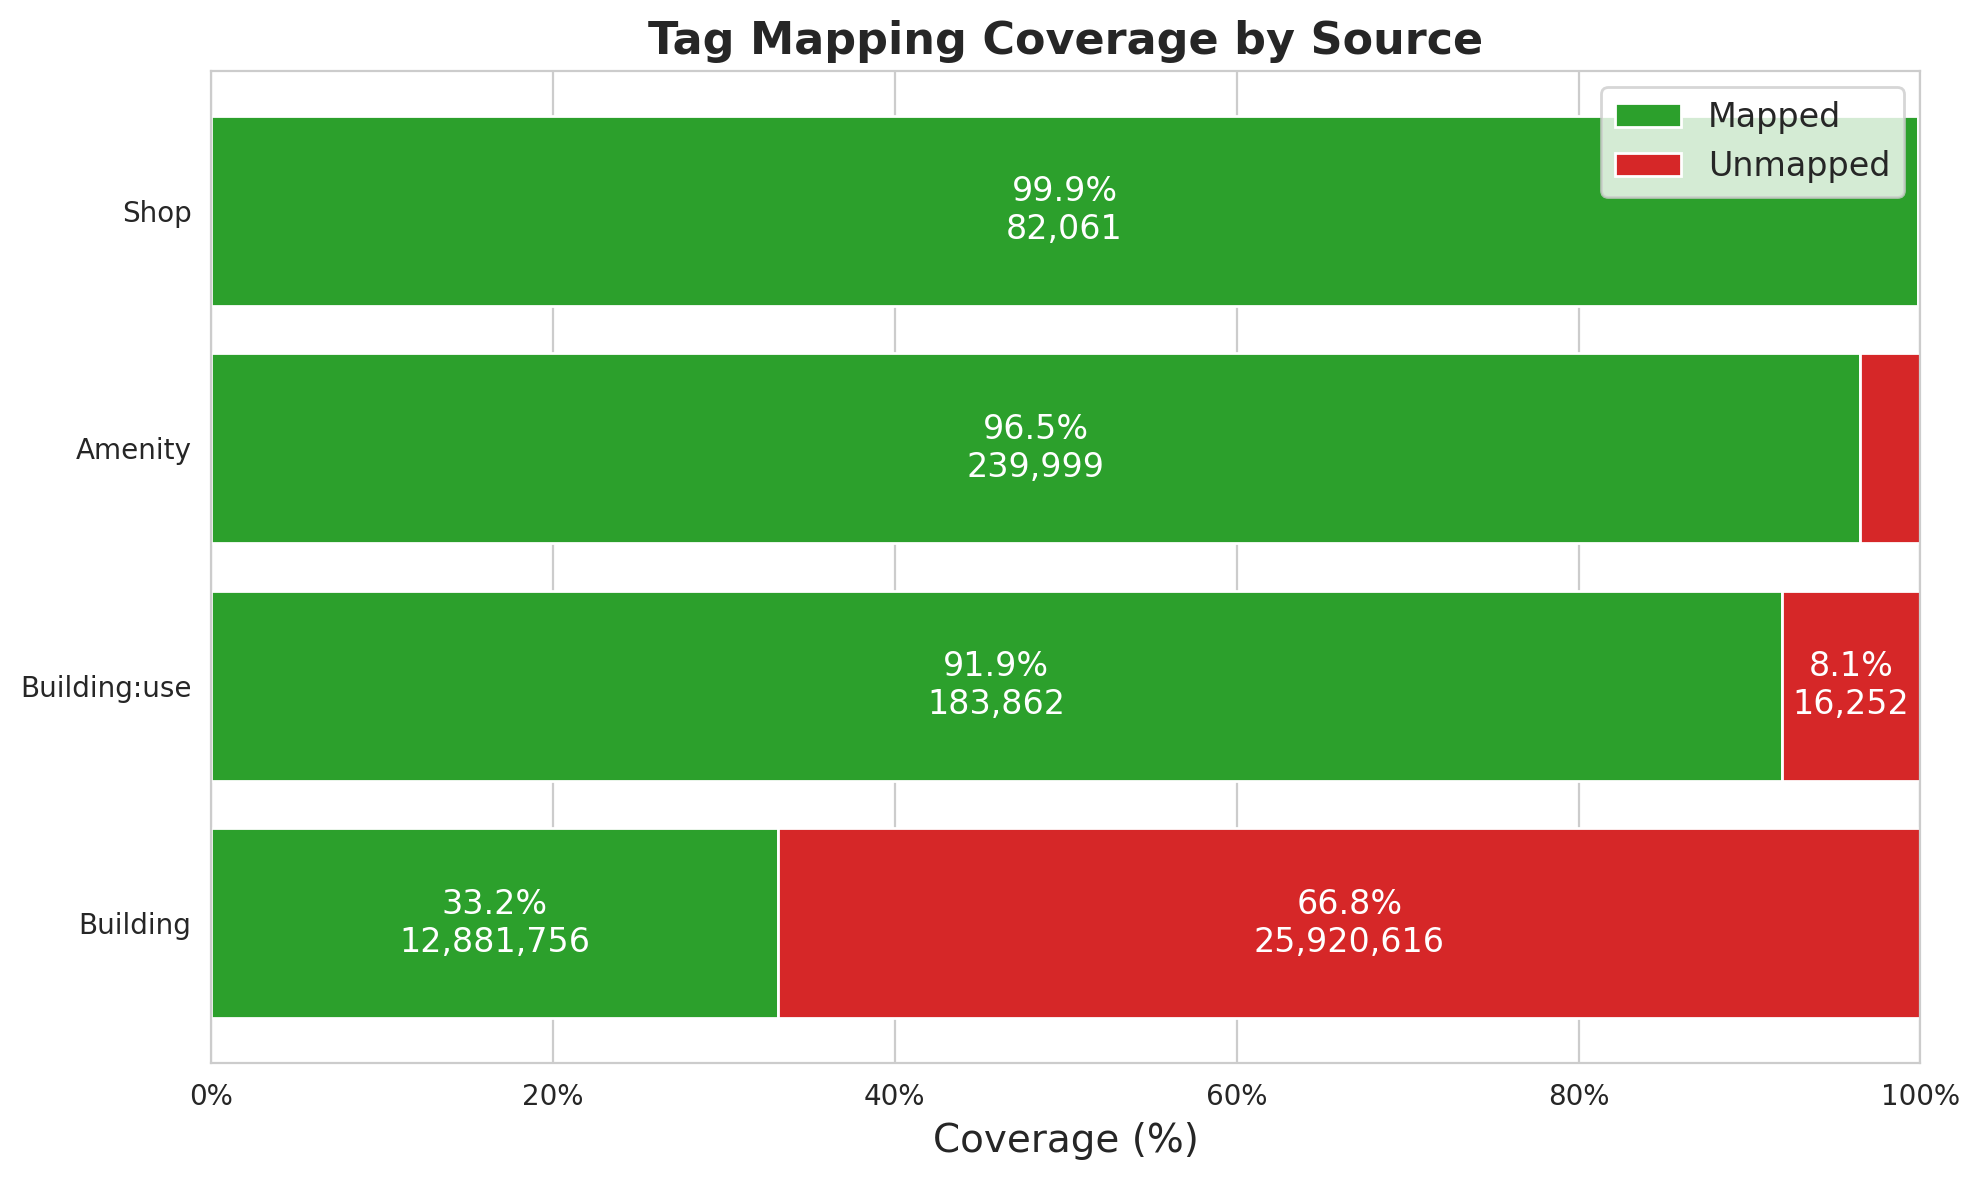

In [27]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

y = coverage_df['source']
ax.barh(y, coverage_df['mapped_pct'], color='#2ca02c', label='Mapped')
ax.barh(y, coverage_df['unmapped_pct'], left=coverage_df['mapped_pct'], color='#d62728', label='Unmapped')

ax.set_xlim(0, 100)
ax.set_xlabel('Coverage (%)', fontsize=14)
ax.set_title('Tag Mapping Coverage by Source', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}%'))

for i, row in coverage_df.iterrows():
    if row['mapped_pct'] > 4:
        ax.text(
            row['mapped_pct'] / 2,
            i,
            f"{row['mapped_pct']:.1f}%\n{row['mapped']:,}",
            va='center',
            ha='center',
            color='white',
            fontsize=12
        )
    if row['unmapped_pct'] > 4:
        ax.text(
            row['mapped_pct'] + row['unmapped_pct'] / 2,
            i,
            f"{row['unmapped_pct']:.1f}%\n{row['unmapped']:,}",
            va='center',
            ha='center',
            color='white',
            fontsize=12
        )

plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

In [28]:
gdf_bldg.to_parquet(os.path.join(DATA_DIR, 'processed', 'germany_buildings_mapped_final.parquet'), index=False)

## Stage 1 Classification

In [29]:
def apply_source(gdf, src_l1, src_l2, source_name, raw_col, src_is_mixed=None,):
    """
    Merges a mapped source (l1/l2 columns) into stage1 using three cases:
      A) stage1_l1 is empty        → fill everything from this source
      B) stage1_l1 == 'filter'     → override with this source (if real)
      C) stage1_l1 set, l2 missing → inherit l2 if this source agrees on l1
    
    Parameters
    ----------
    gdf         : GeoDataFrame (modified in place)
    src_l1      : str, column name of the source's L1  (e.g. 'amenity_l1')
    src_l2      : str, column name of the source's L2  (e.g. 'amenity_l2')
    source_name : str, label written to stage1_source  (e.g. 'amenity')
    src_is_mixed: str or None, column name for is_mixed flag; None → writes False
    raw_col     : str or None, the original OSM column (e.g. 'amenity', 'shop')
                  If provided, its raw value is written to raw_label
    """
    has_data = gdf[src_l1].notna()
    is_real  = has_data & (gdf[src_l1] != 'filter')

    # --- Case A: row has no classification yet ---
    mask_a = gdf['stage1_l1'].isna() & has_data
    gdf.loc[mask_a, 'stage1_l1']       = gdf.loc[mask_a, src_l1]
    gdf.loc[mask_a, 'stage1_l2']       = gdf.loc[mask_a, src_l2]
    gdf.loc[mask_a, 'stage1_is_mixed'] = gdf.loc[mask_a, src_is_mixed] if src_is_mixed else False
    gdf.loc[mask_a, 'stage1_source']   = source_name
    if raw_col and raw_col in gdf.columns:
        gdf.loc[mask_a, 'raw_label'] = gdf.loc[mask_a, raw_col]

    # --- Case B: row was flagged as filter, but this source has a real value ---
    mask_b = (gdf['stage1_l1'] == 'filter') & is_real
    gdf.loc[mask_b, 'stage1_l1']       = gdf.loc[mask_b, src_l1]
    gdf.loc[mask_b, 'stage1_l2']       = gdf.loc[mask_b, src_l2]
    gdf.loc[mask_b, 'stage1_is_mixed'] = gdf.loc[mask_b, src_is_mixed] if src_is_mixed else False
    gdf.loc[mask_b, 'stage1_source']   = f'{source_name}_override_filter'
    if raw_col and raw_col in gdf.columns:
        gdf.loc[mask_b, 'raw_label'] = gdf.loc[mask_b, raw_col]

    # Case C: L1 already set, L2 missing, source agrees on L1 → inherit L2
    mask_c = (
        gdf['stage1_l1'].notna() &
        (gdf['stage1_l1'] != 'filter') &
        gdf['stage1_l2'].isna() &
        is_real &
        gdf[src_l2].notna() &                    # ← ADD THIS: source must actually have an L2
        (gdf[src_l1] == gdf['stage1_l1'])
    )
    gdf.loc[mask_c, 'stage1_l2']     = gdf.loc[mask_c, src_l2]
    gdf.loc[mask_c, 'stage1_source'] = gdf.loc[mask_c, 'stage1_source'] + f'_+{source_name}_l2'
    if raw_col and raw_col in gdf.columns:
        gdf.loc[mask_c, 'raw_label'] = gdf.loc[mask_c, raw_col]

    # Diagnostics
    print(f"[{source_name}]  A(filled): {mask_a.sum():,}  |  B(filter override): {mask_b.sum():,}  |  C(l2 inherited): {mask_c.sum():,}")

In [30]:
def distribution_report(gdf, step_name):
    """Prints a clean, text-based summary of the current classification status."""
    total = len(gdf)
    filled     = (gdf['stage1_l1'].notna() & (gdf['stage1_l1'] != 'filter')).sum()
    filtered   = (gdf['stage1_l1'] == 'filter').sum()
    empty      = gdf['stage1_l1'].isna().sum()

    # L2 coverage among classified rows
    classified_mask = gdf['stage1_l1'].notna() & (gdf['stage1_l1'] != 'filter')
    l2_filled   = (classified_mask & gdf['stage1_l2'].notna()).sum()
    l2_missing  = (classified_mask & gdf['stage1_l2'].isna()).sum()
    l2_fill_pct    = l2_filled / filled * 100 if filled > 0 else 0
    l2_missing_pct = l2_missing / filled * 100 if filled > 0 else 0

    print(f"\n{'='*50}")
    print(f"  {step_name}")
    print(f"{'='*50}")
    print(f"  Total          : {total:>12,}")
    print(f"  Classified     : {filled:>12,}  ({filled/total*100:.1f}%)")
    print(f"    └ with L2    : {l2_filled:>12,}  ({l2_fill_pct:.1f}% of classified)")
    print(f"    └ no L2      : {l2_missing:>12,}  ({l2_missing_pct:.1f}% of classified)")
    print(f"  Filter         : {filtered:>12,}  ({filtered/total*100:.1f}%)")
    print(f"  Unclassified   : {empty:>12,}  ({empty/total*100:.1f}%)")
    print(f"\n  L1 breakdown:")
    print(gdf['stage1_l1'].value_counts(dropna=False).to_string())



def plot_distribution(gdf, step_name):
    """Generates a two-panel dashboard with an optimized layout ratio."""
    total = len(gdf)
    filled   = (gdf['stage1_l1'].notna() & (gdf['stage1_l1'] != 'filter')).sum()
    filtered = (gdf['stage1_l1'] == 'filter').sum()
    empty    = gdf['stage1_l1'].isna().sum()
    
    # NEW: gridspec_kw allocates 1 part of the width to the donut, and 2.5 parts to the bar chart
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=300, gridspec_kw={'width_ratios': [1, 2]})
    
    fig.suptitle(f"Classification Distribution: {step_name}", fontsize=24, fontweight='bold')
    
    # --- CHART 1: Overall Status (Donut Chart) ---
    labels = ['Classified', 'Filtered', 'Unclassified']
    sizes = [filled, filtered, empty]
    colors = ['#2ca02c', '#d62728', '#7f7f7f']
    
    valid_data = [(l, s, c) for l, s, c in zip(labels, sizes, colors) if s > 0]
    if valid_data:
        labels, sizes, colors = zip(*valid_data)
        axes[0].pie(
            sizes, labels=labels, colors=colors, autopct='%1.1f%%', 
            startangle=90, wedgeprops=dict(width=0.4, edgecolor='w'),
            textprops={'fontsize': 16}
        )
        axes[0].set_title("Overall Pipeline Status", fontsize=20)
    
    # --- CHART 2: L1 Category Breakdown (Horizontal Bar) ---
    classified_only = gdf[(gdf['stage1_l1'].notna()) & (gdf['stage1_l1'] != 'filter')]
    
    if not classified_only.empty:
        l1_counts = classified_only['stage1_l1'].value_counts()
        total_classified = l1_counts.sum()
        max_val = l1_counts.max()
        
        sns.barplot(
            x=l1_counts.values, 
            y=l1_counts.index, 
            ax=axes[1], 
            palette='viridis',
            hue=l1_counts.index,
            legend=False
        )
        axes[1].set_title("Classified Building Types (L1)", fontsize=20)
        axes[1].set_xlabel("Number of Buildings (in Millions)", fontsize=18)
        axes[1].set_ylabel("")
        axes[1].tick_params(axis='both', which='major', labelsize=16)
        axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:g}'))   
             
        # Add exact numbers AND percentages next to the bars
        for i, v in enumerate(l1_counts.values):
            pct = (v / total_classified) * 100
            axes[1].text(v + (max_val * 0.01), i, f"{v:,} ({pct:.1f}%)", va='center', fontsize=14)
            
        # Extend the x-axis so the labels don't get cut off
        axes[1].set_xlim(0, max_val * 1.3)
            
    else:
        axes[1].text(0.5, 0.5, "No Classified Buildings Yet", ha='center', va='center', fontsize=20)
        axes[1].axis('off')

    # tight_layout helps ensure the padding around the altered width ratios is clean
    plt.tight_layout()
    plt.show()

def plot_l2_fill_rate(gdf, step_name):
    classified = gdf[gdf['stage1_l1'].notna() & (gdf['stage1_l1'] != 'filter')].copy()
    
    if classified.empty:
        print(f"[plot_l2_fill_rate] No classified data yet at: {step_name}")
        return

    classified['has_l2'] = classified['stage1_l2'].notna()
    
    summary = classified.groupby(['stage1_l1', 'has_l2']).size().unstack(fill_value=0)
    summary.columns = [str(c) for c in summary.columns]

    rename_map = {'False': 'No L2', 'True': 'Has L2', False: 'No L2', True: 'Has L2'}
    summary = summary.rename(columns=rename_map)

    for col in ['No L2', 'Has L2']:
        if col not in summary.columns:
            summary[col] = 0.0

    summary = summary[['No L2', 'Has L2']]
    raw_counts = summary.copy()  # keep raw counts for labels
    summary_pct = summary.div(summary.sum(axis=1), axis=0)  # normalize to proportions

    fig, ax = plt.subplots(figsize=(16, 6))

    summary_pct.plot(kind='barh', stacked=True, color=['#d62728', '#2ca02c'],
                     edgecolor='white', ax=ax)

    # Add labels inside/on each segment
    for i, (l1_cat, row) in enumerate(summary_pct.iterrows()):
        no_l2_count  = int(raw_counts.loc[l1_cat, 'No L2'])
        has_l2_count = int(raw_counts.loc[l1_cat, 'Has L2'])
        no_l2_pct    = row['No L2']
        has_l2_pct   = row['Has L2']

        # Label for "No L2" (red segment) — only if wide enough to fit
        if no_l2_pct > 0.08:
            ax.text(
                no_l2_pct / 2, i,
                f"{no_l2_count:,}\n({no_l2_pct*100:.1f}%)",
                ha='center', va='center', fontsize=10,
                color='white', fontweight='bold'
            )

        # Label for "Has L2" (green segment)
        if has_l2_pct > 0.08:
            ax.text(
                no_l2_pct + has_l2_pct / 2, i,
                f"{has_l2_count:,}\n({has_l2_pct*100:.1f}%)",
                ha='center', va='center', fontsize=12,
                color='white', fontweight='bold'
            )

    ax.set_title(f'L2 Fill Rate per L1 — {step_name}', fontsize=16)
    ax.set_xlabel('Proportion of Buildings', fontsize=16)
    ax.set_ylabel('')
    ax.legend(['Missing L2', 'Has L2'], fontsize=12)
    ax.tick_params(labelsize=16)
    plt.tight_layout()
    plt.show()

def evaluate_step(gdf, step_name):
    """
    The master wrapper function. 
    Prints the text report and displays the visual dashboard.
    """
    distribution_report(gdf, step_name)
    plot_distribution(gdf, step_name)
    plot_l2_fill_rate(gdf, step_name)

In [31]:

# Write to final where building tag gave a real result
has_real = gdf_bldg['building_l1'].notna() & (gdf_bldg['building_l1'] != 'filter')
gdf_bldg.loc[has_real, 'stage1_l1']       = gdf_bldg.loc[has_real, 'building_l1']
gdf_bldg.loc[has_real, 'stage1_l2']       = gdf_bldg.loc[has_real, 'building_l2']
gdf_bldg.loc[has_real, 'stage1_is_mixed'] = gdf_bldg.loc[has_real, 'building_is_mixed']
gdf_bldg.loc[has_real, 'stage1_source']   = 'building'
gdf_bldg.loc[has_real, 'raw_label'] = gdf_bldg.loc[has_real, 'building']

# Also mark filters explicitly
is_filter = gdf_bldg['building_l1'] == 'filter'
gdf_bldg.loc[is_filter & gdf_bldg['stage1_l1'].isna(), 'stage1_l1']     = 'filter'
gdf_bldg.loc[is_filter & gdf_bldg['stage1_source'].isna(), 'stage1_source'] = 'building_filter'
gdf_bldg.loc[is_filter & gdf_bldg['raw_label'].isna(), 'raw_label'] = gdf_bldg.loc[is_filter, 'building']




  After Step 1: building tag
  Total          :   38,802,372
  Classified     :    8,804,626  (22.7%)
    └ with L2    :    4,034,230  (45.8% of classified)
    └ no L2      :    4,770,396  (54.2% of classified)
  Filter         :    4,077,130  (10.5%)
  Unclassified   :   25,920,616  (66.8%)

  L1 breakdown:
stage1_l1
NaN                25920616
residential         7699697
filter              4077130
commercial           320805
agricultural         312159
industrial           235010
civic                215887
transportation        15783
military               5221
semi_commercial          64


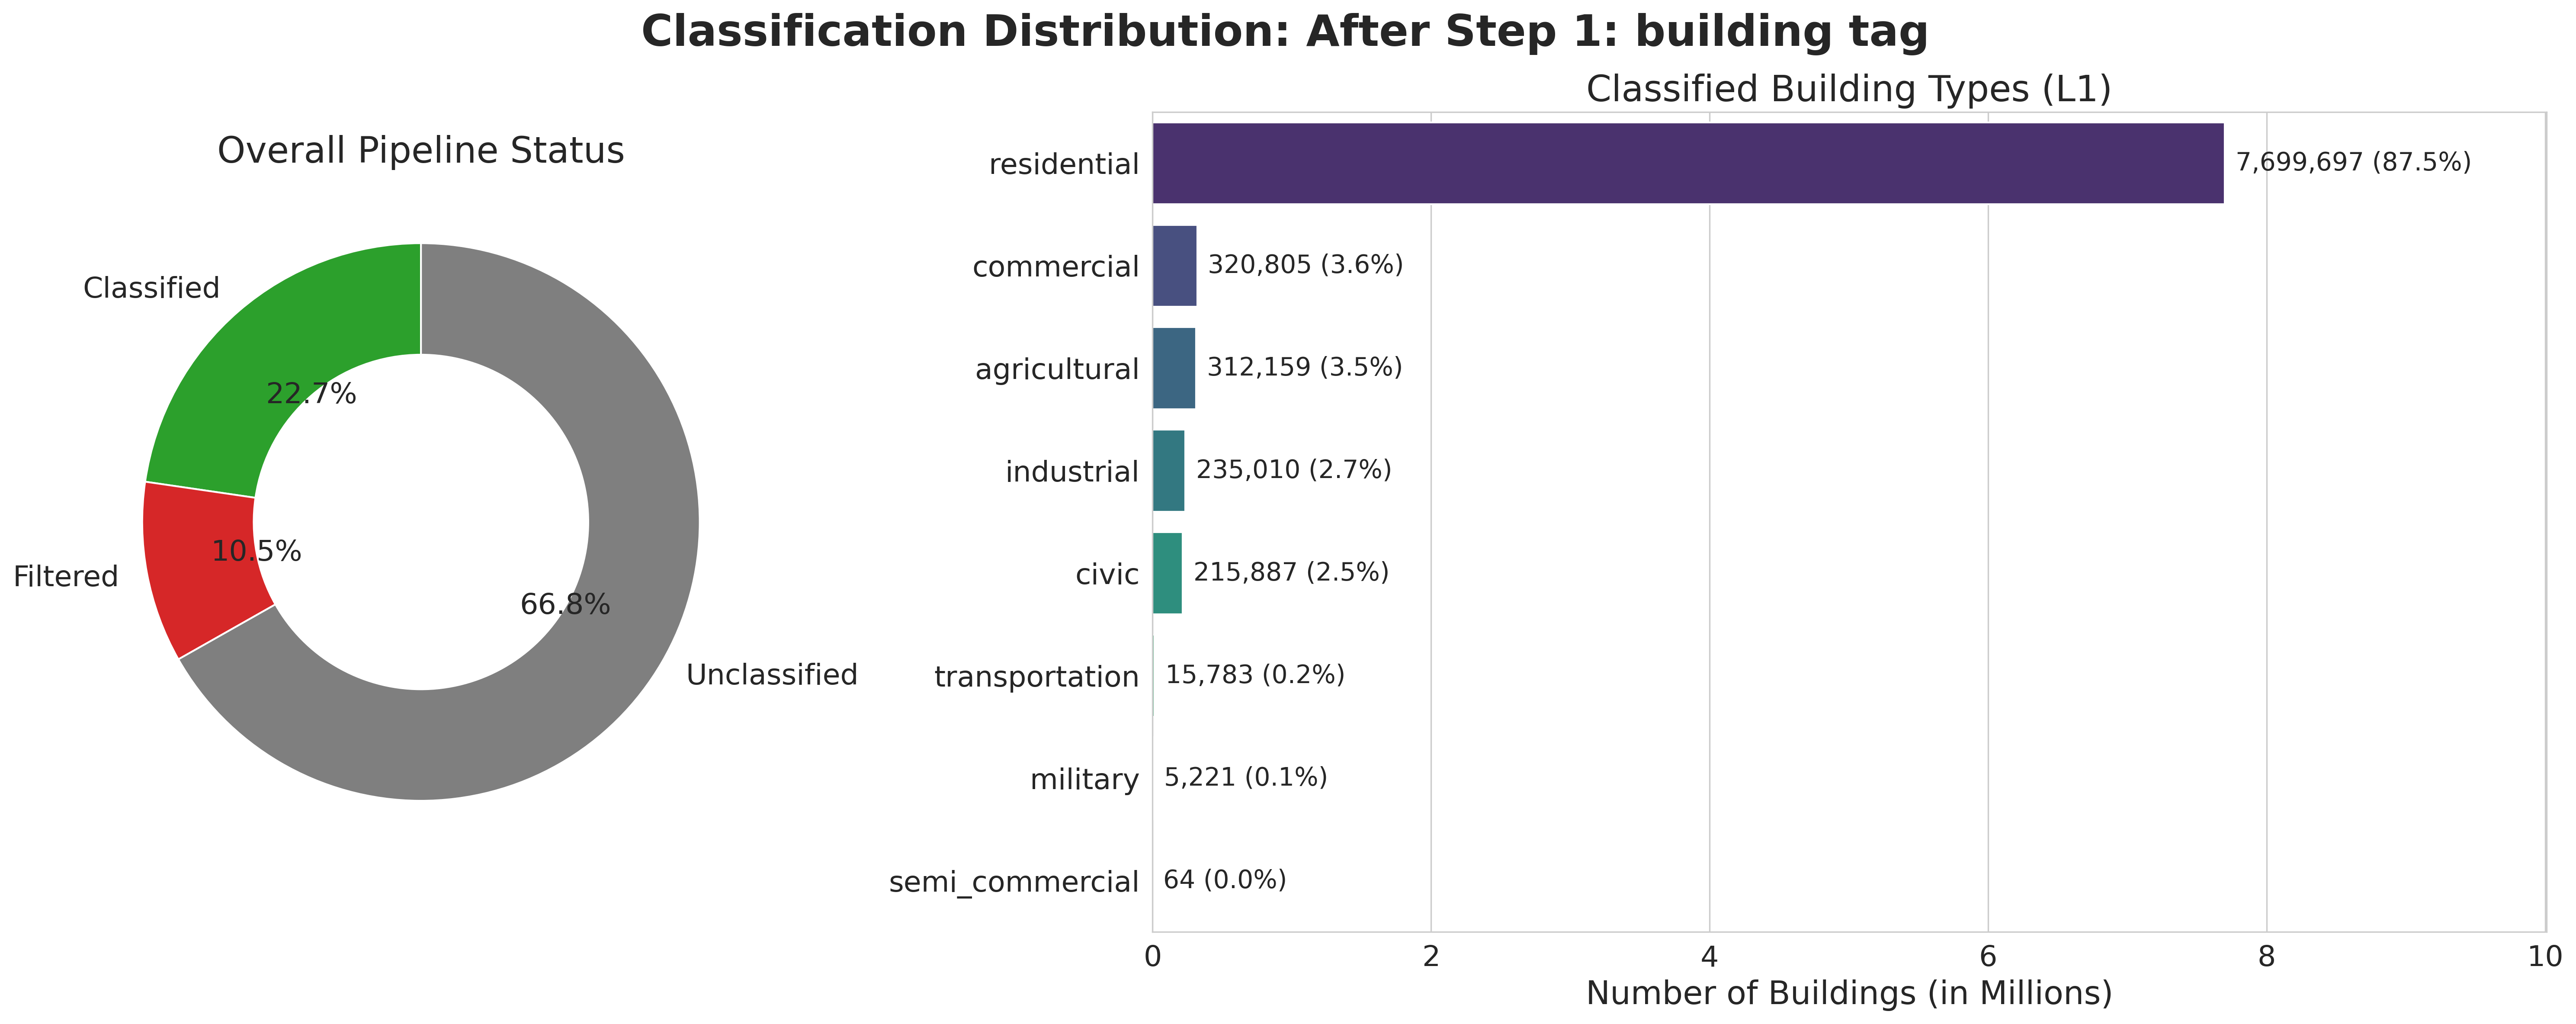

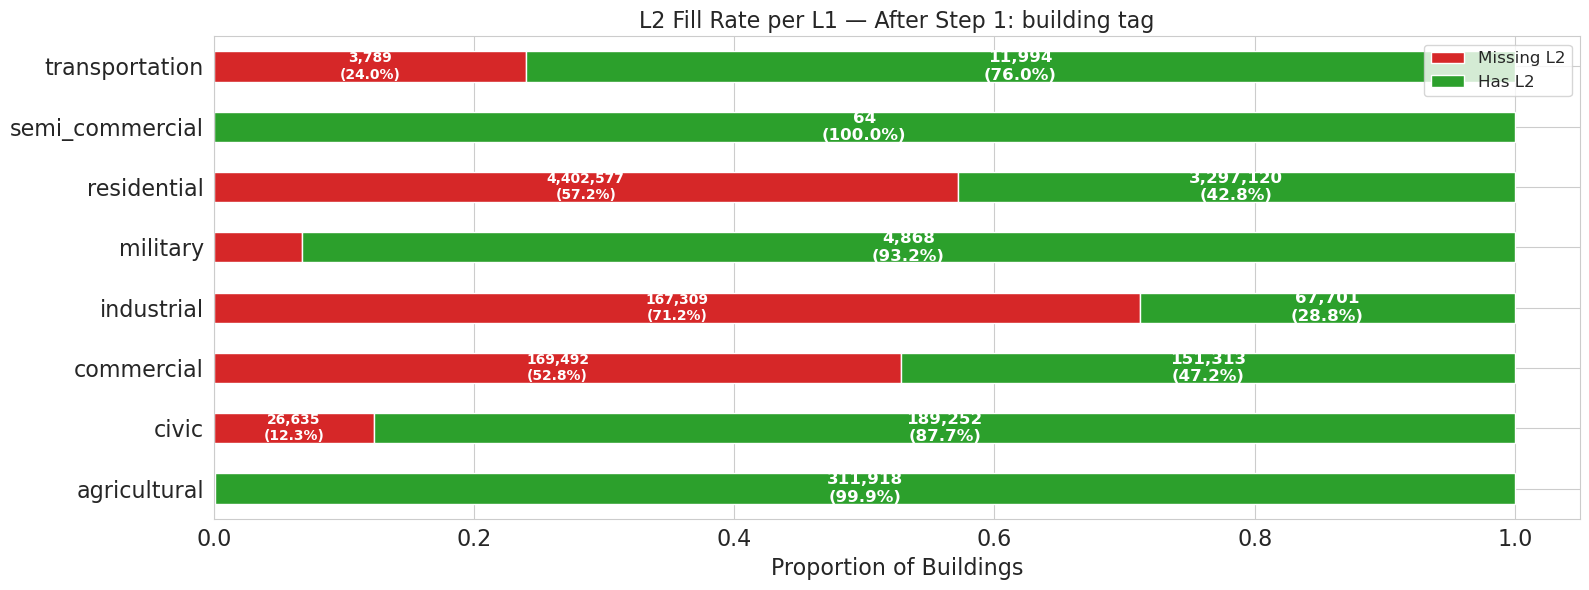

In [32]:
evaluate_step(gdf_bldg, "After Step 1: building tag")

Unclassified increased from 66.6% to 66.7% (0.1% increase) due to invalid tags present in the building tags (single characters, meaningless tags) that were assigned to null

In [33]:
apply_source(gdf_bldg, 'buse_l1',    'buse_l2',    'building:use', 'building:use', src_is_mixed='buse_is_mixed')

[building:use]  A(filled): 35,535  |  B(filter override): 412  |  C(l2 inherited): 354



  After Step 2: + building:use
  Total          :   38,802,372
  Classified     :    8,839,946  (22.8%)
    └ with L2    :    4,039,771  (45.7% of classified)
    └ no L2      :    4,800,175  (54.3% of classified)
  Filter         :    4,077,345  (10.5%)
  Unclassified   :   25,885,081  (66.7%)

  L1 breakdown:
stage1_l1
NaN                25885081
residential         7725274
filter              4077345
commercial           323866
agricultural         312693
industrial           237327
civic                217281
transportation        15873
military               5221
semi_commercial        2411


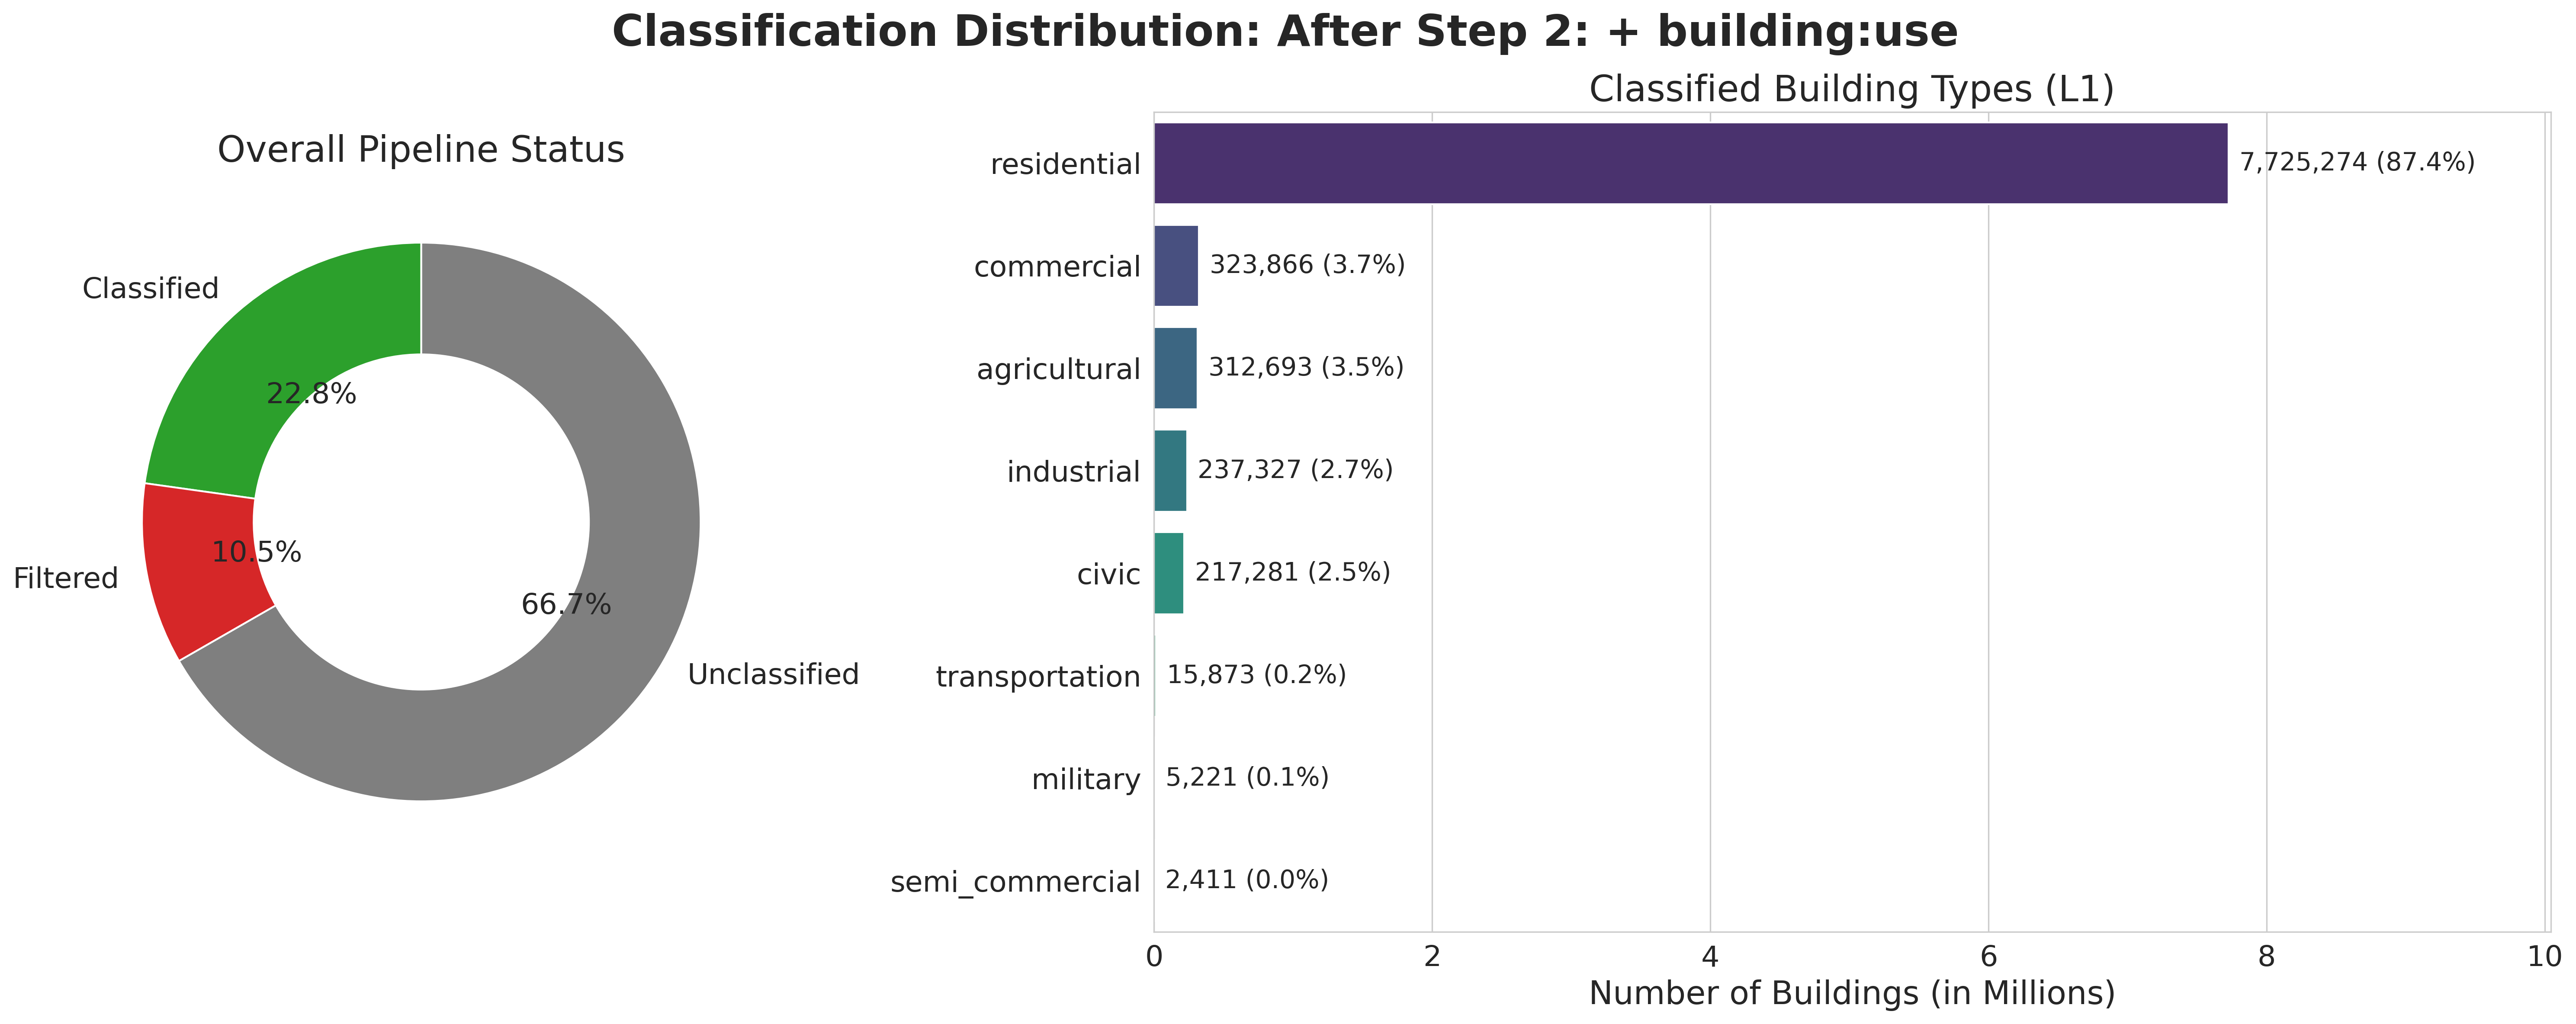

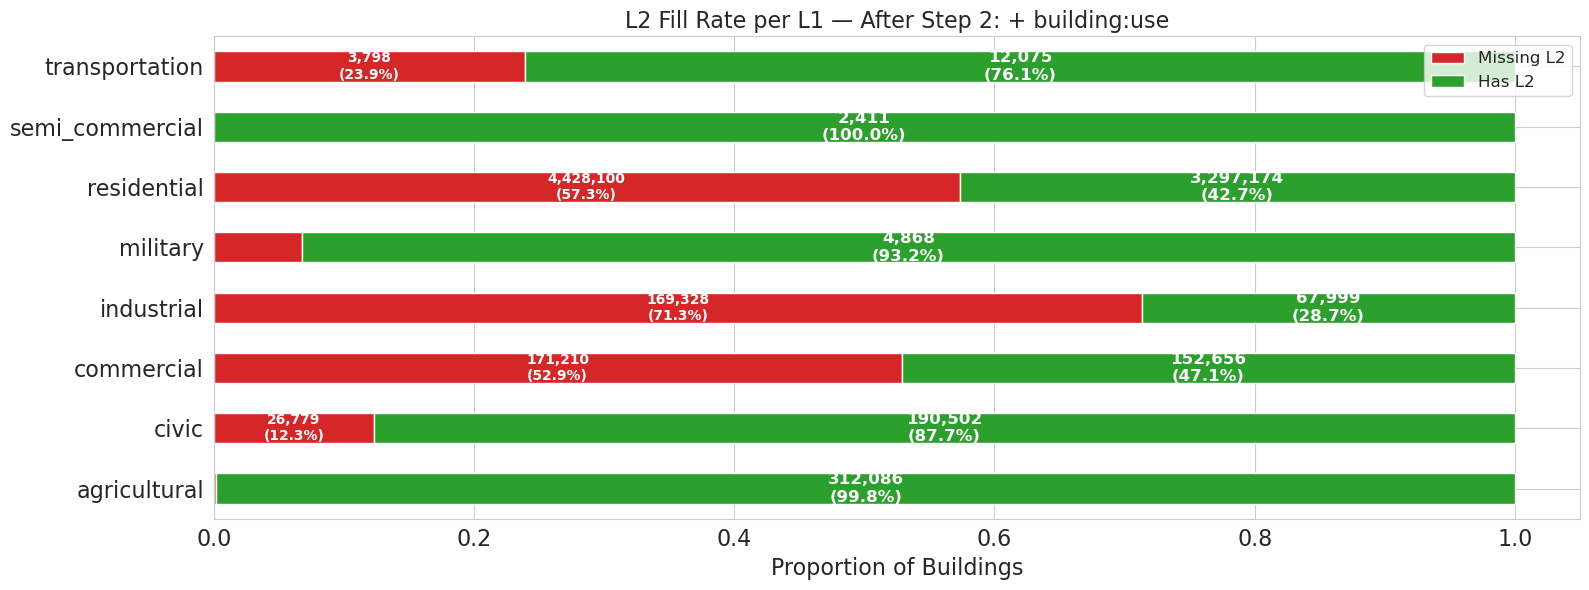

In [34]:
evaluate_step(gdf_bldg, "After Step 2: + building:use")

In [35]:
apply_source(gdf_bldg, 'amenity_l1', 'amenity_l2', 'amenity', 'amenity')

[amenity]  A(filled): 134,340  |  B(filter override): 2,594  |  C(l2 inherited): 12,469



  After Step 3: + amenity
  Total          :   38,802,372
  Classified     :    8,948,380  (23.1%)
    └ with L2    :    4,159,915  (46.5% of classified)
    └ no L2      :    4,788,465  (53.5% of classified)
  Filter         :    4,103,251  (10.6%)
  Unclassified   :   25,750,741  (66.4%)

  L1 breakdown:
stage1_l1
NaN                25750741
residential         7725289
filter              4103251
commercial           364199
agricultural         313067
civic                284826
industrial           237444
transportation        15923
military               5221
semi_commercial        2411


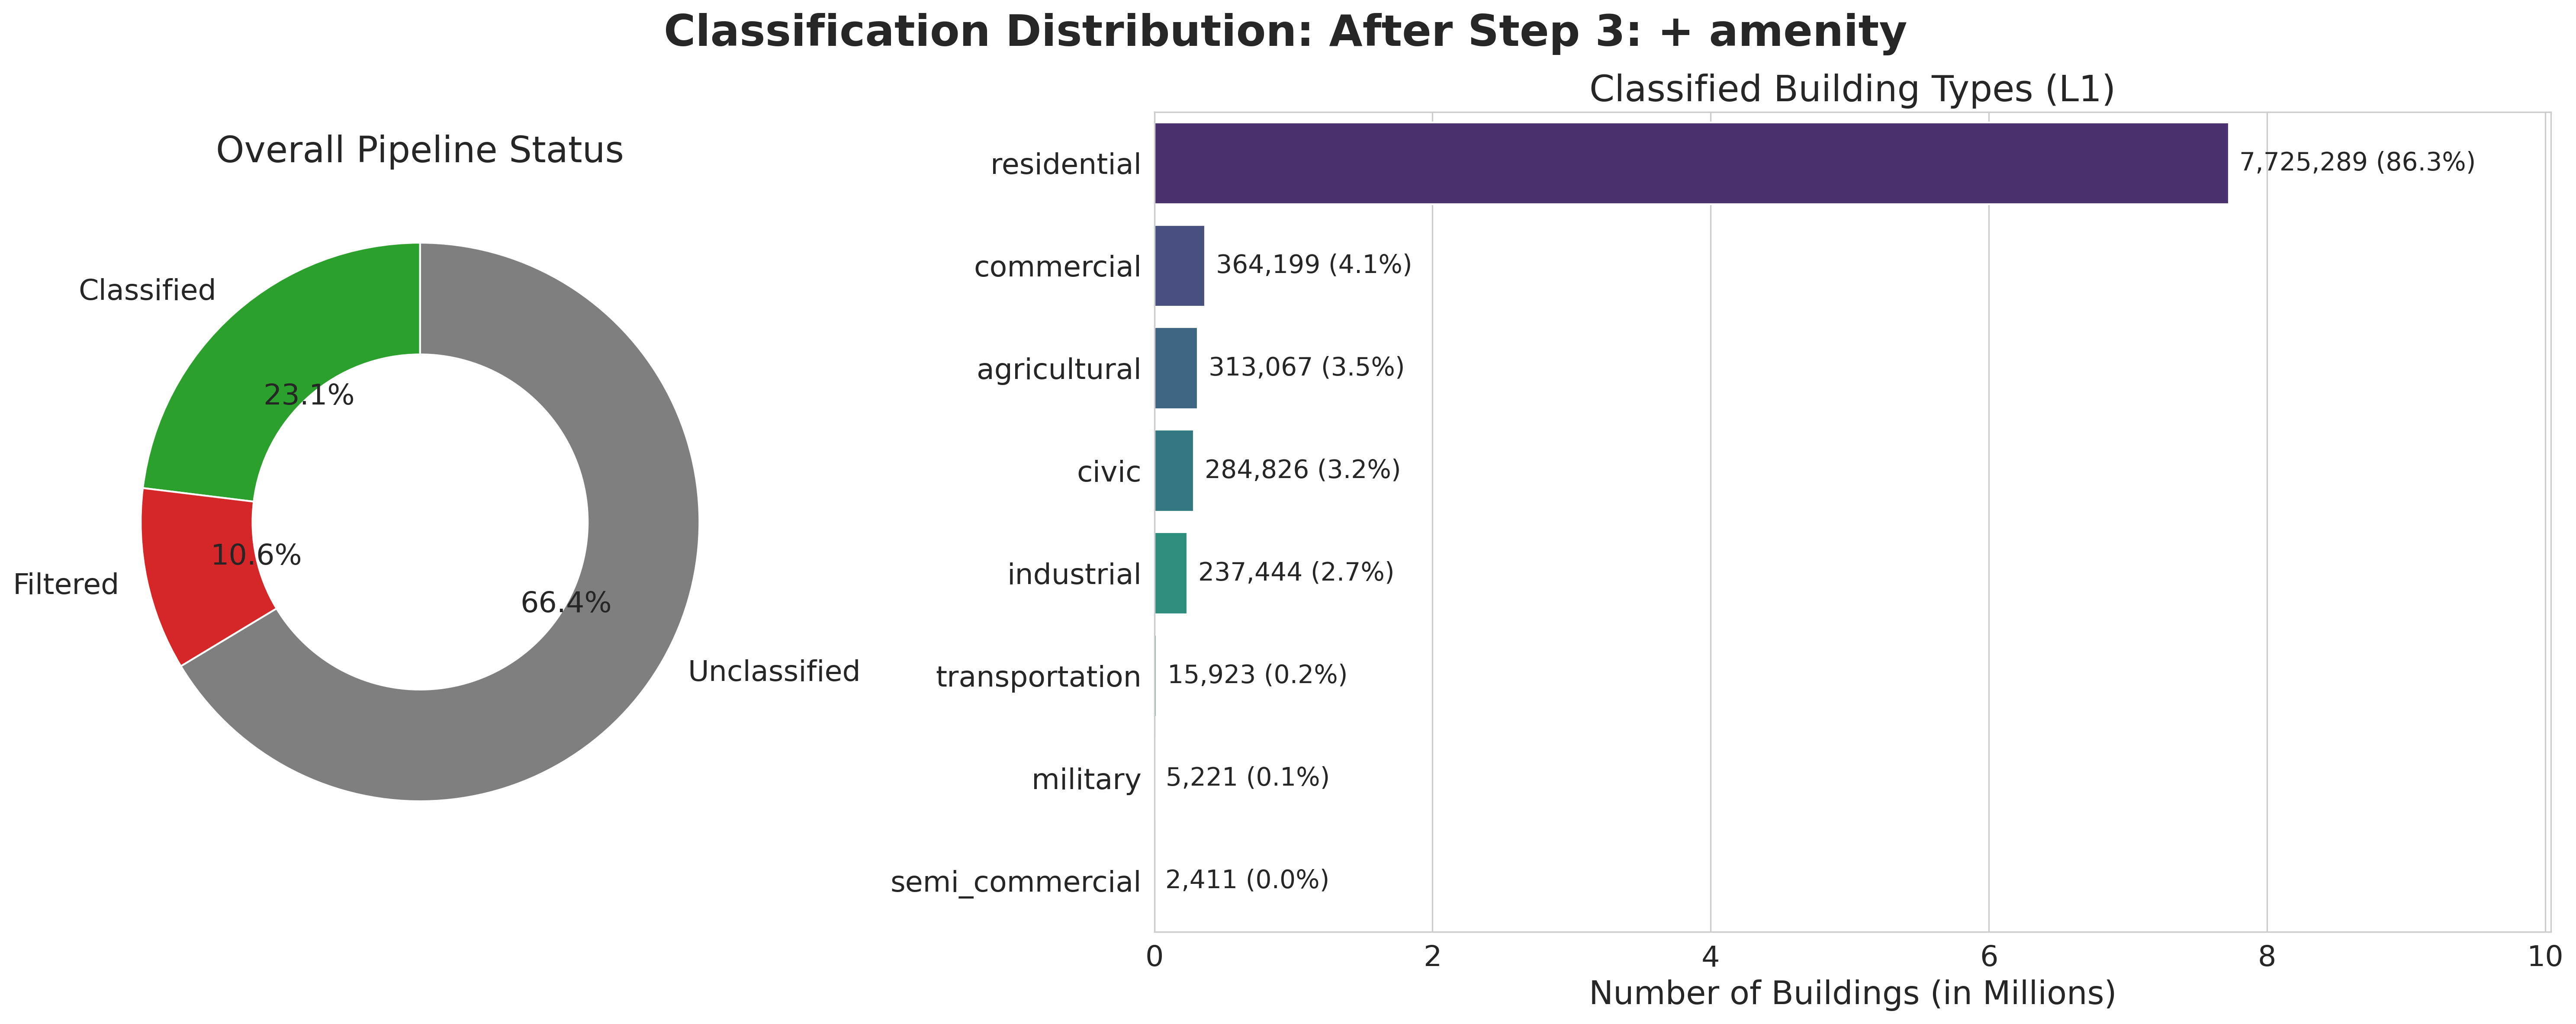

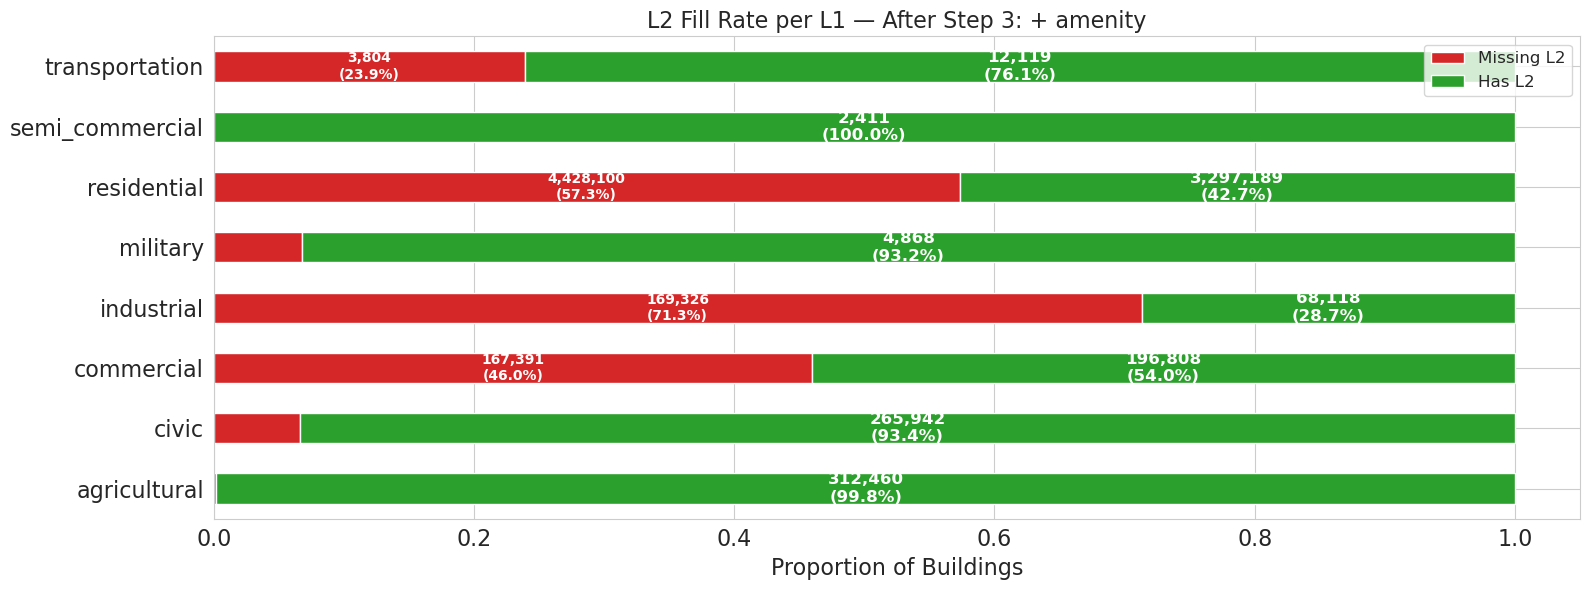

In [36]:
evaluate_step(gdf_bldg, "After Step 3: + amenity")

In [37]:
apply_source(gdf_bldg, 'shop_l1', 'shop_l2', 'shop', 'shop')

[shop]  A(filled): 44,209  |  B(filter override): 388  |  C(l2 inherited): 9,968



  After Step 4: + shop
  Total          :   38,802,372
  Classified     :    8,992,976  (23.2%)
    └ with L2    :    4,214,456  (46.9% of classified)
    └ no L2      :    4,778,520  (53.1% of classified)
  Filter         :    4,102,864  (10.6%)
  Unclassified   :   25,706,532  (66.2%)

  L1 breakdown:
stage1_l1
NaN                25706532
residential         7725289
filter              4102864
commercial           408794
agricultural         313067
civic                284827
industrial           237444
transportation        15923
military               5221
semi_commercial        2411


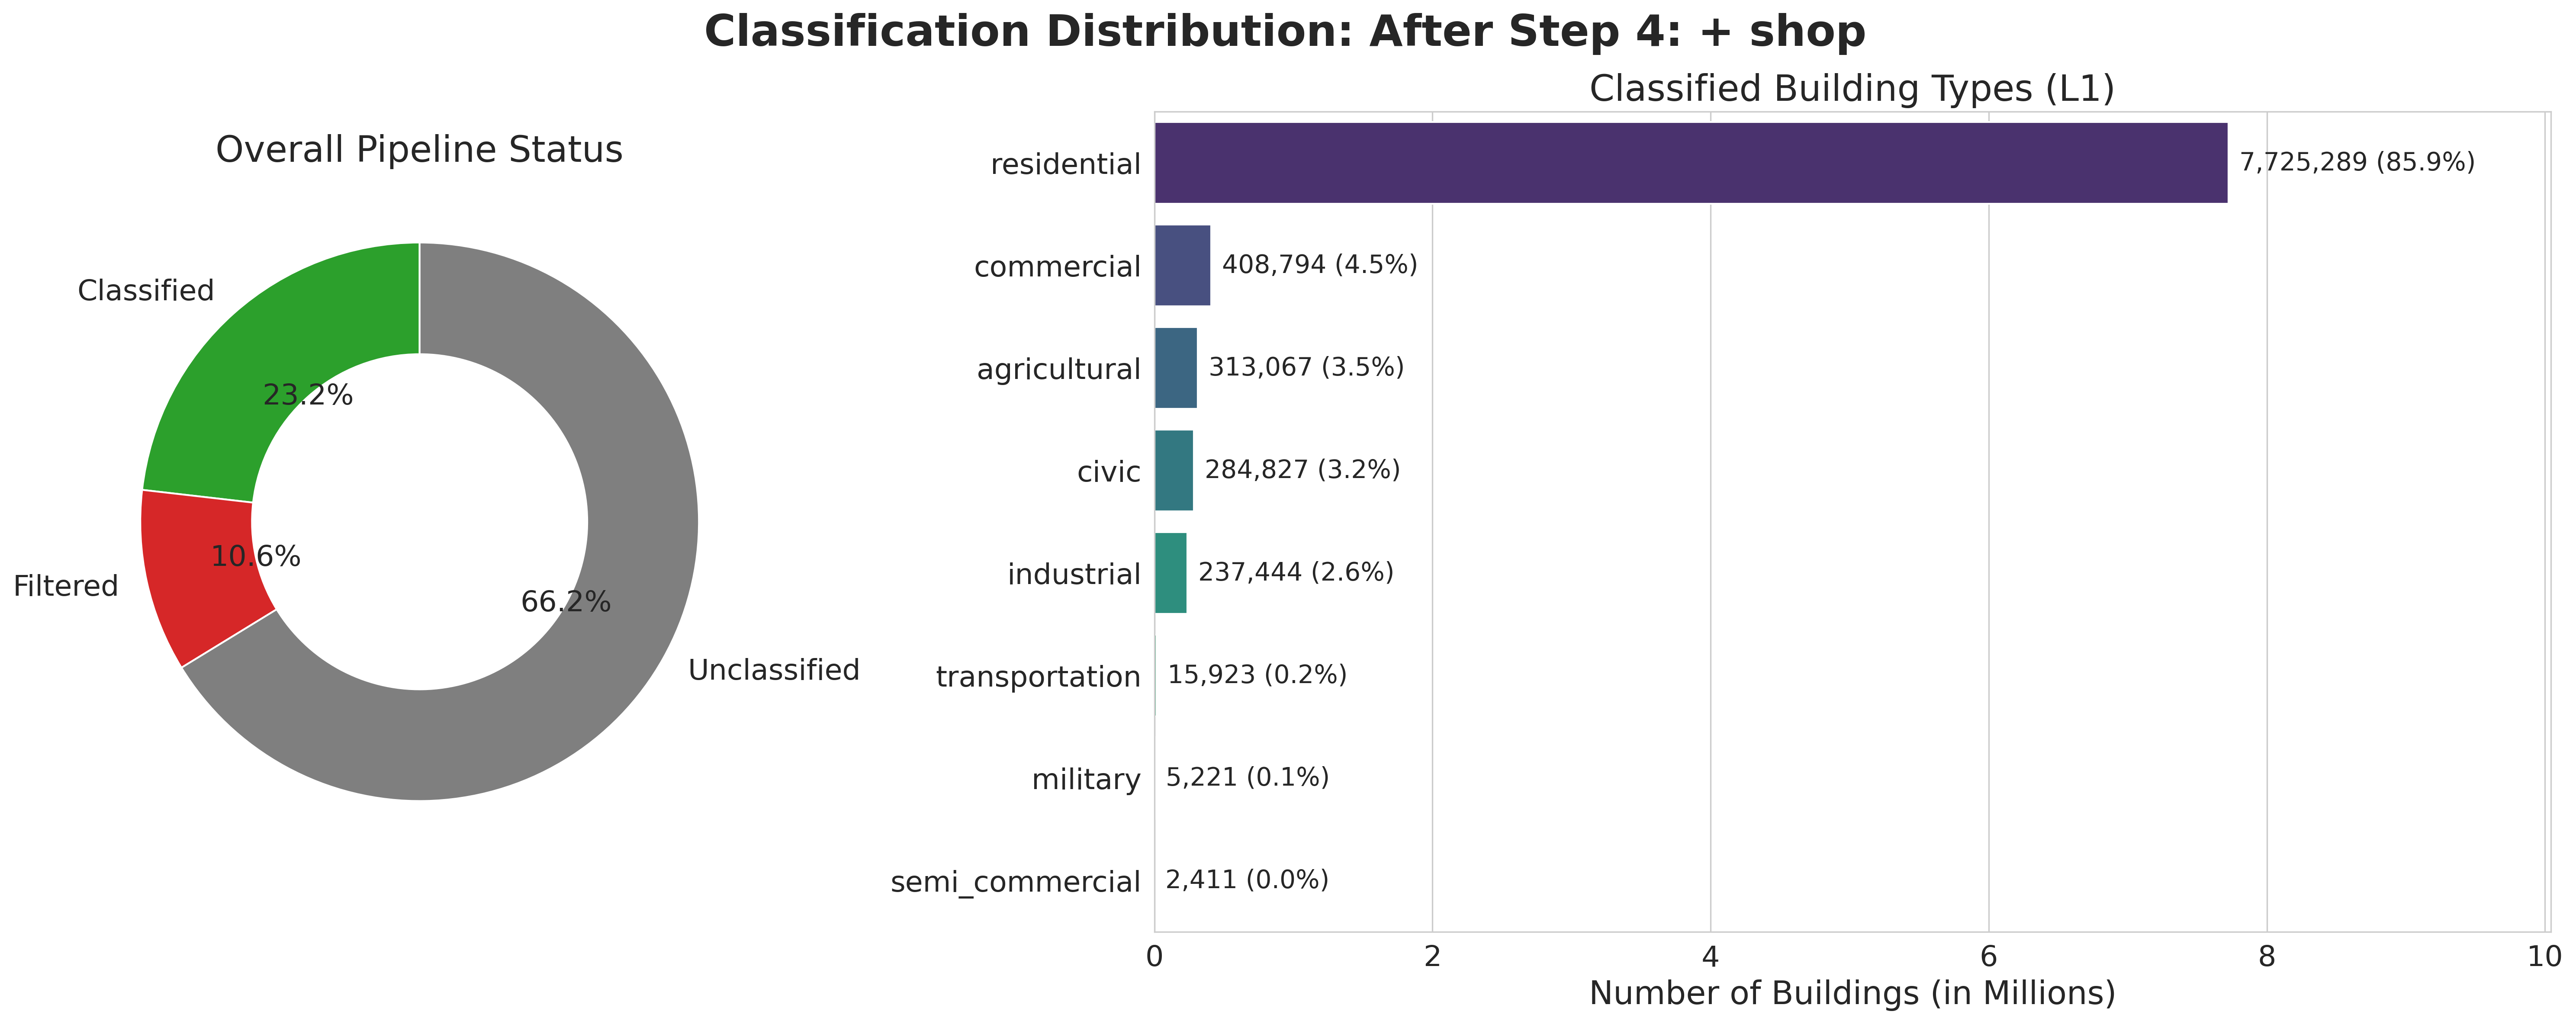

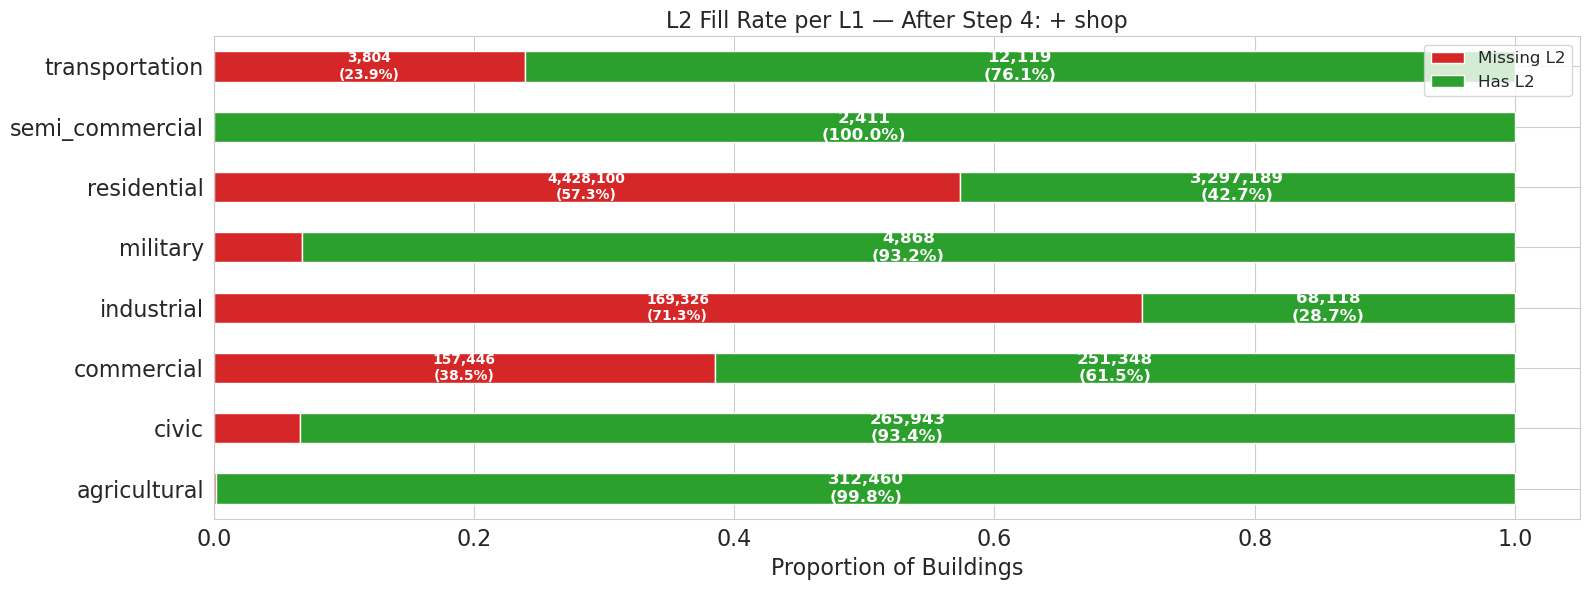

In [38]:
evaluate_step(gdf_bldg, "After Step 4: + shop")

In [39]:
apply_source(gdf_bldg, 'tag_l1', 'tag_l2', 'tag', 'tag_used')

[tag]  A(filled): 176,252  |  B(filter override): 2,235  |  C(l2 inherited): 142,743



  After Step 5: + tag column
  Total          :   38,802,372
  Classified     :    9,150,848  (23.6%)
    └ with L2    :    4,487,423  (49.0% of classified)
    └ no L2      :    4,663,425  (51.0% of classified)
  Filter         :    4,121,244  (10.6%)
  Unclassified   :   25,530,280  (65.8%)

  L1 breakdown:
stage1_l1
NaN                25530280
residential         7765260
filter              4121244
commercial           424475
agricultural         313609
civic                311495
industrial           301728
transportation        22301
military               8288
semi_commercial        3692


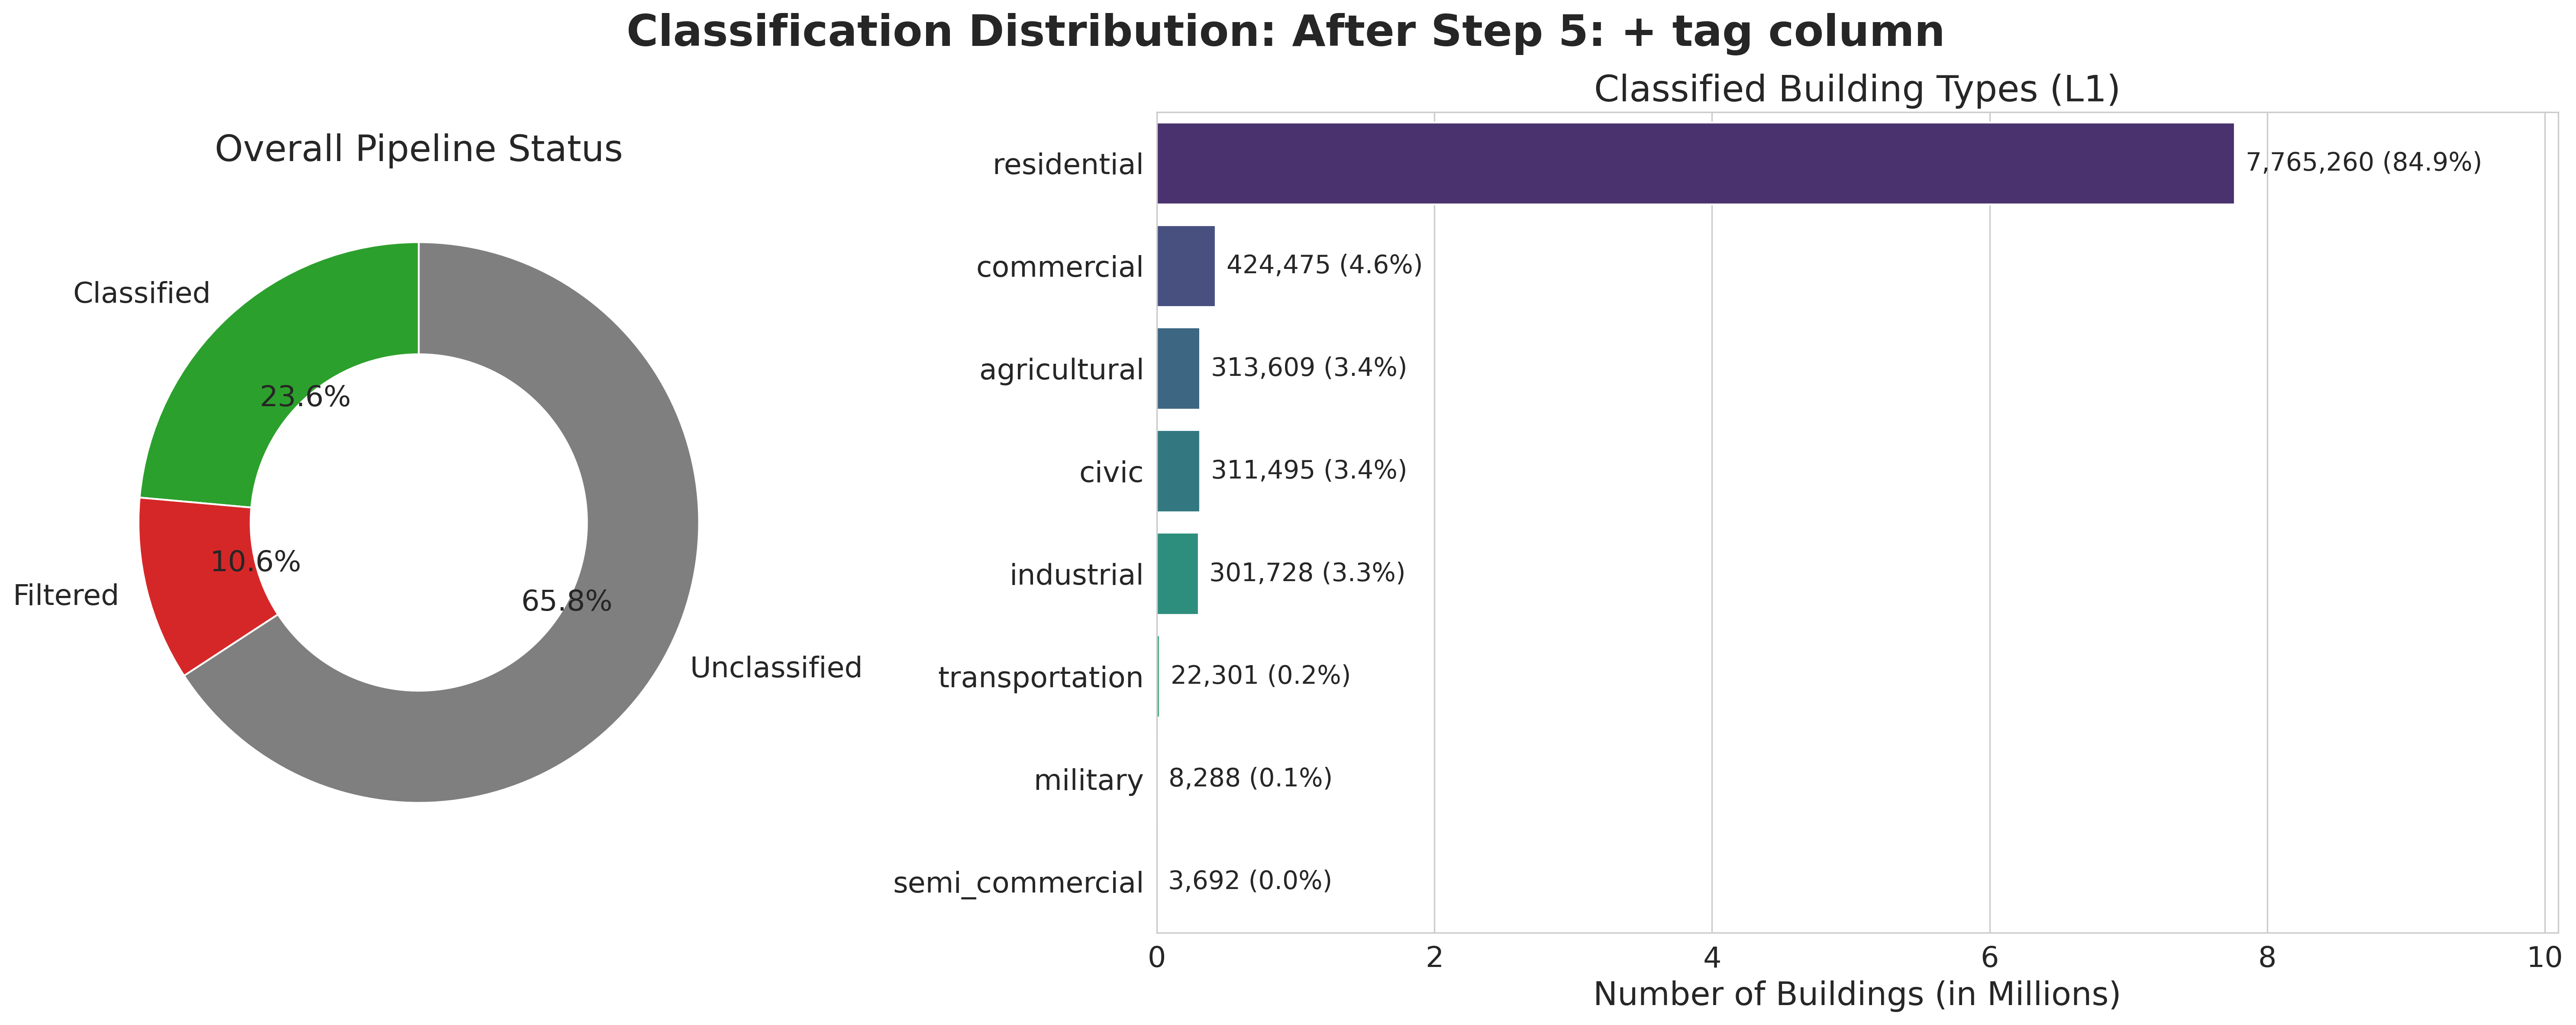

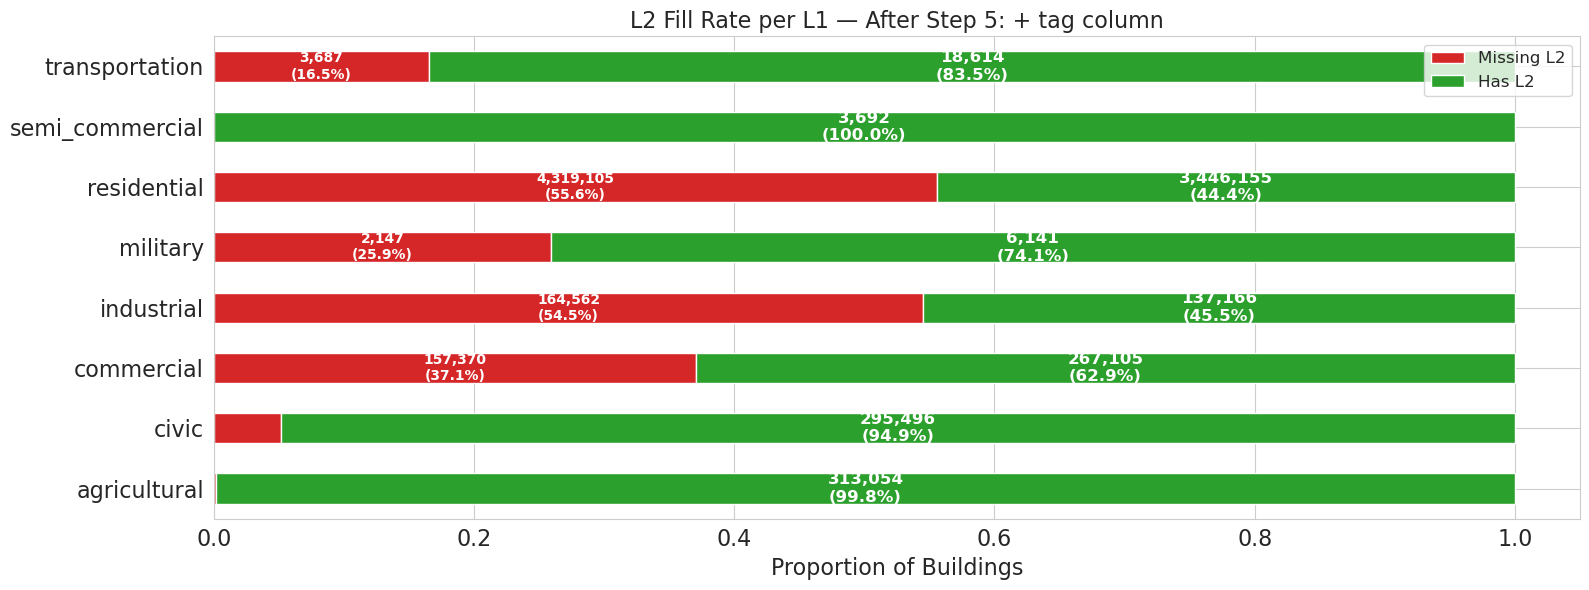

In [40]:
evaluate_step(gdf_bldg, "After Step 5: + tag column")

In [41]:
# ============================================================
# CELL 7 — Analysis: Coverage by Source
# ============================================================

print("Where did the final classification actually come from?")
print("-" * 50)

# 1. Simply count the values in the stage1_source column we already built!
source_counts = gdf_bldg['stage1_source'].value_counts(dropna=False)

# 2. Print the exact counts and percentages
total_buildings = len(gdf_bldg)
for source, count in source_counts.items():
    pct = (count / total_buildings) * 100
    print(f"  {str(source):<30}: {count:>12,}  ({pct:.1f}%)")

print("-" * 50)
total_classified = gdf_bldg['stage1_l1'].notna().sum()
print(f"  Total with ANY source         : {total_classified:>12,}  ({total_classified/total_buildings*100:.1f}%)")

Where did the final classification actually come from?
--------------------------------------------------
  nan                           :   25,530,280  (65.8%)
  building                      :    8,639,890  (22.3%)
  building_filter               :    4,071,563  (10.5%)
  tag                           :      176,252  (0.5%)
  building_+tag_l2              :      142,170  (0.4%)
  amenity                       :      134,255  (0.3%)
  shop                          :       44,209  (0.1%)
  building:use                  :       34,765  (0.1%)
  building_+amenity_l2          :       12,392  (0.0%)
  building_+shop_l2             :        9,820  (0.0%)
  amenity_override_filter       :        2,593  (0.0%)
  tag_override_filter           :        2,235  (0.0%)
  building:use_+tag_l2          :          538  (0.0%)
  building:use_override_filter  :          408  (0.0%)
  shop_override_filter          :          388  (0.0%)
  building_+building:use_l2     :          354  (0.0%)
  building:

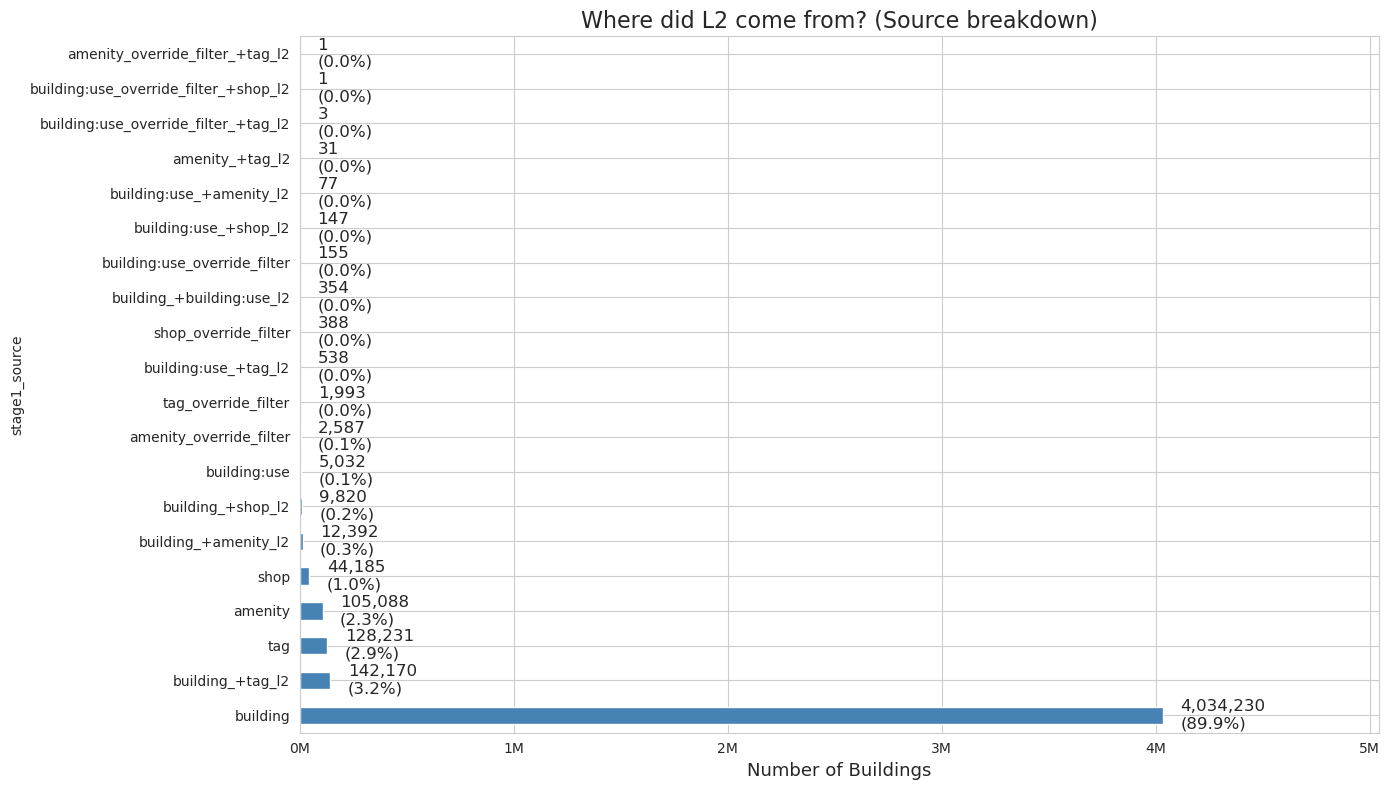

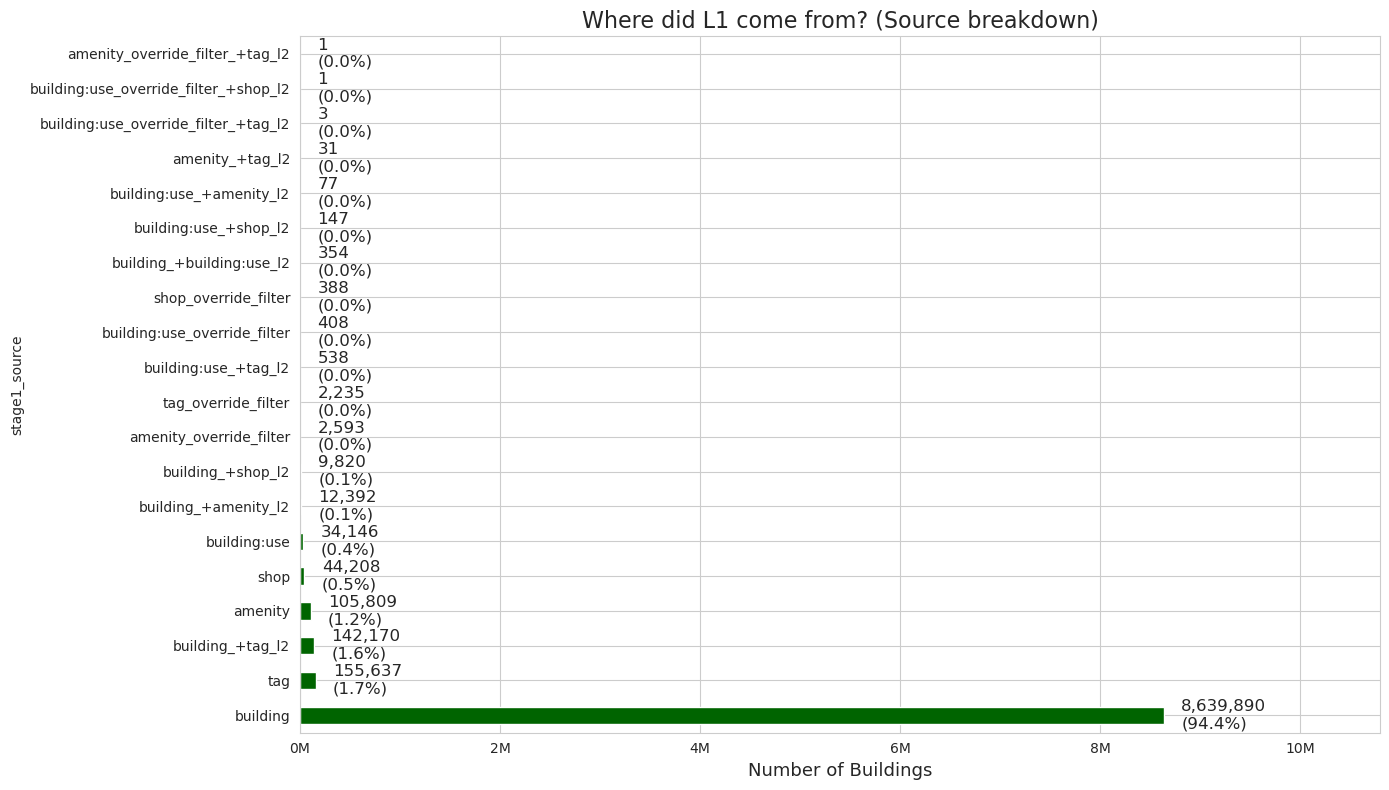

In [42]:
# Updated L2 source breakdown plot with numbers added
def plot_l2_source_breakdown(gdf):
    classified = gdf[gdf['stage1_l1'].notna() & (gdf['stage1_l1'] != 'filter') & gdf['stage1_l2'].notna()]
    source_counts = classified['stage1_source'].value_counts()
    total = source_counts.sum()
    
    ax = source_counts.plot(kind='barh', figsize=(14, 8), color='steelblue')
    plt.title('Where did L2 come from? (Source breakdown)', fontsize=16)
    plt.xlabel('Number of Buildings', fontsize=13)
    
    # Format X-axis to show Millions
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:g}M'))
    
    # Extend X-axis to make room for text labels
    max_count = source_counts.max()
    plt.xlim(0, max_count * 1.25)
    
    # Add text labels (count and percentage) to each bar
    for p in ax.patches:
        count = int(p.get_width())
        if count == 0:
            continue
        percentage = count / total * 100
        ax.text(
            p.get_width() + max_count * 0.02,
            p.get_y() + p.get_height() / 2,
            f'{count:,}\n({percentage:.1f}%)',
            va='center',
            fontsize=12
        )
    
    plt.tight_layout()
    plt.show()

plot_l2_source_breakdown(gdf_bldg)

# New plot for L1 source breakdown
def plot_l1_source_breakdown(gdf):
    classified = gdf[gdf['stage1_l1'].notna() & (gdf['stage1_l1'] != 'filter')]
    source_counts = classified['stage1_source'].value_counts()
    total = source_counts.sum()
    
    ax = source_counts.plot(kind='barh', figsize=(14, 8), color='darkgreen')
    plt.title('Where did L1 come from? (Source breakdown)', fontsize=16)
    plt.xlabel('Number of Buildings', fontsize=13)
    
    # Format X-axis to show Millions
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:g}M'))
    
    # Extend X-axis to make room for text labels
    max_count = source_counts.max()
    plt.xlim(0, max_count * 1.25)
    
    # Add text labels (count and percentage) to each bar
    for p in ax.patches:
        count = int(p.get_width())
        if count == 0:
            continue
        percentage = count / total * 100
        ax.text(
            p.get_width() + max_count * 0.02,
            p.get_y() + p.get_height() / 2,
            f'{count:,}\n({percentage:.1f}%)',
            va='center',
            fontsize=12
        )
    
    plt.tight_layout()
    plt.show()

plot_l1_source_breakdown(gdf_bldg)

Classifiable buildings: 13,272,092

--- Mixed-use buildings ---
  False:  9,198,103 (69.3%)
  True :      2,426 (0.0%)

--- Top L2 per L1 ---

  AGRICULTURAL (Total: 313,609)
    - farm_auxiliary      :    241,815 (77.1%)
    - greenhouse          :     46,423 (14.8%)
    - equestrian          :     16,263 (5.2%)
    - animal_keeping      :      8,553 (2.7%)

  CIVIC (Total: 311,495)
    - religious           :     74,603 (23.9%)
    - school              :     58,562 (18.8%)
    - kindergarten        :     32,970 (10.6%)
    - recreation          :     30,928 (9.9%)
    - emergency_service   :     25,826 (8.3%)
    - community           :     16,117 (5.2%)
    - government_office   :     10,583 (3.4%)
    - hospital            :     10,207 (3.3%)
    - cultural            :     10,089 (3.2%)
    - higher_ed           :      9,915 (3.2%)
    - care_facility       :      9,694 (3.1%)
    - clinic              :      5,929 (1.9%)
    - research            :         73 (0.0%)

  TRANSPORT

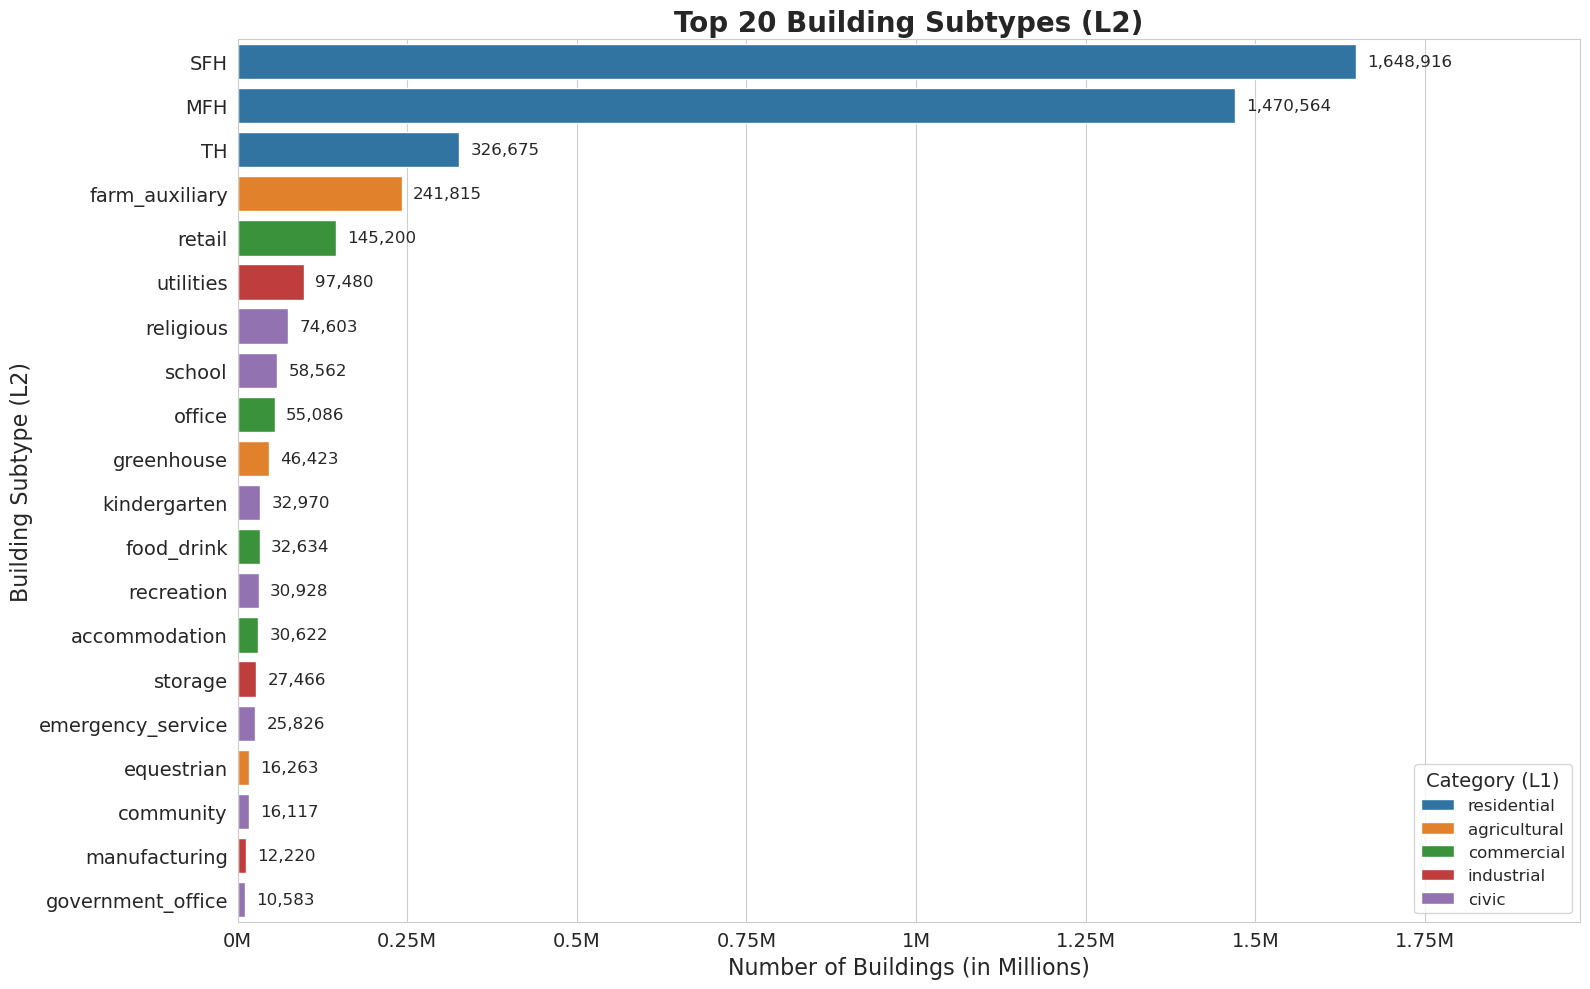

In [43]:
# CELL 8 — Analysis: L1/L2 frequency for classifiable buildings

# 1. Filter for only classified buildings
classified = gdf_bldg[gdf_bldg['stage1_l1'].notna()]
total_class = len(classified)

print(f"Classifiable buildings: {total_class:,}\n")

# --- TEXT REPORT ---
print("--- Mixed-use buildings ---")
mixed_counts = classified['stage1_is_mixed'].value_counts()
for val, count in mixed_counts.items():
    print(f"  {str(val):<5}: {count:>10,} ({count/total_class*100:.1f}%)")
print()

print("--- Top L2 per L1 ---")
for l1 in classified['stage1_l1'].unique():
    subset = classified[classified['stage1_l1'] == l1]
    total_l1 = len(subset)
    print(f"\n  {l1.upper()} (Total: {total_l1:,})")
    
    # Get top 5 L2s and calculate their percentage within this L1
    sub_counts = subset['stage1_l2'].value_counts().head(15)
    for l2, count in sub_counts.items():
        print(f"    - {str(l2):<20}: {count:>10,} ({count/total_l1*100:.1f}%)")

# --- VISUALIZATION: Top 20 Subtypes (L2) Colored by L1 ---
def plot_top_subtypes(classified_df):
    # Get the top 20 L2 categories overall
    top_20_l2 = classified_df['stage1_l2'].value_counts().head(20).index
    
    # Filter data to just these top 20
    plot_data = classified_df[classified_df['stage1_l2'].isin(top_20_l2)]
    
    # Count them, keeping the L1 association for coloring
    counts = plot_data.groupby(['stage1_l2', 'stage1_l1']).size().reset_index(name='count')
    counts = counts.sort_values('count', ascending=False)
    
    plt.figure(figsize=(16, 10))
    ax = sns.barplot(
        data=counts, 
        y='stage1_l2', 
        x='count', 
        hue='stage1_l1', 
        dodge=False, # Keeps bars aligned properly
        palette='tab10'
    )
    
    plt.title("Top 20 Building Subtypes (L2)", fontsize=20, fontweight='bold')
    plt.xlabel("Number of Buildings (in Millions)", fontsize=16)
    plt.ylabel("Building Subtype (L2)", fontsize=16)
    plt.tick_params(axis='both', which='major', labelsize=14)
    
    # Format X-axis to Millions
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:g}M'))
    
    # Add numbers next to bars
    for i, p in enumerate(ax.patches):
        width = p.get_width()
        if width > 0: # Ignore empty hue patches
            ax.text(width + (counts['count'].max() * 0.01), 
                    p.get_y() + p.get_height()/2., 
                    f"{int(width):,}", 
                    va='center', fontsize=12)

    # Clean up legend
    plt.legend(title='Category (L1)', title_fontsize='14', fontsize='12', loc='lower right')
    
    # Extend X-axis slightly so text fits
    ax.set_xlim(0, counts['count'].max() * 1.2)
    plt.tight_layout()
    plt.show()

# Run the plot
plot_top_subtypes(classified)

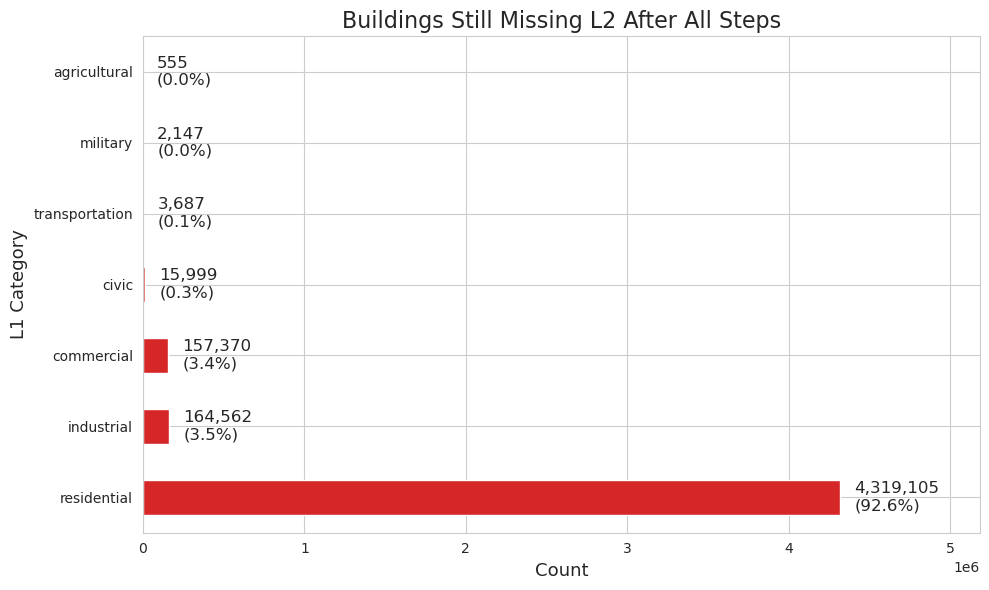

In [44]:
def plot_missing_l2_by_l1(gdf):
    classified = gdf[gdf['stage1_l1'].notna() & (gdf['stage1_l1'] != 'filter')]
    missing_l2 = classified[classified['stage1_l2'].isna()]
    
    counts = missing_l2['stage1_l1'].value_counts()
    total_missing = counts.sum()
    
    if counts.empty:
        print("No missing L2 buildings found.")
        return
    
    ax = counts.plot(kind='barh', color='#d62728', figsize=(10, 6))
    plt.title('Buildings Still Missing L2 After All Steps', fontsize=16)
    plt.xlabel('Count', fontsize=13)
    plt.ylabel('L1 Category', fontsize=13)
    
    max_count = counts.max()
    plt.xlim(0, max_count * 1.2)
    
    for p in ax.patches:
        count = int(p.get_width())
        pct = count / total_missing * 100
        ax.text(
            count + max_count * 0.02,
            p.get_y() + p.get_height() / 2,
            f'{count:,}\n({pct:.1f}%)',
            va='center',
            fontsize=12
        )
    
    plt.tight_layout()
    plt.show()

plot_missing_l2_by_l1(gdf_bldg)

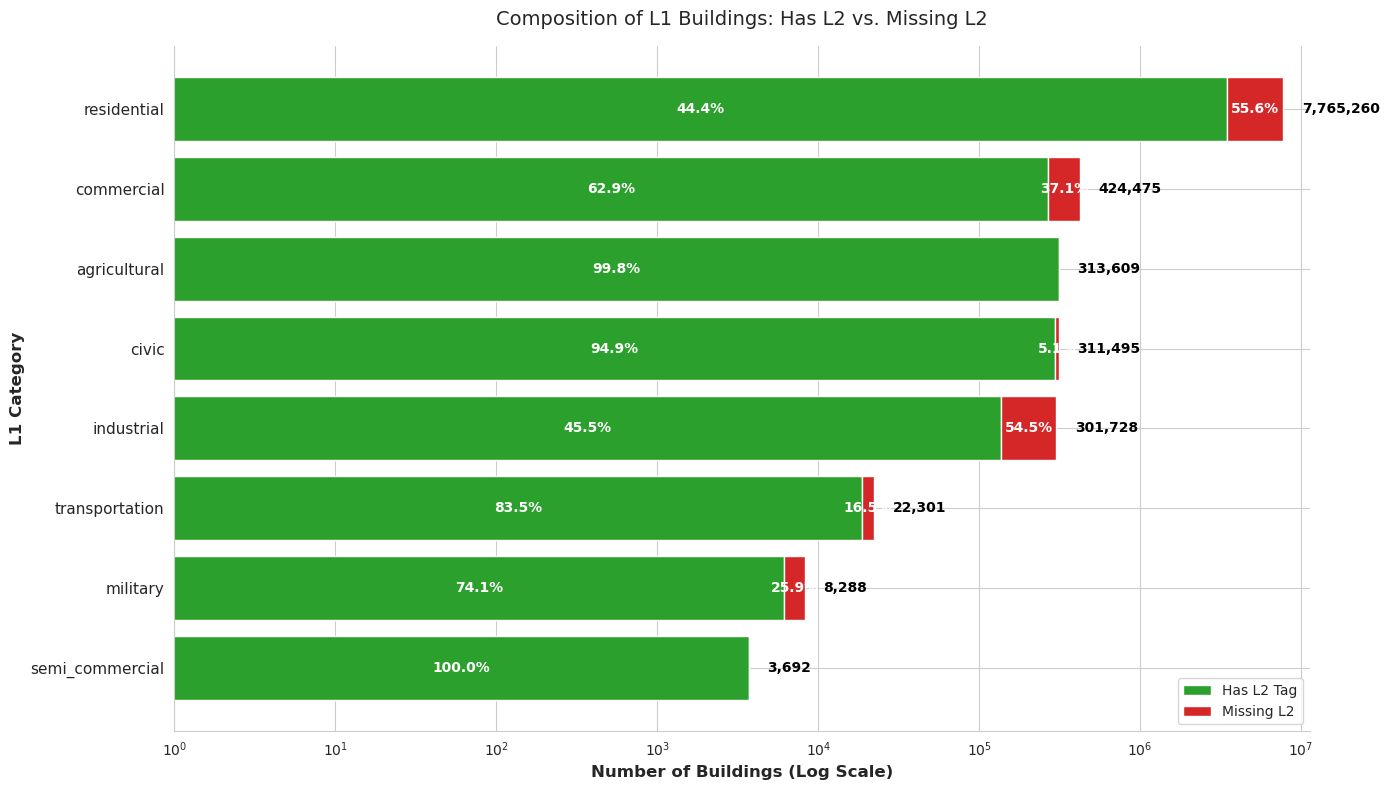

In [45]:
# 1. Filter for classified buildings
classified = gdf_bldg[(gdf_bldg['stage1_l1'].notna()) & (gdf_bldg['stage1_l1'] != 'filter')]

# 2. Group by L1 and calculate stats
l1_stats = classified.groupby('stage1_l1').agg(
    total_mapped=('stage1_l1', 'size'),
    missing_l2=('stage1_l2', lambda x: x.isna().sum())
).reset_index()

# Calculate the subset of buildings that actually HAVE an L2 tag
l1_stats['has_l2'] = l1_stats['total_mapped'] - l1_stats['missing_l2']

# Sort ASCENDING so the largest bar appears at the TOP
l1_stats = l1_stats.sort_values('total_mapped', ascending=True)

# 3. Create Horizontal Stacked Bar Chart
fig, ax = plt.subplots(figsize=(14, 8))
index = range(len(l1_stats))

# Plot the left bar (Buildings WITH L2)
bars1 = ax.barh(index, l1_stats['has_l2'], label='Has L2 Tag', color='#2ca02c')

# Plot the right bar (Buildings MISSING L2), starting where the left bar ends
bars2 = ax.barh(index, l1_stats['missing_l2'], left=l1_stats['has_l2'], label='Missing L2', color='#d62728')

# ── NEW: Convert the X-axis to a Logarithmic Scale ──
ax.set_xscale('log')
# Start the X-axis at 1 so the log scale doesn't break on zero values
ax.set_xlim(left=1)

# Formatting
ax.set_ylabel('L1 Category', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Buildings (Log Scale)', fontsize=12, fontweight='bold')
ax.set_title('Composition of L1 Buildings: Has L2 vs. Missing L2', fontsize=14, pad=15)

ax.set_yticks(index)
ax.set_yticklabels(l1_stats['stage1_l1'], fontsize=11)
ax.legend(loc='lower right')

# 4. Adaptive Labeling Logic (Geometric Centers for Log Scale)
for i, (has_l2, missing, total) in enumerate(zip(l1_stats['has_l2'], l1_stats['missing_l2'], l1_stats['total_mapped'])):
    if total == 0: continue
        
    has_l2_pct = (has_l2 / total) * 100
    missing_pct = (missing / total) * 100
    
    # Mathematical visual center for log scale (geometric mean)
    # We use max(1, value) to prevent multiplying by 0 and breaking the math
    green_center = np.sqrt(max(1, has_l2))
    red_center = np.sqrt(max(1, has_l2) * total)
    
    # Label the green bar (Has L2 %) ONLY if the segment is > 5% of the total
    if has_l2_pct > 5:
        ax.text(green_center, i, f'{has_l2_pct:.1f}%', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        
    # Label the red bar (Missing L2 %) ONLY if the segment is > 5% of the total
    if missing_pct > 5:
        ax.text(red_center, i, f'{missing_pct:.1f}%', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        
    # Put the TOTAL absolute count at the end. 
    # Because it's a log scale, we use a multiplicative offset (* 1.3) instead of addition (+).
    ax.text(total * 1.3, i, f'{int(total):,}', 
            ha='left', va='center', color='black', fontweight='bold', fontsize=10)

# Remove top and right borders for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Total Unclassified Buildings (ML Target): 25,530,280

--- Top 25 unmapped 'building' values ---
building
yes                   25470138
service                  44566
construction              6855
silo                      4742
depot                      369
bakehouse                  344
workshop                   252
semi                       178
storage                    175
prefabricated              142
proposed                   113
railway                    111
windmill                   104
recreation                  87
historic                    86
watermill                   56
utility                     54
viaduct                     49
razed                       47
sanitary                    46
wayside_chapel              38
demountable                 32
sedimentation_tank          30
horsewalker                 29
addition                    26

--- Top 25 unmapped 'building:use' values ---
building:use
residential;industrial           9515
depot                 

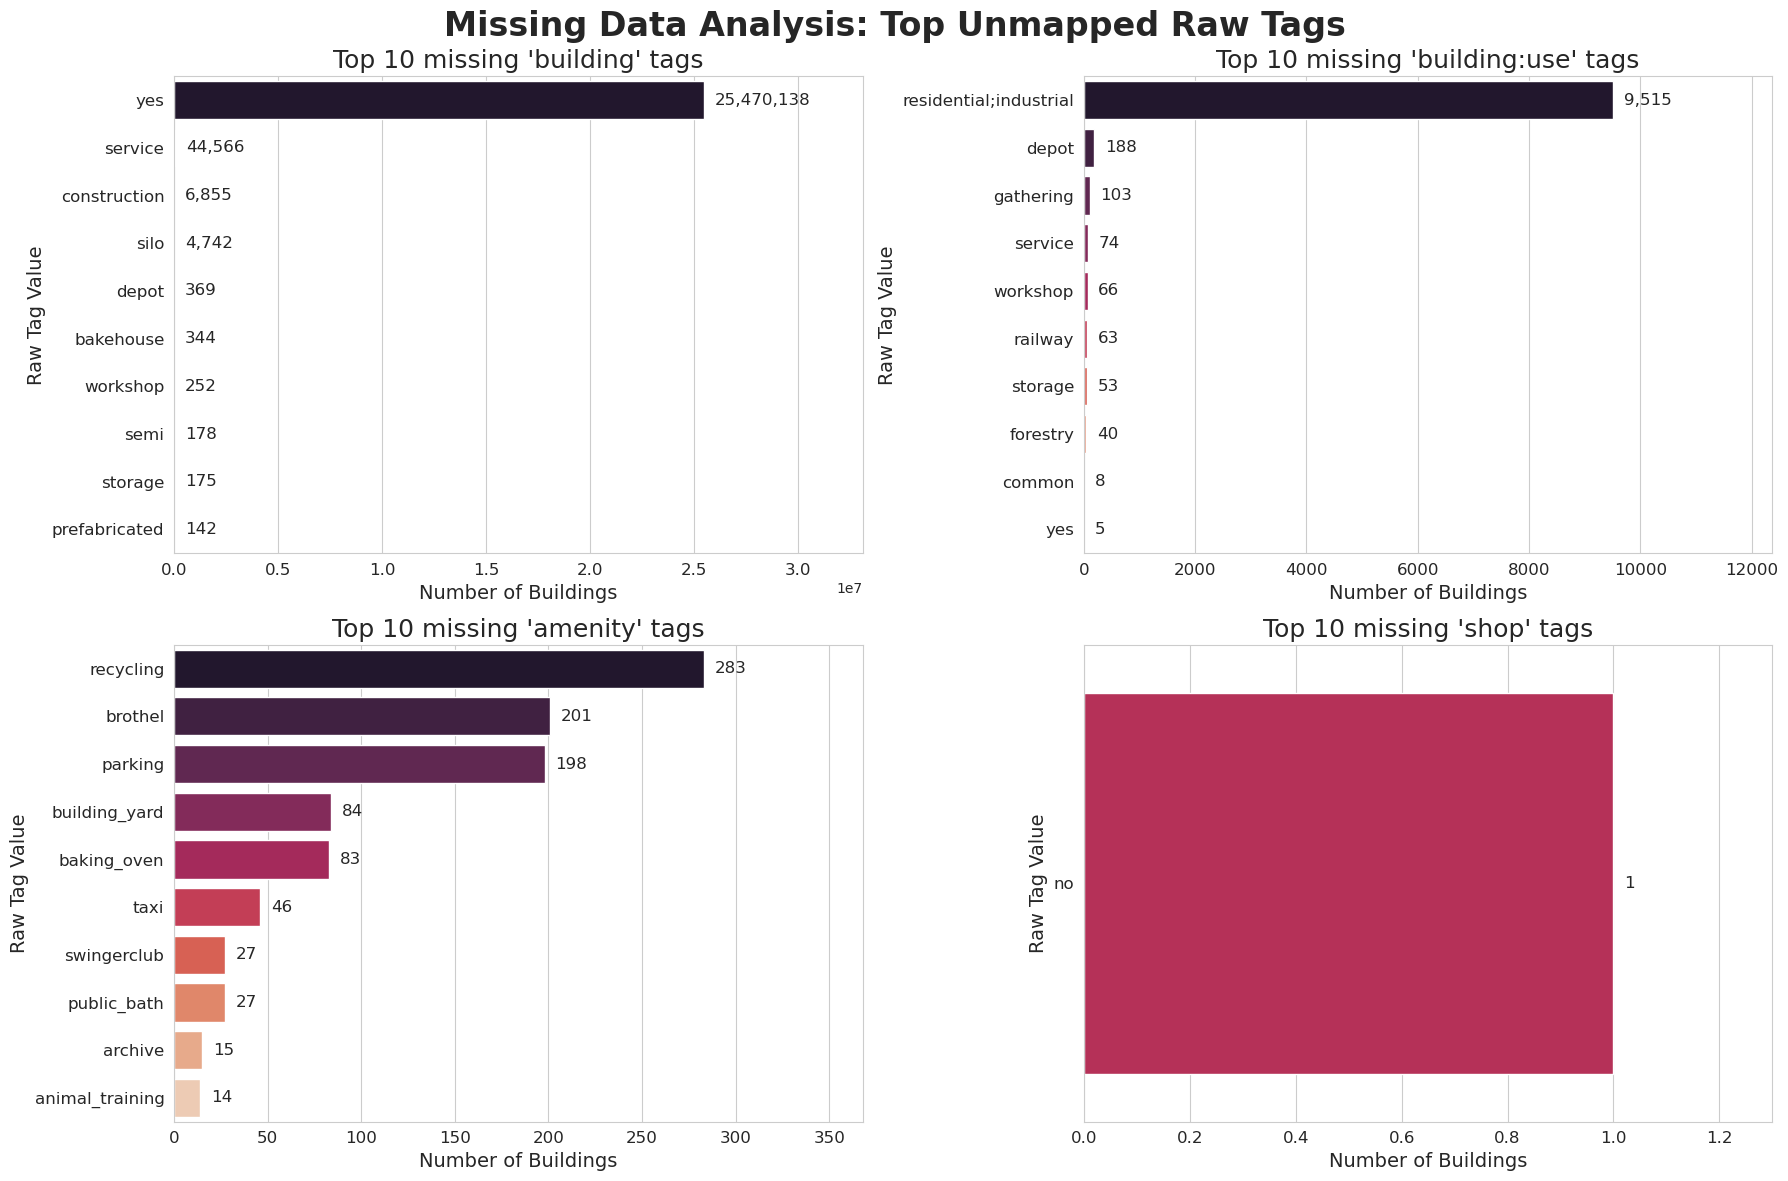

In [46]:
# ============================================================
# CELL 9 — Analysis: Unclassified Buildings (ML Targets)
# What raw tags are still falling through to None?
# ============================================================

def analyze_unmapped_tags(gdf):
    # 1. Isolate the truly empty buildings
    unclassified = gdf[gdf['stage1_l1'].isna()]
    print(f"Total Unclassified Buildings (ML Target): {len(unclassified):,}\n")
    
    cols_to_check = ['building', 'building:use', 'amenity', 'shop']
    
    # --- TEXT REPORT (For easy copy-pasting to your mapping scripts) ---
    for col in cols_to_check:
        if col in unclassified.columns:
            # We look at the top 15 to catch the most impactful missing tags
            vals = unclassified[col].dropna().value_counts().head(25)
            if not vals.empty:
                print(f"--- Top 25 unmapped '{col}' values ---")
                print(vals.to_string())
                print()

    # --- VISUAL DASHBOARD (For your thesis/presentation) ---
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle("Missing Data Analysis: Top Unmapped Raw Tags", fontsize=24, fontweight='bold')
    axes = axes.flatten() # Flatten the 2x2 grid to iterate easily
    
    for idx, col in enumerate(cols_to_check):
        if col in unclassified.columns:
            vals = unclassified[col].dropna().value_counts().head(10)
            
            if not vals.empty:
                # Using 'rocket' palette to indicate "missing/action required"
                ax = sns.barplot(
                    x=vals.values, 
                    y=vals.index, 
                    ax=axes[idx], 
                    palette='rocket', 
                    hue=vals.index, 
                    legend=False
                )
                axes[idx].set_title(f"Top 10 missing '{col}' tags", fontsize=18)
                axes[idx].set_xlabel("Number of Buildings", fontsize=14)
                axes[idx].set_ylabel("Raw Tag Value", fontsize=14)
                axes[idx].tick_params(axis='both', which='major', labelsize=12)
                
                # Add exact counts next to bars
                for i, v in enumerate(vals.values):
                    axes[idx].text(v + (vals.max() * 0.02), i, f"{int(v):,}", va='center', fontsize=12)
                
                # Give text room to breathe
                axes[idx].set_xlim(0, vals.max() * 1.3)
            else:
                axes[idx].text(0.5, 0.5, f"No missing data for '{col}'!", ha='center', va='center', fontsize=16)
                axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# Run the analysis!
analyze_unmapped_tags(gdf_bldg)

In [47]:
gdf_bldg.head(5)

,id,geometry,building,tag_l1,tag_l2,is_abandoned,tag_is_mixed,tag_source,tag_used,all_candidates,...,buse_is_mixed,amenity_l1,amenity_l2,shop_l1,shop_l2,stage1_l1,stage1_l2,stage1_is_mixed,stage1_source,raw_label
0,3428357,"POLYGON ((8.67006 49.54737, 8.67004 49.54762, ...",yes,None,None,False,False,None,None,None,...,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN
1,3453425,"POLYGON ((11.90186 48.19362, 11.90156 48.19361...",riding_hall,None,None,False,False,None,None,None,...,None,None,None,None,None,agricultural,equestrian,False,building,riding_hall
2,3453428,"POLYGON ((11.90062 48.19382, 11.90052 48.1938,...",yes,None,None,False,False,None,None,None,...,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN
3,3453429,"POLYGON ((11.90074 48.19364, 11.90044 48.19359...",yes,None,None,False,False,None,None,None,...,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN
4,3453554,"POLYGON ((11.90097 48.19364, 11.90137 48.1937,...",yes,None,None,False,False,None,None,None,...,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN


In [48]:
gdf_bldg.to_parquet(os.path.join(DATA_DIR, 'processed', 'germany_buildings_classified_stage1.parquet'), index=False)